# A Code Copilot on CodeSearchNet
### RAG + LoRA + Agent (full train / val / test)

This is an **Applied Languages Model** project for the course
**AI and Deep Learning Models Development** under **Google and Reichman AI Tech School**,
led by **Dr. Barak Or**, with **Orr Zwebner**.

The dataset is **[CodeSearchNet](https://huggingface.co/datasets/code-search-net/code_search_net)** ([GitHub](https://github.com/github/CodeSearchNet)), from Husain, H., Wu, H.-H., Gazit, T., Allamanis, M., & Brockschmidt, M. (2019), *CodeSearchNet challenge: Evaluating the state of semantic code search*, arXiv preprint [arXiv:1909.09436](https://arxiv.org/abs/1909.09436).

The project — a **Code Copilot** by **Tal Matsil** on the Python subset of CodeSearchNet — began as seven Colab notebooks: data exploration (later revised with RAG-readiness gates), preprocessing, a LoRA feasibility study, a multi-run LoRA sweep, two follow-ups (a data-scaling run and a training-target-rewrite pilot), and an agent demo. The goal is a small assistant that retrieves relevant functions for a query (RAG), optionally improves code explanation with LoRA fine-tuning, and combines both in a minimal agent that retrieves, optionally uses a tool, generates an explanation, and cites its source. Across 16 training configurations, two independent LLM judges, and bootstrap confidence checks, LoRA did not help: **no trained variant beat the base model** on judged quality.

This notebook runs end-to-end on the **entire official** CodeSearchNet Python `train`, `validation`, and `test` splits for filtering, chunking, embeddings, and the RAG store. Official split labels are kept (`validation` → `val`). LoRA trains on a **repo-balanced detailed subsample** of `train` (Section 11). Pipeline outputs write under `codesearchnet_copilot_full_artifacts` folder. **Requirements:** Colab with a GPU runtime (Runtime → Change runtime type → GPU). Optional Colab secrets `OPENAI_API_KEY` and/or `GEMINI_API_KEY` unlock the LLM-judge columns in Section 14; everything else runs without them.


## 0. Setup and Settings:


**Memory cleanup first** (only clears leftover models / CUDA cache if this runtime already ran parts of the notebook — safe on a fresh launch). Then installs, imports, seeds/GPU check, a shared seaborn theme for charts, and optional Colab secrets for the LLM judges.


In [1]:
# Clean slate before a full top-to-bottom run.
# On a fresh runtime this is a no-op beyond gc; on a re-run it drops heavy objects
# left in memory so later sections do not mix stale models / tables with new results.
import gc

_HEAVY_NAMES = (
    "gen_model", "lora_gen_model", "_lora_base_model", "embedding_model",
    "trainer", "peft_model", "base_model", "collection", "chroma_client",
    "tokenizer", "lora_tokenizer", "lora_result", "test_generation_df",
    "embeddings_by_split", "reload_client",
)
_cleared = []
for _name in _HEAVY_NAMES:
    if _name in globals():
        try:
            del globals()[_name]
            _cleared.append(_name)
        except Exception:
            pass

try:
    import matplotlib.pyplot as plt
    plt.close("all")
except Exception:
    pass

gc.collect()

try:
    import torch
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        torch.cuda.ipc_collect()
        allocated = torch.cuda.memory_allocated() / (1024 ** 3)
        reserved = torch.cuda.memory_reserved() / (1024 ** 3)
        print(f"GPU cleanup done. allocated={allocated:.2f} GB, reserved={reserved:.2f} GB")
    else:
        print("No CUDA device — CPU cleanup only.")
except ImportError:
    print("torch not imported yet — ran gc only (fresh runtime / before installs).")

if _cleared:
    print(f"Cleared leftover objects from a previous run: {', '.join(_cleared)}")
else:
    print("No leftover heavy objects found (fresh runtime or already clean).")
print("Memory cleanup complete — results below will not reuse stale in-memory state.")
print("For a fully cold start on Colab: Runtime → Restart session, then Run all.")


GPU cleanup done. allocated=0.00 GB, reserved=0.00 GB
No leftover heavy objects found (fresh runtime or already clean).
Memory cleanup complete — results below will not reuse stale in-memory state.
For a fully cold start on Colab: Runtime → Restart session, then Run all.


In [2]:
import subprocess
import sys

def pip_install(*packages):
    cmd = [sys.executable, "-m", "pip", "install", "-q", "--disable-pip-version-check", *packages]
    result = subprocess.run(cmd, capture_output=True, text=True)
    if result.returncode != 0:
        err = (result.stderr or result.stdout or "").strip()
        raise RuntimeError(err or f"pip failed for: {packages}")

# OpenTelemetry pins keep Colab's preinstalled google-adk happy with chromadb
install_steps = [
    ("data / plotting", ["datasets", "pandas", "numpy", "matplotlib", "seaborn", "pyarrow", "scikit-learn", "tqdm"]),
    ("transformers / LoRA", ["sentence-transformers", "transformers>=4.46", "accelerate", "peft", "sentencepiece"]),
    ("retrieval / chroma", ["langdetect", "rank_bm25", "rouge-score", "chromadb",
                           "opentelemetry-api>=1.39,<=1.42.1", "opentelemetry-sdk>=1.39,<=1.42.1",
                           "opentelemetry-exporter-otlp-proto-grpc>=1.39,<=1.42.1"]),
    ("LLM clients", ["openai", "google-genai", "bitsandbytes"]),
    ("torchao", ["-U", "torchao>=0.16.0"]),
]

print("Installing packages")
for label, pkgs in install_steps:
    print(f"  {label} ...", end=" ", flush=True)
    pip_install(*pkgs)
    print("ok")
print("Setup packages ready.")


Installing packages
  data / plotting ... ok
  transformers / LoRA ... ok
  retrieval / chroma ... ok
  LLM clients ... ok
  torchao ... ok
Setup packages ready.


In [3]:
import os
import gc
import re
import ast
import io
import json
import logging
import textwrap
import tokenize
import warnings
import hashlib
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import Markdown, display

# Quiet HF / hub / chromadb / torchao spam for the rest of the notebook
os.environ.setdefault("HF_HUB_DISABLE_PROGRESS_BARS", "1")
os.environ.setdefault("TOKENIZERS_PARALLELISM", "false")
os.environ.setdefault("ANONYMIZED_TELEMETRY", "False")
os.environ.setdefault("CHROMA_TELEMETRY", "False")
for _name in ("transformers", "huggingface_hub", "datasets", "torchao", "httpx", "chromadb"):
    logging.getLogger(_name).setLevel(logging.ERROR)
warnings.filterwarnings("ignore", message=r".*torchao.*")
warnings.filterwarnings("ignore", message=r".*sequence length is longer than.*")
try:
    from huggingface_hub.utils import disable_progress_bars
    disable_progress_bars()
except Exception:
    pass
try:
    from datasets import disable_progress_bar
    disable_progress_bar()
except Exception:
    pass

pd.set_option("display.max_colwidth", 120)
pd.set_option("display.max_rows", 20)

# Ready-made chart theme (seaborn) instead of a custom design system
sns.set_theme(style="whitegrid", context="notebook")
PALETTE = sns.color_palette("deep").as_hex()
DECLINE_RED, IMPROVE_GREEN = "#C44E52", "#55A868"
INK_PRIMARY, INK_SECONDARY, INK_MUTED = "#222222", "#555555", "#888888"

def style_axis(ax, hide_x_spine=False):
    sns.despine(ax=ax, bottom=hide_x_spine)

def show_table(df, index=False, caption=None):
    display(df)

def show_table_and_chart(df, fig, caption="Summary", index=True):
    display(df)
    fig.tight_layout()
    plt.show()

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {device}")
if device == "cpu":
    print("WARNING: no GPU detected. Switch to a GPU runtime (Runtime -> Change runtime "
          "type) before continuing - LoRA training (Section 11) and generation (Sections "
          "12, 14) will be extremely slow, or may run out of memory, on CPU.")
print("Seaborn theme ready.")


Device: cuda
Seaborn theme ready.


### Optional secrets (Section 14)

`OPENAI_API_KEY` and `GEMINI_API_KEY` are optional Colab secrets for the LLM judges. If a key is missing, that judge is skipped; ROUGE-L and embedding similarity still run.


In [4]:
def get_secret(name):
    try:
        from google.colab import userdata
        return userdata.get(name) or os.environ.get(name)
    except Exception:
        return os.environ.get(name)

get_openai_key = lambda: get_secret("OPENAI_API_KEY")
get_gemini_key = lambda: get_secret("GEMINI_API_KEY")

for k in ("OPENAI_API_KEY", "GEMINI_API_KEY"):
    print(f"{k} set:", bool(get_secret(k)))


OPENAI_API_KEY set: True
GEMINI_API_KEY set: True


## 1. Loading the dataset:
Before choosing chunking, filters, or models, a clear picture of CodeSearchNet (Python) is needed.


In [5]:
from datasets import load_dataset

try:
    ds = load_dataset("claudios/code_search_net", "python")
    source_used = "claudios/code_search_net (parquet reupload)"
except Exception as e:
    print(f"Primary failed ({type(e).__name__}); using official.")
    ds = load_dataset("code-search-net/code_search_net", "python", trust_remote_code=True)
    source_used = "code-search-net/code_search_net (official)"

cols = ds["train"].column_names
pick = lambda preferred, fallback=None: preferred if preferred in cols else fallback
code_col = pick("func_code_string", "whole_func_string")
doc_col = "func_documentation_string"
repo_col = pick("repository_name", "repo")
path_col = pick("func_path_in_repository")

print(f"Source: {source_used}")
for split, data in ds.items():
    print(f"  {split:<12} {len(data):>10,} examples")
print(f"Fields: {code_col=} | {doc_col=} | {repo_col=} | {path_col=}")


Source: claudios/code_search_net (parquet reupload)
  train           412,178 examples
  test             22,176 examples
  validation       23,107 examples
Fields: code_col='func_code_string' | doc_col='func_documentation_string' | repo_col='repository_name' | path_col='func_path_in_repository'


,num_examples,percent
split,,
train,412178,90.1
test,22176,4.8
validation,23107,5.1


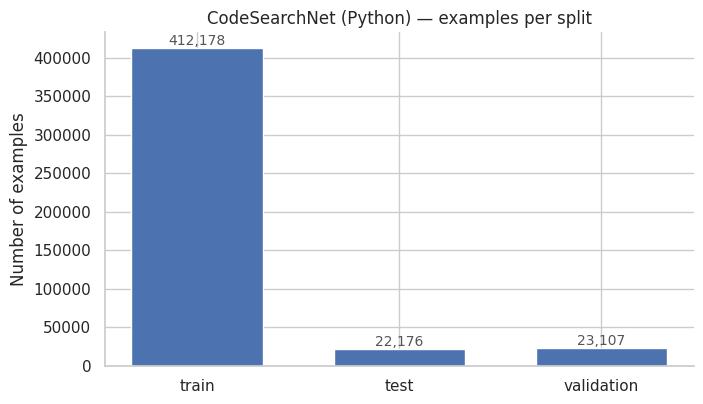

In [6]:
split_sizes = pd.DataFrame({
    "split": list(ds.keys()),
    "num_examples": [len(ds[s]) for s in ds.keys()],
})
split_sizes["percent"] = (split_sizes["num_examples"] / split_sizes["num_examples"].sum() * 100).round(1)

fig, ax = plt.subplots(figsize=(7.2, 4.2))
ax.bar(split_sizes["split"], split_sizes["num_examples"], color=PALETTE[0], width=0.65)
ax.set_title("CodeSearchNet (Python) — examples per split")
ax.set_ylabel("Number of examples")
for i, v in enumerate(split_sizes["num_examples"]):
    ax.text(i, v, f"{v:,}", ha="center", va="bottom", fontsize=10, color=INK_SECONDARY)
style_axis(ax)
fig.tight_layout()

show_table_and_chart(split_sizes.set_index("split"), fig, caption="Splits in this download", index=True)


Each bar is the number of examples this notebook's download counted in `train` / `validation` / `test`. **All three official splits** feed the working pipeline (filter → chunks → embeddings → Chroma). Official `validation` is renamed `val` in the chunk table; **`test` is still held out from training and tuning** and is not scored until Section 14.

Each record has `repository_name`, `func_path_in_repository`, `func_name`, `whole_func_string`, `func_code_string`, `func_documentation_string` (the docstring), and `func_code_url`. One live example is printed below.


In [7]:
ex = ds["train"][0]

def preview(text, n=3500):
    text = str(text)
    return text if len(text) <= n else text[:n] + "\n... [truncated]"

meta_keys = [repo_col] + ([path_col] if path_col else []) + ["func_name", "language"]
meta_df = pd.DataFrame(
    [{"field": k, "value": ex[k]} for k in meta_keys if k in ex]
).set_index("field")

title = ex.get("func_name", "(unnamed)")
url = ex.get("func_code_url", "")
code_preview = preview(ex[code_col])

display(Markdown(f"### Example record · `ds['train'][0]`\n\n**`{title}`**"))
display(meta_df)
display(Markdown(f"**Documentation** · `{doc_col}`\n\n{ex[doc_col]}"))
display(Markdown(f"**Code** · `{code_col}`\n\n````python\n{code_preview}\n````"))
if url:
    display(Markdown(f"[View on GitHub]({url})"))



### Example record · `ds['train'][0]`

**`AbstractElement.addidsuffix`**

,value
field,
repository_name,proycon/pynlpl
func_path_in_repository,pynlpl/formats/folia.py
func_name,AbstractElement.addidsuffix
language,python


**Documentation** · `func_documentation_string`

Appends a suffix to this element's ID, and optionally to all child IDs as well. There is sually no need to call this directly, invoked implicitly by :meth:`copy`

**Code** · `func_code_string`

````python
def addidsuffix(self, idsuffix, recursive = True):
        """Appends a suffix to this element's ID, and optionally to all child IDs as well. There is sually no need to call this directly, invoked implicitly by :meth:`copy`"""
        if self.id: self.id += idsuffix
        if recursive:
            for e in self:
                try:
                    e.addidsuffix(idsuffix, recursive)
                except Exception:
                    pass
````

[View on GitHub](https://github.com/proycon/pynlpl/blob/7707f69a91caaa6cde037f0d0379f1d42500a68b/pynlpl/formats/folia.py#L1263-L1271)

Each CodeSearchNet row has several text fields. This project uses two:

- **`func_code_string`** — the function body. This is what gets embedded, retrieved, and later explained by the model. It is preferred over `whole_func_string` so each chunk is one function, not surrounding code.
- **`func_documentation_string`** — the docstring. Used as the query in early retrieval checks, as the target for code→doc training, and as the reference when scoring explanations.

Using the same two fields everywhere keeps filtering, embeddings, LoRA, and the agent aligned.

For splits: this notebook uses the **full official** `train`, `validation`, and `test` sets. `validation` becomes `val` for tuning; **`test` is not touched for training or hyperparameter choices until the final section**, so final scores are not based on data already optimized on.


## 2. How long are functions and docstrings:
Chunking and embedding token budgets depend on the actual length distributions of code and docstrings. Computed live on the **full official `train` split**.


In [8]:
eda_df = ds["train"].to_pandas()

eda_df["code_len_chars"] = eda_df[code_col].astype(str).str.len()
eda_df["code_len_lines"] = eda_df[code_col].astype(str).str.count("\n") + 1
eda_df["doc_len_chars"] = eda_df[doc_col].astype(str).str.len()
eda_df["doc_len_words"] = eda_df[doc_col].astype(str).str.split().str.len()

print(f"EDA on full train: {len(eda_df):,} rows")
_preview = eda_df[[code_col, doc_col, repo_col, "code_len_lines", "doc_len_words"]].head(3).copy()
_preview[code_col] = _preview[code_col].astype(str).str.slice(0, 100) + "…"
_preview[doc_col] = _preview[doc_col].astype(str).str.slice(0, 100) + "…"
display(_preview)


EDA on full train: 412,178 rows


,func_code_string,func_documentation_string,repository_name,code_len_lines,doc_len_words
0,"def addidsuffix(self, idsuffix, recursive = True):\n """"""Appends a suffix to this element's ID,…","Appends a suffix to this element's ID, and optionally to all child IDs as well. There is sually no n…",proycon/pynlpl,9,28
1,"def setparents(self):\n """"""Correct all parent relations for elements within the scop. There is…",Correct all parent relations for elements within the scop. There is sually no need to call this dire…,proycon/pynlpl,6,22
2,"def setdoc(self,newdoc):\n """"""Set a different document. Usually no need to call this directly,…","Set a different document. Usually no need to call this directly, invoked implicitly by :meth:`copy`…",proycon/pynlpl,8,15


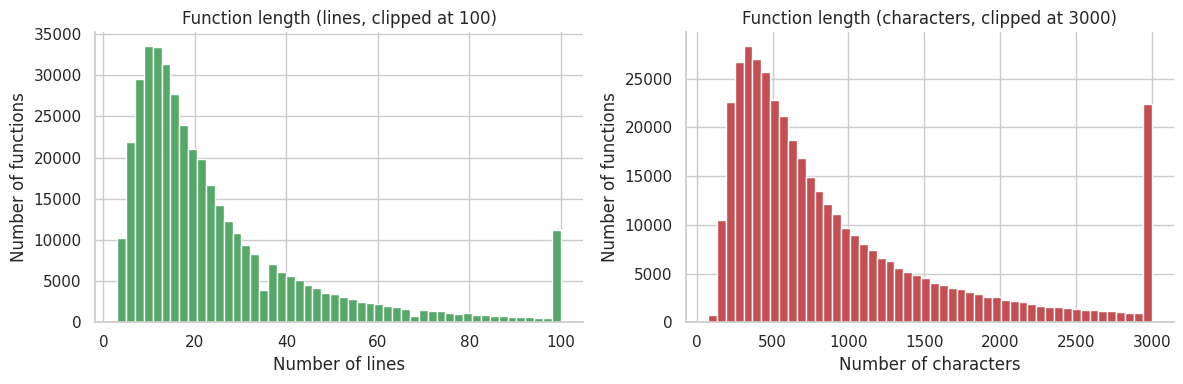

Code lines — median 18 | mean 26.8 | p90 53 | max 2,773


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(eda_df["code_len_lines"].clip(upper=100), bins=50, color=PALETTE[2])
axes[0].set_title("Function length (lines, clipped at 100)")
axes[0].set_xlabel("Number of lines")
axes[0].set_ylabel("Number of functions")
style_axis(axes[0])

axes[1].hist(eda_df["code_len_chars"].clip(upper=3000), bins=50, color=PALETTE[3])
axes[1].set_title("Function length (characters, clipped at 3000)")
axes[1].set_xlabel("Number of characters")
axes[1].set_ylabel("Number of functions")
style_axis(axes[1])

plt.tight_layout()
plt.show()

_s = eda_df["code_len_lines"]
print(f"Code lines — median {_s.median():.0f} | mean {_s.mean():.1f} | p90 {_s.quantile(0.9):.0f} | max {_s.max():,}")


Both panels are heavily right-skewed: most functions are short, with a long tail of much larger ones. That is why later steps use the **median**, not the mean, for "typical" function length — a few very long functions would pull the mean up and overstate a typical case.


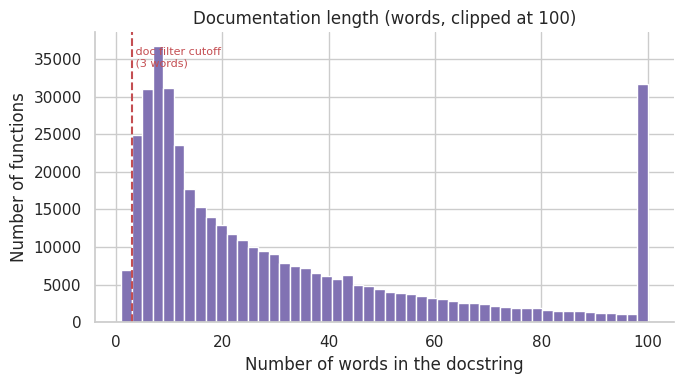

Doc words — median 19 | mean 37.7 | p90 84
At/below 3-word cutoff: 19,064/412,178 (4.6%)


In [10]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(eda_df["doc_len_words"].clip(upper=100), bins=50, color=PALETTE[4])
ax.set_title("Documentation length (words, clipped at 100)")
ax.set_xlabel("Number of words in the docstring")
ax.set_ylabel("Number of functions")

FILTER_PREVIEW_MIN_DOC_WORDS = 3
ax.axvline(FILTER_PREVIEW_MIN_DOC_WORDS, color=DECLINE_RED, linestyle="--", linewidth=1.5)
ax.text(FILTER_PREVIEW_MIN_DOC_WORDS, ax.get_ylim()[1] * 0.95,
        f" doc filter cutoff\n ({FILTER_PREVIEW_MIN_DOC_WORDS} words)",
        color=DECLINE_RED, ha="left", va="top", fontsize=8)
style_axis(ax)
plt.tight_layout()
plt.show()

_s = eda_df["doc_len_words"]
thin_doc = (_s <= FILTER_PREVIEW_MIN_DOC_WORDS).sum()
print(f"Doc words — median {_s.median():.0f} | mean {_s.mean():.1f} | p90 {_s.quantile(0.9):.0f}")
print(f"At/below {FILTER_PREVIEW_MIN_DOC_WORDS}-word cutoff: {thin_doc:,}/{len(eda_df):,} ({thin_doc/len(eda_df)*100:.1f}%)")


The red dashed line marks the doc-length filter from Section 3 (drop docstrings at or below 3 words). That cutoff removes only the thin left edge of the distribution — near-empty docstrings — not the bulk of real content.


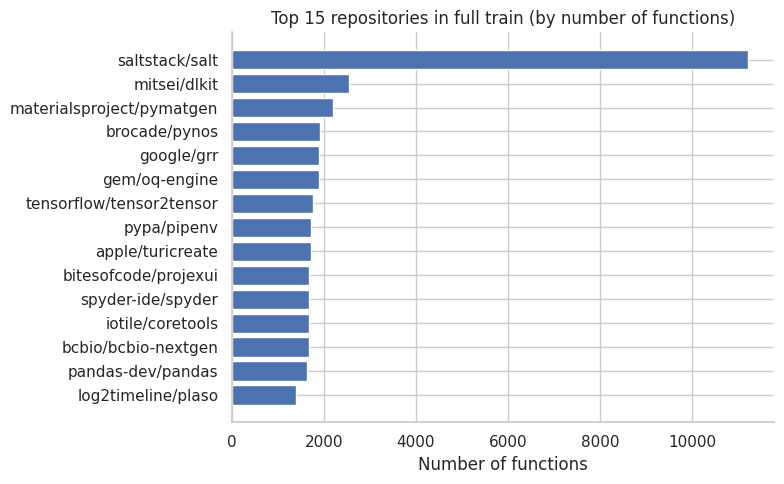

Number of unique repositories in full train: 12,231


In [11]:
top_repos_eda = eda_df[repo_col].value_counts().head(15)

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(top_repos_eda.index[::-1], top_repos_eda.values[::-1], color=PALETTE[0])
ax.set_title("Top 15 repositories in full train (by number of functions)")
ax.set_xlabel("Number of functions")
style_axis(ax)
plt.tight_layout()
plt.show()

print(f"Number of unique repositories in full train: {eda_df[repo_col].nunique():,}")


Even on the full `train` split, a few large repositories contribute far more functions than a typical repo — another long-tail pattern. That matters before picking "top repositories" for repo-filtered retrieval demos (Section 7): a naive pick would mostly rediscover the largest repos, so top-repo selection waits until the official `train` split is locked in the chunk table.

Median function length fits in a single embedding chunk, so no AST-based sub-function chunking is needed — one function = one chunk. A docstring-length filter around 3 words removes only the thin left tail.


## 3. Quality filtering: doc length, duplicates, language:
Empty, placeholder, or exact-duplicate documentation hurts retrieval (irrelevant matches) and generation training (bad targets). This section applies three filters, in order, on the **full official `train` + `validation` + `test`** sets. Exact code duplicates are dropped with preference for `train` over `val` over `test` when the same code appears in more than one split.


In [12]:
MIN_DOC_WORDS = 3
HF_SPLIT_TO_ALIAS = {"train": "train", "validation": "val", "test": "test"}

parts = []
for hf_split, alias in HF_SPLIT_TO_ALIAS.items():
    part = ds[hf_split].to_pandas()
    part["split"] = alias
    parts.append(part)
    print(f"Loaded official {hf_split:<12} {len(part):>10,} rows -> '{alias}'")

raw_full = pd.concat(parts, ignore_index=True)
# Prefer train over val over test when dropping exact-duplicate code later.
_split_rank = {"train": 0, "val": 1, "test": 2}
raw_full = (
    raw_full.assign(_split_rank=raw_full["split"].map(_split_rank))
    .sort_values("_split_rank", kind="mergesort")
    .drop(columns="_split_rank")
    .reset_index(drop=True)
)
N_RAW = len(raw_full)
print(f"Full working set (train+val+test): {N_RAW:,} rows")

df = raw_full.copy()
df["doc_len_words"] = df[doc_col].astype(str).str.split().str.len()

step_counts = [("Start", len(df))]

df = df[df["doc_len_words"] >= MIN_DOC_WORDS].copy()
step_counts.append((f"After doc_len_words >= {MIN_DOC_WORDS}", len(df)))

df = df[~df[code_col].duplicated(keep="first")].copy()
step_counts.append(("After exact-duplicate code removal", len(df)))

show_table(pd.DataFrame(step_counts, columns=["Filter step", "Rows remaining"]), index=False)


Loaded official train           412,178 rows -> 'train'
Loaded official validation       23,107 rows -> 'val'
Loaded official test             22,176 rows -> 'test'
Full working set (train+val+test): 457,461 rows


,Filter step,Rows remaining
0,Start,457461
1,After doc_len_words >= 3,449673
2,After exact-duplicate code removal,449673


### Is the documentation actually English?

`func_documentation_string` is assumed English, but the schema does not guarantee it — non-English docstrings would need separate handling for the embedding model and any generation target. `langdetect` is not deterministic by default (internal RNG), so its seed is fixed for reproducibility, matching the original project.


In [13]:
from langdetect import detect, DetectorFactory, LangDetectException

DetectorFactory.seed = 0

def safe_detect(text):
    text = str(text).strip()
    if len(text) < 3:
        return "unknown"
    try:
        return detect(text)
    except LangDetectException:
        return "unknown"

print("Running language detection on remaining docs (this is the slowest filter step)...")
df["doc_lang"] = df[doc_col].apply(safe_detect)

lang_counts = df["doc_lang"].value_counts()
print(lang_counts.head(10))

df = df[df["doc_lang"] == "en"].copy()
step_counts.append(("After non-English doc removal", len(df)))

filter_report = pd.DataFrame(step_counts, columns=["Filter step", "Rows remaining"])
filter_report["Removed"] = (-filter_report["Rows remaining"].diff().fillna(0)).astype(int)
show_table(filter_report, index=False)


Running language detection on remaining docs (this is the slowest filter step)...
doc_lang
en    429013
fr      4340
ca      3160
it      2224
da      1823
ro      1809
no      1463
es       840
pt       755
nl       753
Name: count, dtype: int64


,Filter step,Rows remaining,Removed
0,Start,457461,0
1,After doc_len_words >= 3,449673,7788
2,After exact-duplicate code removal,449673,0
3,After non-English doc removal,429013,20660


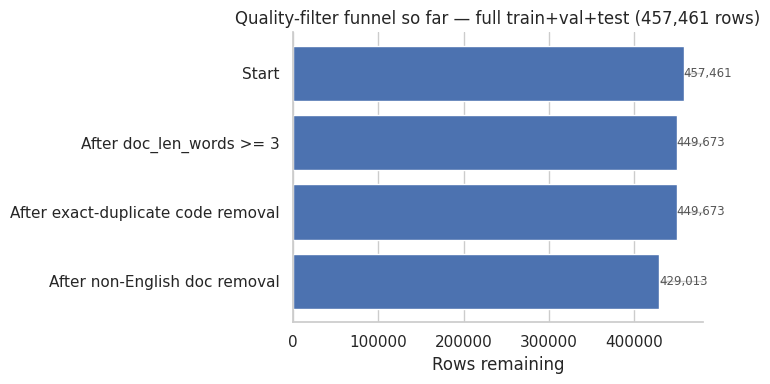

In [14]:
fig, ax = plt.subplots(figsize=(7.5, 4))
ax.barh(filter_report["Filter step"][::-1], filter_report["Rows remaining"][::-1], color=PALETTE[0])
ax.set_title(f"Quality-filter funnel so far — full train+val+test ({N_RAW:,} rows)")
ax.set_xlabel("Rows remaining")
for i, v in enumerate(filter_report["Rows remaining"][::-1]):
    ax.text(v, i, f"{v:,}", va="center", ha="left", fontsize=8.5, color=INK_SECONDARY)
style_axis(ax)
plt.tight_layout()
plt.show()


Each bar is how many rows remain after one more filter, reading top (start) to bottom (most filtered). The doc-length and duplicate-code filters barely move the bar — on mostly original GitHub code, empty docstrings and exact-duplicate functions are rare in the full corpus. Language filtering removes a real but modest slice; non-English documentation exists but is not the dominant case. Thus, the decision is to continue with `df` after these three filters; the token-budget filter (next section) is the last step before this becomes the chunk table.


## 4. Token-budget filter (512 tokens, doc+code combined):
Character and line counts are only a rough proxy — embedding models have a hard *token*
limit, and code tokenizes differently from prose. This applies a 512-token budget measured
with the embedding model's tokenizer as a filter on the full train+val+test working set. Without this
filter, overlong rows would be cut off by the embedding model without warning — better to
drop them here and count how many are lost.

**`sentence-transformers/all-MiniLM-L6-v2`** is used as the embedding model throughout
(here, in the retrieval baseline, and in the Chroma store). It is a practical default for
this project: small and fast enough to embed the full filtered corpus on a Colab GPU,
ungated on Hugging Face, and strong enough as a general semantic encoder for docstring↔code
matching. Its native context length is **512 tokens**, which is exactly the budget enforced
below — so the filter matches the model that actually runs, rather than an arbitrary cutoff.


In [15]:
from transformers import AutoTokenizer

EMBEDDING_MODEL_NAME = "sentence-transformers/all-MiniLM-L6-v2"
TOKEN_BUDGET = 512

embed_tokenizer = AutoTokenizer.from_pretrained(EMBEDDING_MODEL_NAME)
# Length checks only — filtering is done here; avoid "longer than 512" warnings.
embed_tokenizer.model_max_length = 10**9

df["chunk_text"] = df[doc_col].astype(str) + "\n\n" + df[code_col].astype(str)

print("Tokenizing full working set to apply the 512-token budget...")
_token_lens = []
_texts = df["chunk_text"].tolist()
_BATCH = 512
for start in range(0, len(_texts), _BATCH):
    batch = _texts[start:start + _BATCH]
    encoded = embed_tokenizer(batch, add_special_tokens=True, truncation=False, padding=False)
    _token_lens.extend(len(ids) for ids in encoded["input_ids"])
df["chunk_len_tokens"] = _token_lens

within_budget = df["chunk_len_tokens"] <= TOKEN_BUDGET
oversized_df = df[~within_budget].copy()

# Snapshot per-repo counts BEFORE df is overwritten below, so the repo-survival check
# (Section 6) can compare against the true pre-token-filter state.
pre_token_filter_repo_counts = df[repo_col].value_counts()

df = df[within_budget].copy()
_total = len(df) + len(oversized_df)
pct_kept = len(df) / _total * 100 if _total else 0.0
print(f"Within {TOKEN_BUDGET}-token budget: {len(df):,} rows ({pct_kept:.1f}%)")
print(f"Oversized (set aside, not embedded): {len(oversized_df):,} rows")
step_counts.append((f"After {TOKEN_BUDGET}-token budget filter", len(df)))


Tokenizing full working set to apply the 512-token budget...
Within 512-token budget: 347,590 rows (81.0%)
Oversized (set aside, not embedded): 81,423 rows


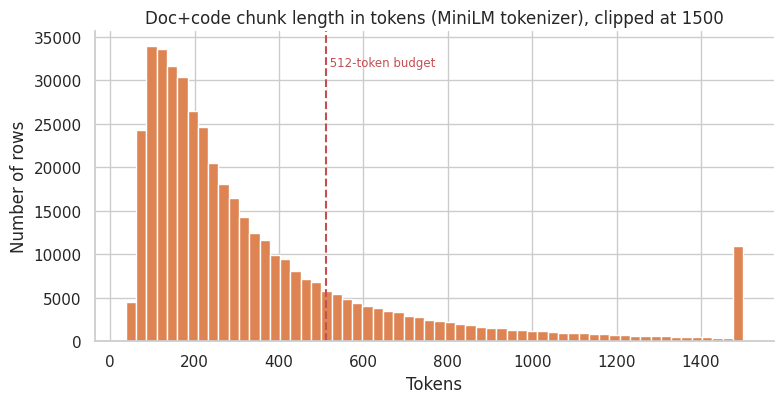

In [16]:
fig, ax = plt.subplots(figsize=(8, 4.2))
all_lens = pd.concat([df["chunk_len_tokens"], oversized_df["chunk_len_tokens"]])
ax.hist(all_lens.clip(upper=1500), bins=60, color=PALETTE[1])
ax.axvline(TOKEN_BUDGET, color=DECLINE_RED, linestyle="--", linewidth=1.5)
ax.text(TOKEN_BUDGET, ax.get_ylim()[1] * 0.92, f" {TOKEN_BUDGET}-token budget",
        color=DECLINE_RED, ha="left", va="top", fontsize=8.5)
ax.set_title("Doc+code chunk length in tokens (MiniLM tokenizer), clipped at 1500")
ax.set_xlabel("Tokens")
ax.set_ylabel("Number of rows")
style_axis(ax)
plt.tight_layout()
plt.show()


Token-length distribution of this run's doc+code chunks, measured with the embedding model's
tokenizer — not a character-length proxy. The red line is the 512-token cutoff.

**`oversized_df`** holds the rows that failed that cutoff (doc+code longer than 512 tokens).
It is created in the cell above when the working set is split into within-budget vs. over
budget. It is kept for two reasons only:

1. **This chart** — so the histogram shows the full length distribution, including what was
   rejected, not only the rows that survived.
2. **Accounting** — the printout reports how many rows were set aside instead of embedding
   them after silent truncation.

It is **not** used again later. From Section 6 onward the chunk table, Chroma store, LoRA
data, and agent all come from the filtered `df` (within budget) only. `oversized_df` is a
side table for this diagnostic, not a second pipeline path.


## 5. Baseline retrieval — a reality check

Before the full pipeline, a simple question: does semantic retrieval actually help, or do docstrings and code share enough vocabulary that plain word overlap would do almost as well?

The same **self-retrieval** task is run three ways on a 15K-function sample drawn from full train (Section 2): given a query, recover that row’s own code in the top-*k*.

1. **Embeddings** — encode docstring and code with `all-MiniLM-L6-v2`, rank by cosine similarity.
2. **BM25** — lexical baseline (term overlap only). If it nearly matches the embedder, the “semantic” gain is mostly shared wording.
3. **Hand-written paraphrases** (n=8) — natural questions instead of the raw docstring; closer to how a user would ask.

Metrics use the known correct chunk (not soft relevance labels):

- **Hit@k** (*k* = 1, 5, 10) — how often the true chunk lands in the top *k* (Hit@1 = first place).
- **MRR** — mean of `1/rank`; still rewards near-misses (2nd, 3rd, …).


In [17]:
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
from rank_bm25 import BM25Okapi

CORPUS_SIZE = 15000
QUERY_SAMPLE_SIZE = 300
RETRIEVAL_KS = [1, 5, 10]
RETRIEVAL_MIN_DOC_WORDS = 3
RETRIEVAL_BATCH_SIZE = 64
N_PARAPHRASE_EXAMPLES = 8

retrieval_pool = eda_df[eda_df["doc_len_words"] > RETRIEVAL_MIN_DOC_WORDS].copy()
corpus_df = retrieval_pool.sample(
    n=min(CORPUS_SIZE, len(retrieval_pool)), random_state=42,
).reset_index(drop=True)
corpus_df["corpus_pos"] = np.arange(len(corpus_df))

query_df = corpus_df.sample(
    n=min(QUERY_SAMPLE_SIZE, len(corpus_df)), random_state=1,
).reset_index(drop=True)
query_df["true_corpus_pos"] = query_df["corpus_pos"].values

print(f"Loading embedding model: {EMBEDDING_MODEL_NAME}...")
embedding_model = SentenceTransformer(EMBEDDING_MODEL_NAME, device=device)

print("Embedding corpus (code) and docstring queries...")
corpus_code_embeddings = embedding_model.encode(
    corpus_df[code_col].tolist(), batch_size=RETRIEVAL_BATCH_SIZE, show_progress_bar=False,
)
query_doc_embeddings = embedding_model.encode(
    query_df[doc_col].tolist(), batch_size=RETRIEVAL_BATCH_SIZE, show_progress_bar=False,
)


def _hitk_mrr(true_positions, sim_matrix, ks=RETRIEVAL_KS):
    hits_at_k = {k: 0 for k in ks}
    reciprocal_ranks = []
    for i, true_pos in enumerate(true_positions):
        order = np.argsort(sim_matrix[i])[::-1]
        for k in ks:
            if true_pos in order[:k]:
                hits_at_k[k] += 1
        rank_matches = np.where(order == true_pos)[0]
        reciprocal_ranks.append(1 / (rank_matches[0] + 1) if len(rank_matches) else 0.0)
    n = len(true_positions)
    out = {f"Hit@{k}": hits_at_k[k] / n * 100 for k in ks}
    out["MRR"] = float(np.mean(reciprocal_ranks))
    return out


# 1) Embedding baseline — docstring as query
embed_metrics = _hitk_mrr(
    query_df["true_corpus_pos"].to_numpy(),
    cosine_similarity(query_doc_embeddings, corpus_code_embeddings),
)

# 2) BM25 lexical baseline — same corpus / queries
def bm25_tokenize(text):
    return re.findall(r"[a-zA-Z_][a-zA-Z0-9_]*", str(text).lower())

bm25_index = BM25Okapi([bm25_tokenize(c) for c in corpus_df[code_col]])
bm25_score_matrix = np.vstack([
    bm25_index.get_scores(bm25_tokenize(q)) for q in query_df[doc_col]
])
bm25_metrics = _hitk_mrr(query_df["true_corpus_pos"].to_numpy(), bm25_score_matrix)

# 3) Paraphrased natural-language queries (n=8)
paraphrase_sample = query_df.sample(
    n=min(N_PARAPHRASE_EXAMPLES, len(query_df)), random_state=3,
).reset_index(drop=True)
manual_paraphrases = [
    "How do I delete empty nested dictionaries?",
    "How do I restore datasets from a catalog to a portal?",
    "How do I sort a dictionary and get key-value pairs?",
    "How do I parse times with verbose output?",
    "How do I create SSL options?",
    "How do I load JSON configuration parameters from a data buffer?",
    "How do I prepare to replace a handler?",
    "How do I get a list of type choices?",
][: len(paraphrase_sample)]
paraphrase_sample["paraphrased_query"] = manual_paraphrases

paraphrase_query_embeddings = embedding_model.encode(
    paraphrase_sample["paraphrased_query"].tolist(),
    batch_size=RETRIEVAL_BATCH_SIZE,
    show_progress_bar=False,
)
paraphrase_metrics = _hitk_mrr(
    paraphrase_sample["true_corpus_pos"].to_numpy(),
    cosine_similarity(paraphrase_query_embeddings, corpus_code_embeddings),
)

print(
    f"Done. Corpus={len(corpus_df):,} | docstring queries={len(query_df):,} | "
    f"paraphrases={len(paraphrase_sample)}"
)


Loading embedding model: sentence-transformers/all-MiniLM-L6-v2...
Embedding corpus (code) and docstring queries...
Done. Corpus=15,000 | docstring queries=300 | paraphrases=8


In [18]:
# One scorecard for all three Section 5 checks
section5_metrics = pd.DataFrame({
    "Docstring → embed": embed_metrics,
    "BM25 (lexical)": bm25_metrics,
    f"Paraphrase (n={len(paraphrase_sample)})": paraphrase_metrics,
}).T[["Hit@1", "Hit@5", "Hit@10", "MRR"]]

section5_display = section5_metrics.copy()
for col in ("Hit@1", "Hit@5", "Hit@10"):
    section5_display[col] = section5_display[col].map(lambda x: f"{x:.1f}%")
section5_display["MRR"] = section5_display["MRR"].map(lambda x: f"{x:.3f}")

print("Section 5 — retrieval scorecard")
show_table(section5_display, index=True)


Section 5 — retrieval scorecard


,Hit@1,Hit@5,Hit@10,MRR
Docstring → embed,91.0%,97.7%,98.3%,0.938
BM25 (lexical),98.7%,99.7%,99.7%,0.991
Paraphrase (n=8),0.0%,0.0%,0.0%,0.000


In [19]:
# How the 8 hardcoded paraphrases map to the sampled rows
# (paraphrase_sample is query_df.sample(..., random_state=3); paraphrases are assigned by row order)

_pair_df = paraphrase_sample[[
    "true_corpus_pos",
    repo_col,
    doc_col,
    "paraphrased_query",
]].copy()
_pair_df.insert(0, "Q", range(len(_pair_df)))
_pair_df = _pair_df.rename(columns={
    "true_corpus_pos": "Corpus pos",
    repo_col: "Repo",
    doc_col: "Original docstring (sampled)",
    "paraphrased_query": "Paraphrase in code",
})
# Keep the table readable in the notebook
_pair_df["Original docstring (sampled)"] = (
    _pair_df["Original docstring (sampled)"]
    .astype(str)
    .str.replace(r"\s+", " ", regex=True)
    .str.slice(0, 160)
    .map(lambda s: s + ("…" if len(s) >= 160 else ""))
)

display(Markdown(
    "### Paraphrase pairing — sampled docstring ↔ hardcoded question\n\n"
    f"Sampled **{len(_pair_df)}** rows from `query_df` with `random_state=3`. "
    "Each row *i* receives `manual_paraphrases[i]` (positional match, not automatic rewriting)."
))
display(_pair_df)


### Paraphrase pairing — sampled docstring ↔ hardcoded question

Sampled **8** rows from `query_df` with `random_state=3`. Each row *i* receives `manual_paraphrases[i]` (positional match, not automatic rewriting).

,Q,Corpus pos,Repo,Original docstring (sampled),Paraphrase in code
0,0,11936,andy29485/embypy,reload object info from emby |coro| Parameters ---------- fields : str additional fields to request when updating Se...,How do I delete empty nested dictionaries?
1,1,7120,LogicalDash/LiSE,"If I'm being dragged, move to follow the touch.",How do I restore datasets from a catalog to a portal?
2,2,663,aichaos/rivescript-python,"For debugging, dump the entire data structure.",How do I sort a dictionary and get key-value pairs?
3,3,9950,tcalmant/ipopo,Clears the event dispatcher,How do I parse times with verbose output?
4,4,5284,arcus-io/puppetdb-python,Returns facts by name :param api_url: Base PuppetDB API url :param fact_name: Name of fact,How do I create SSL options?
5,5,8473,Chilipp/psyplot,"Exports the figures of the project to one or more image files Parameters ---------- output: str, iterable or matplot...",How do I load JSON configuration parameters from a data buffer?
6,6,11044,celery/django-celery,Store the result of an executed group.,How do I prepare to replace a handler?
7,7,4679,awslabs/sockeye,Update the flag indicating whether any process exited and did not provide a result.,How do I get a list of type choices?


### What this table shows

Eight sampled functions. The left side is each function’s real docstring; the right side is a natural-language question written by hand for that same row.

The questions are deliberately *not* close rewrites of the docstrings. The next cell checks whether retrieval still finds the correct function when the query looks more like something a user would type.


In [20]:
# Paraphrase examples: question asked vs. top retrieved code
_para_sim = cosine_similarity(paraphrase_query_embeddings, corpus_code_embeddings)
_top_k = 3

summary_rows = []
topk_rows = []

for i in range(len(paraphrase_sample)):
    true_pos = int(paraphrase_sample.iloc[i]["true_corpus_pos"])
    order = np.argsort(_para_sim[i])[::-1]
    rank = int(np.where(order == true_pos)[0][0]) + 1
    if rank == 1:
        status = "Hit@1"
    elif rank <= 5:
        status = "In top-5"
    else:
        status = "Miss"

    true_doc = str(paraphrase_sample.iloc[i][doc_col])
    summary_rows.append({
        "Q": i,
        "Question": str(paraphrase_sample.iloc[i]["paraphrased_query"]),
        "Rank": rank,
        "Status": status,
        "Gold repo": str(paraphrase_sample.iloc[i][repo_col]),
        "Gold docstring": true_doc[:180] + ("…" if len(true_doc) > 180 else ""),
    })

    for r, pos in enumerate(order[:_top_k], start=1):
        row = corpus_df.iloc[int(pos)]
        topk_rows.append({
            "Q": i,
            "Retrieved rank": r,
            "True chunk": "yes" if int(pos) == true_pos else "",
            "Repo": str(row[repo_col]),
            "Code snippet": str(row[code_col])[:220] + "…",
        })

summary_df = pd.DataFrame(summary_rows)
topk_df = pd.DataFrame(topk_rows)

display(Markdown("### Paraphrase examples — question vs. top retrieved code"))
display(Markdown("Summary (one row per paraphrased query):"))
display(summary_df)
display(Markdown(
    f"Top-{_top_k} retrieved snippets per query "
    "(`True chunk` marks the gold row):"
))
display(topk_df)



### Paraphrase examples — question vs. top retrieved code

Summary (one row per paraphrased query):

,Q,Question,Rank,Status,Gold repo,Gold docstring
0,0,How do I delete empty nested dictionaries?,10507,Miss,andy29485/embypy,reload object info from emby\n\n |coro|\n\n Parameters\n ----------\n fields : str\n additional fie...
1,1,How do I restore datasets from a catalog to a portal?,14874,Miss,LogicalDash/LiSE,"If I'm being dragged, move to follow the touch."
2,2,How do I sort a dictionary and get key-value pairs?,4303,Miss,aichaos/rivescript-python,"For debugging, dump the entire data structure."
3,3,How do I parse times with verbose output?,7663,Miss,tcalmant/ipopo,Clears the event dispatcher
4,4,How do I create SSL options?,2451,Miss,arcus-io/puppetdb-python,Returns facts by name\n\n :param api_url: Base PuppetDB API url\n :param fact_name: Name of fact
5,5,How do I load JSON configuration parameters from a data buffer?,4102,Miss,Chilipp/psyplot,Exports the figures of the project to one or more image files\n\n Parameters\n ----------\n out...
6,6,How do I prepare to replace a handler?,5654,Miss,celery/django-celery,Store the result of an executed group.
7,7,How do I get a list of type choices?,14247,Miss,awslabs/sockeye,Update the flag indicating whether any process exited and did not provide a result.


Top-3 retrieved snippets per query (`True chunk` marks the gold row):

,Q,Retrieved rank,True chunk,Repo,Code snippet
0,0,1,,SuperCowPowers/workbench,"def clean_for_storage(self, data):\n """"""Clean data in preparation for storage.\n\n Deletes items with ..."
1,0,2,,learningequality/ricecooker,"def _clean_dict(row):\n """"""\n Transform empty strings values of dict `row` to None.\n """"""\n row_cleaned ..."
2,0,3,,tensorflow/tensor2tensor,"def _flatten_dict(original_dict):\n """"""Flatten dict of dicts into a single dict with appropriate prefixes.\n\n Han..."
3,1,1,,OCHA-DAP/hdx-python-api,"def get_datasets(self):\n # type: () -> List[hdx.data.dataset.Dataset]\n """"""Get any datasets in the sh..."
4,1,2,,emory-libraries/eulxml,"def generate_catalog(xsd_schemas=None, xmlcatalog_dir=None, xmlcatalog_file=None):\n """"""Generating an XML catalog..."
...,...,...,...,...,...
19,6,2,,RudolfCardinal/pythonlib,"def apply_handler_to_root_log(handler: logging.Handler,\n remove_existing: bool = False..."
20,6,3,,hubo1016/vlcp,"def registerAllHandlers(self, handlerDict):\n '''\n Register self to scheduler\n '''\n s..."
21,7,1,,Microsoft/knack,"def enum_choice_list(data):\n """""" Creates the argparse choices and type kwargs for a supplied enum type or list o..."
22,7,2,,UMIACS/qav,"def choices(self):\n """""" Print the choices for this question.\n\n This may be a empty string and i..."


### What these tables show

**Summary** — one row per question: where the correct function ranked (Hit@1 / top-5 / miss).

**Top-3** — what the retriever actually returned for each question. `True chunk` is marked only if that hit is the correct function.

### What the tables say

All eight paraphrased questions are **Miss**. The gold function never lands in the top-5; ranks sit in the thousands (about 2.5K–14.9K out of 15,000). So this is not a near-miss — the true chunk is effectively lost in the corpus.

The Top-3 table backs that up: **`True chunk` is empty for every row**. The snippets that do come back often share surface words with the question (e.g. “dict”, “catalog”, “choices”), but they are the wrong functions. Retrieval is matching fluent phrasing, not the intended API.

Together with the scorecard above (~91% Hit@1 for docstring queries vs 0% here), these tables show the practical gap: docstring-as-query looks strong; a short natural question does not recover the same code.


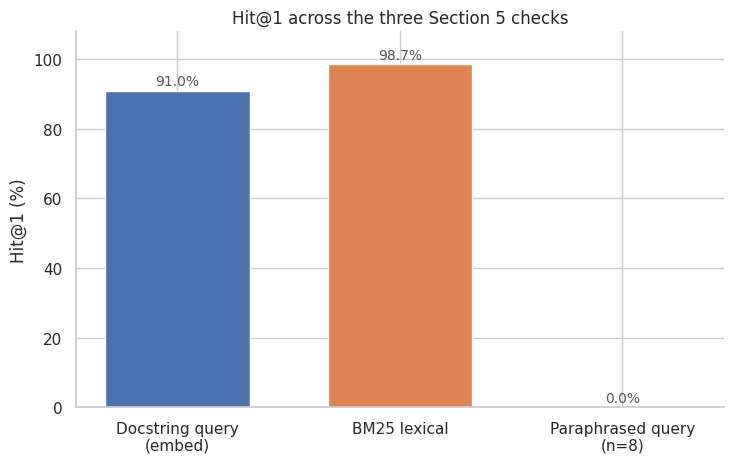

In [21]:
comparison_labels = [
    "Docstring query\n(embed)",
    "BM25 lexical",
    f"Paraphrased query\n(n={len(paraphrase_sample)})",
]
comparison_hit1 = [
    embed_metrics["Hit@1"],
    bm25_metrics["Hit@1"],
    paraphrase_metrics["Hit@1"],
]
bar_colors = [PALETTE[0], PALETTE[1], DECLINE_RED]

fig, ax = plt.subplots(figsize=(7.5, 4.8))
bars = ax.bar(comparison_labels, comparison_hit1, color=bar_colors, width=0.65)
ax.set_title("Hit@1 across the three Section 5 checks")
ax.set_ylabel("Hit@1 (%)")
ax.set_ylim(0, 108)
for b, v in zip(bars, comparison_hit1):
    ax.text(b.get_x() + b.get_width() / 2, v + 1.5, f"{v:.1f}%", ha="center", fontsize=10, color=INK_SECONDARY)
style_axis(ax)
plt.tight_layout()
plt.show()


### What the numbers say

On this run, Section 5’s three retrieval checks say the same thing in plain numbers. The paraphrase drop is even sharper than in the original exploration notebook (~62.5% Hit@1 on a smaller corpus there; **0%** here):

| Check | Hit@1 | Takeaway |
|---|---|---|
| Docstring → embed | ~91% | Looks strong on paper |
| BM25 (lexical) | ~99% | **Higher** than the embedder |
| Paraphrased queries (n=8) | 0.0% | None of the 8 landed in the top 10 out of 15,000 candidates on this run's corpus |

Two conclusions follow:

1. **Lexical overlap is doing most of the work.** BM25 beating the embedding model on Hit@1: shared tokens between docstring and code (names, verbs, identifiers) nearly solve self-retrieval. A high embedding score here is not, by itself, strong evidence of semantic understanding.

2. **Docstring-as-query overstates real-user retrieval, badly.** Rewording the same eight queries as natural questions collapsed Hit@1 from ~91% to 0% on this run — every one of the 8 true chunks ranked in the thousands out of 15,000, not just outside the top 10. Later notebook numbers (and the Agent in Section 12) still use docstring-style queries, so they inherit that gap. Treat the paraphrase check as directional only — n=8 — but the direction is unambiguous.

Due to the results, the pipeline keeps the embedder as the retrieval backbone, but read the docstring→code Hit@k figures with these two caveats attached.


## 6. Building the pipeline: the chunk table, and what got lost along the way:
`df` (Sections 3–4) now has the three quality filters and the token-budget filter applied. This cell turns it into the chunk table used downstream (RAG store, LoRA data), with a running count of what each filter removed.


In [22]:
chunk_cols = [repo_col, doc_col, code_col, "chunk_text", "doc_len_words", "chunk_len_tokens", "split"]
if path_col:
    chunk_cols.insert(1, path_col)

chunks_df = df[chunk_cols].reset_index(drop=True)
chunks_df["chunk_id"] = chunks_df.index.astype(str)

print(f"Final chunk table: {len(chunks_df):,} chunks")
print(chunks_df["split"].value_counts().reindex(["train", "val", "test"]).to_string())
_preview = chunks_df.head(3).copy()
for col in (code_col, doc_col, "chunk_text"):
    if col in _preview.columns:
        _preview[col] = _preview[col].astype(str).str.slice(0, 100) + "…"
display(_preview)


Final chunk table: 347,590 chunks
split
train    313620
val       17007
test      16963


,repository_name,func_path_in_repository,func_documentation_string,func_code_string,chunk_text,doc_len_words,chunk_len_tokens,split,chunk_id
0,proycon/pynlpl,pynlpl/formats/folia.py,"Appends a suffix to this element's ID, and optionally to all child IDs as well. There is sually no n…","def addidsuffix(self, idsuffix, recursive = True):\n """"""Appends a suffix to this element's ID,…","Appends a suffix to this element's ID, and optionally to all child IDs as well. There is sually no n…",28,166,train,0
1,proycon/pynlpl,pynlpl/formats/folia.py,Correct all parent relations for elements within the scop. There is sually no need to call this dire…,"def setparents(self):\n """"""Correct all parent relations for elements within the scop. There is…",Correct all parent relations for elements within the scop. There is sually no need to call this dire…,22,111,train,1
2,proycon/pynlpl,pynlpl/formats/folia.py,"Set a different document. Usually no need to call this directly, invoked implicitly by :meth:`copy`…","def setdoc(self,newdoc):\n """"""Set a different document. Usually no need to call this directly,…","Set a different document. Usually no need to call this directly, invoked implicitly by :meth:`copy`\n…",15,123,train,2


### A docstring-free version of the code, for the code→doc task

`func_code_string` is real source code, so it already contains the ground-truth docstring as the function's triple-quoted string. If the model sees that full code and is asked to "write a docstring," it can copy the existing string instead of describing the function. A training run in the original project confirmed this: after only 50 steps, an adapter's output matched the ground truth word-for-word. Every later generation step in this notebook (LoRA training, Agent, TEST evaluation) uses the docstring-stripped version, `func_code_no_doc`, computed with `ast` below.


In [23]:
def strip_docstring(code_text):
    '''Removes a function's docstring from its source text - uses `ast` to find the
    docstring's exact line span and deletes those lines; returns the text unchanged if it
    doesn't parse (rare corpus edge cases - safer to under-strip than to corrupt the code).'''
    original_lines = str(code_text).splitlines(keepends=True)
    try:
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")  # non-raw backslash escapes in real GitHub code -> noisy SyntaxWarning
            tree = ast.parse(textwrap.dedent(str(code_text)))
    except SyntaxError:
        return code_text
    for node in ast.walk(tree):
        if isinstance(node, (ast.FunctionDef, ast.AsyncFunctionDef)):
            if (node.body and isinstance(node.body[0], ast.Expr)
                    and isinstance(getattr(node.body[0], "value", None), ast.Constant)
                    and isinstance(node.body[0].value.value, str)):
                doc_node = node.body[0]
                start, end = doc_node.lineno - 1, doc_node.end_lineno
                new_lines = original_lines[:start] + original_lines[end:]
                return "".join(new_lines) if len(new_lines) < len(original_lines) else code_text
    return code_text


print("Computing func_code_no_doc for the full chunk table (once per row)...")
chunks_df["func_code_no_doc"] = chunks_df[code_col].apply(strip_docstring)

n_unchanged = (chunks_df["func_code_no_doc"] == chunks_df[code_col]).sum()
print(f"Rows where strip_docstring found nothing to remove (no docstring, or unparseable): "
      f"{n_unchanged:,} / {len(chunks_df):,} ({n_unchanged / len(chunks_df) * 100:.1f}%)")


Computing func_code_no_doc for the full chunk table (once per row)...
Rows where strip_docstring found nothing to remove (no docstring, or unparseable): 2,907 / 347,590 (0.8%)


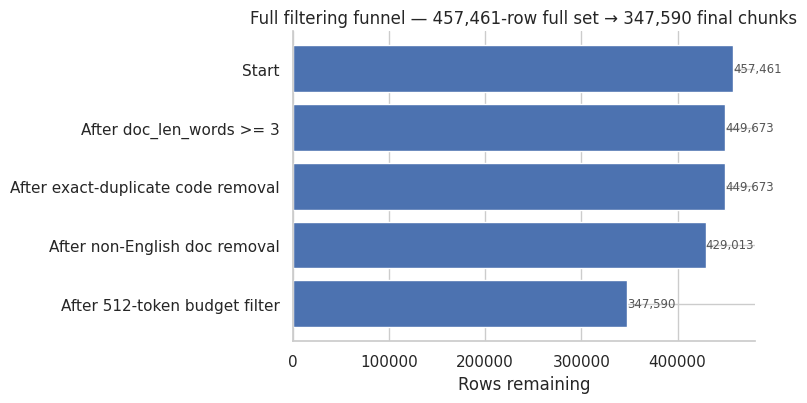

Final chunk table: 347,590 chunks - 76.0% of the original 457,461-row full set retained.


In [24]:
fig, ax = plt.subplots(figsize=(8, 4.2))
funnel_labels = [s for s, _ in step_counts]
funnel_values = [v for _, v in step_counts]
ax.barh(funnel_labels[::-1], funnel_values[::-1], color=PALETTE[0])
ax.set_title(f"Full filtering funnel — {N_RAW:,}-row full set → {len(chunks_df):,} final chunks")
ax.set_xlabel("Rows remaining")
for i, v in enumerate(funnel_values[::-1]):
    ax.text(v, i, f"{v:,}", va="center", ha="left", fontsize=8.5, color=INK_SECONDARY)
style_axis(ax)
plt.tight_layout()
plt.show()
print(f"Final chunk table: {len(chunks_df):,} chunks - "
      f"{len(chunks_df)/N_RAW:.1%} of the original {N_RAW:,}-row full set retained.")


The funnel below starts from the full official train+val+test set and applies each filter in turn, ending at the final chunk table used for the RAG store and LoRA training pool. The drop at each step shows which filter removed the most rows. On CodeSearchNet, that is usually the 512-token budget; the quality filters (doc length, dedup, language) each remove only a small slice.

### Did filtering distort the data, or just trim a tail?

None of the four filters aims at code length on purpose, but the token-budget filter tends to drop longer functions. The next charts compare the original full working set to the final chunk table to check whether the overall length profile changed — or whether only a thin tail of very long examples was cut.


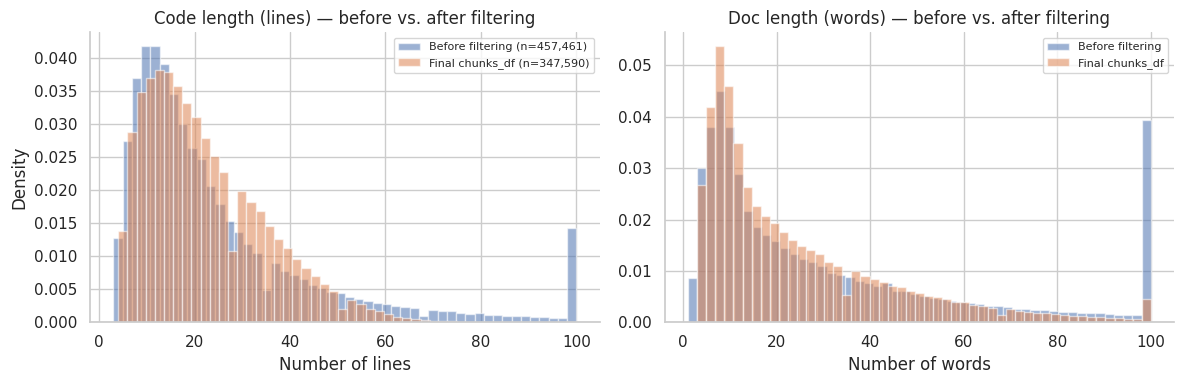

Median code lines — before 18 | final 20
Median doc words  — before 19 | final 17


In [25]:
raw_pdf = raw_full
_raw_code_lines = raw_pdf[code_col].astype(str).str.count("\n").add(1)
_raw_doc_words = raw_pdf[doc_col].astype(str).str.split().str.len()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(_raw_code_lines.clip(upper=100), bins=50, alpha=0.55,
             label=f"Before filtering (n={N_RAW:,})", color=PALETTE[0], density=True)
axes[0].hist(chunks_df["chunk_text"].str.count("\n").clip(upper=100), bins=50, alpha=0.55,
             label=f"Final chunks_df (n={len(chunks_df):,})", color=PALETTE[1], density=True)
axes[0].set_title("Code length (lines) — before vs. after filtering")
axes[0].set_xlabel("Number of lines")
axes[0].set_ylabel("Density")
axes[0].legend(fontsize=8)
style_axis(axes[0])

axes[1].hist(_raw_doc_words.clip(upper=100), bins=50, alpha=0.55, label="Before filtering", color=PALETTE[0], density=True)
axes[1].hist(chunks_df["doc_len_words"].clip(upper=100), bins=50, alpha=0.55, label="Final chunks_df", color=PALETTE[1], density=True)
axes[1].set_title("Doc length (words) — before vs. after filtering")
axes[1].set_xlabel("Number of words")
axes[1].legend(fontsize=8)
style_axis(axes[1])

plt.tight_layout()
plt.show()
print(f"Median code lines — before {_raw_code_lines.median():.0f} | final {chunks_df['chunk_text'].str.count(chr(10)).median():.0f}")
print(f"Median doc words  — before {_raw_doc_words.median():.0f} | final {chunks_df['doc_len_words'].median():.0f}")


Both charts use *density* (share of the set), not raw counts, so the before (full working set) and after (final chunks) curves are comparable. Expect the after curve to track the before curve closely, with a thinner long right tail where the 512-token budget cuts outliers. As a result, filtering should mostly cut very long functions; a typical function still looks the same, so the filtered corpus is fine to keep using.


Repos with >= 10 rows before the token filter: 6593
Median survival rate: 88.5%


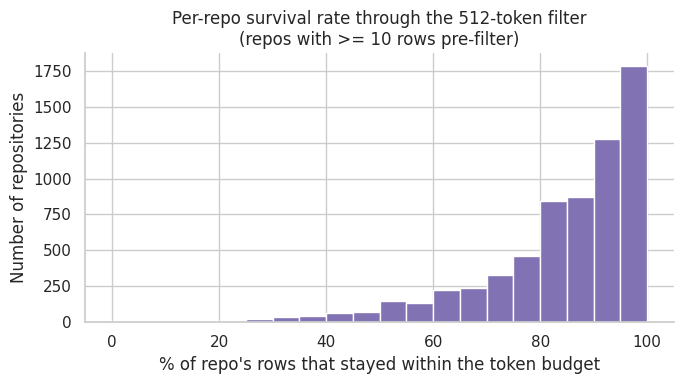

Repos with < 20% survival (effectively erased by the filter): 32 / 6593


In [26]:
MIN_ROWS_FOR_SURVIVAL_CHECK = 10

post_token_counts = chunks_df[repo_col].value_counts()
survival = pd.DataFrame({
    "rows_before_token_filter": pre_token_filter_repo_counts,
    "rows_after_token_filter": post_token_counts.reindex(pre_token_filter_repo_counts.index).fillna(0).astype(int),
})
survival = survival[survival["rows_before_token_filter"] >= MIN_ROWS_FOR_SURVIVAL_CHECK]
survival["survival_rate_pct"] = (survival["rows_after_token_filter"] / survival["rows_before_token_filter"] * 100).round(1)
survival = survival.sort_values("survival_rate_pct")

print(f"Repos with >= {MIN_ROWS_FOR_SURVIVAL_CHECK} rows before the token filter: {len(survival)}")
if len(survival):
    print(f"Median survival rate: {survival['survival_rate_pct'].median()}%")

fig, ax = plt.subplots(figsize=(7, 4))
if len(survival):
    ax.hist(survival["survival_rate_pct"], bins=20, color=PALETTE[4])
ax.set_title("Per-repo survival rate through the 512-token filter\n"
              f"(repos with >= {MIN_ROWS_FOR_SURVIVAL_CHECK} rows pre-filter)")
ax.set_xlabel("% of repo's rows that stayed within the token budget")
ax.set_ylabel("Number of repositories")
style_axis(ax)
plt.tight_layout()
plt.show()

n_wiped_out = (survival["survival_rate_pct"] < 20).sum() if len(survival) else 0
print(f"Repos with < 20% survival (effectively erased by the filter): {n_wiped_out} / {len(survival)}")


Each bar is one repository; the x-axis is the share of its rows that stayed under the 512-token budget. Across 6,593 repos with at least 10 rows before the token filter, the median survival rate is 88.5%, and only 32 repos (~0.5%) fell below 20% survival. The filter is mostly even across repos — a few wordy repos lose coverage, but that is rare. Therefore, the work continues with `chunks_df` — the filters cleaned the data without changing the overall picture.


## 7. Train / val / test — official CodeSearchNet splits (repo-disjoint):
CodeSearchNet already splits by **repository**: a repo that appears in `train` does not appear in `validation`/`test`. This notebook **keeps those official labels** (with `validation` → `val`). The next cell only verifies that the filtered chunk table still has no repository overlap across splits.


In [27]:
# Official split labels were attached when loading train/validation/test (Section 3).
assert "split" in chunks_df.columns, "chunks_df is missing the official split column"
assert set(chunks_df["split"].unique()) <= {"train", "val", "test"}

train_repos = set(chunks_df.loc[chunks_df["split"] == "train", repo_col].unique())
val_repos = set(chunks_df.loc[chunks_df["split"] == "val", repo_col].unique())
test_repos = set(chunks_df.loc[chunks_df["split"] == "test", repo_col].unique())

split_summary = chunks_df.groupby("split").agg(
    n_chunks=("chunk_id", "count"), n_repos=(repo_col, "nunique"),
).reindex(["train", "val", "test"])
split_summary["pct_chunks"] = (split_summary["n_chunks"] / split_summary["n_chunks"].sum() * 100).round(1)
display(split_summary)

assert set(train_repos) & set(val_repos) == set(), "Repo leakage between train/val!"
assert set(train_repos) & set(test_repos) == set(), "Repo leakage between train/test!"
assert set(val_repos) & set(test_repos) == set(), "Repo leakage between val/test!"
print("No repository overlap across official splits (verified on filtered chunks).")


,n_chunks,n_repos,pct_chunks
split,,,
train,313620,11724,90.2
val,17007,646,4.9
test,16963,651,4.9


No repository overlap across official splits (verified on filtered chunks).


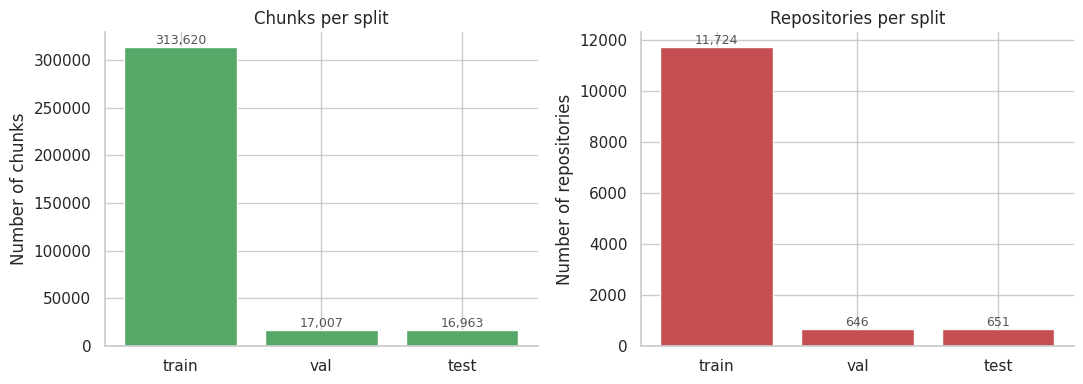

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].bar(split_summary.index, split_summary["n_chunks"], color=PALETTE[2])
axes[0].set_title("Chunks per split")
axes[0].set_ylabel("Number of chunks")
for i, v in enumerate(split_summary["n_chunks"]):
    axes[0].text(i, v, f"{v:,}", ha="center", va="bottom", fontsize=9, color=INK_SECONDARY)
style_axis(axes[0])

axes[1].bar(split_summary.index, split_summary["n_repos"], color=PALETTE[3])
axes[1].set_title("Repositories per split")
axes[1].set_ylabel("Number of repositories")
for i, v in enumerate(split_summary["n_repos"]):
    axes[1].text(i, v, f"{v:,}", ha="center", va="bottom", fontsize=9, color=INK_SECONDARY)
style_axis(axes[1])

plt.tight_layout()
plt.show()


Left: how many chunks landed in each official split after filtering. Right: how many repositories. Counts follow CodeSearchNet's published sizes (minus rows removed by the quality/token filters).

### Top repositories in train, for repo-filtered demos

Later, the Agent (Section 12) demos answers from one repository at a time — like an assistant grounded in a single project. Those demos are picked from **train** only: the model already knows those repos, there is no peeking at test data, and their code is fully indexed so search works without gaps.


,chunks
repository_name,
saltstack/salt,7608
brocade/pynos,1821
mitsei/dlkit,1792
bitesofcode/projexui,1599
materialsproject/pymatgen,1590
gem/oq-engine,1544
google/grr,1522
pypa/pipenv,1429
iotile/coretools,1407


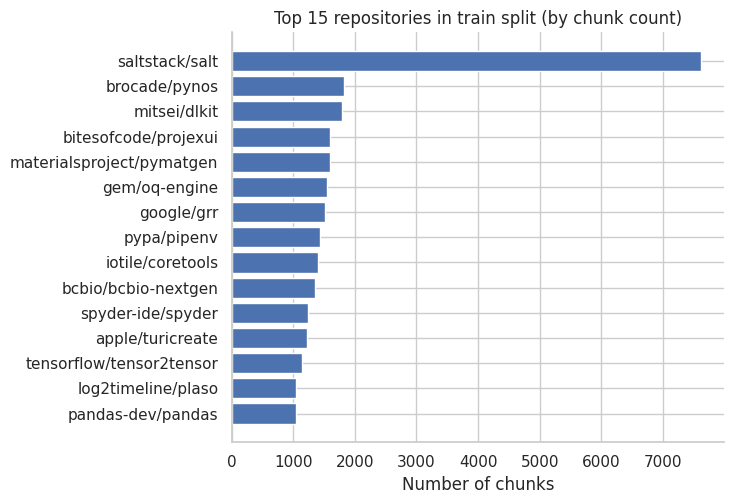

In [29]:
TOP_N_REPOS = 15
train_chunks_preview = chunks_df[chunks_df["split"] == "train"]
top_repos_final = train_chunks_preview[repo_col].value_counts().head(TOP_N_REPOS)

fig, ax = plt.subplots(figsize=(7.5, 5.2))
ax.barh(top_repos_final.index[::-1], top_repos_final.values[::-1], color=PALETTE[0])
ax.set_title(f"Top {TOP_N_REPOS} repositories in train split (by chunk count)")
ax.set_xlabel("Number of chunks")
style_axis(ax)
fig.tight_layout()

show_table_and_chart(
    top_repos_final.rename("chunks").to_frame(),
    fig,
    caption=f"Top {TOP_N_REPOS} repos (train)",
    index=True,
)


The chart above lists large repos from this run's official `train` split — useful later (Section 12) so Agent demos point at projects that already exist in the store. The same official train/val/test labels are reused everywhere next: LoRA training and eval (Sections 10–11) and the Agent's retrieval store (Section 8) all inherit them, so "train", "val", and "test" mean the same groups throughout.


In [30]:
train_df = chunks_df[chunks_df["split"] == "train"].reset_index(drop=True)
val_df = chunks_df[chunks_df["split"] == "val"].reset_index(drop=True)
test_df = chunks_df[chunks_df["split"] == "test"].reset_index(drop=True)
print(f"train_df: {len(train_df):,} rows | val_df: {len(val_df):,} rows | test_df: {len(test_df):,} rows")
print("test_df is not inspected again until Section 14.")


train_df: 313,620 rows | val_df: 17,007 rows | test_df: 16,963 rows
test_df is not inspected again until Section 14.


## 8. Embeddings and the persisted Chroma vector store:
Embedding and writing to disk (instead of rebuilding an in-memory index every run) lets the Agent (Section 12) query the same store this pipeline built. Each chunk's metadata includes `func_code_no_doc` alongside `chunk_text`, so retrieval can show readable code (with docstring) while generation gets only the docstring-stripped version — avoiding the copy shortcut again.


In [31]:
# Same train chunk, shown both ways described above
_ex = train_df.loc[train_df["func_code_no_doc"].astype(str) != train_df[code_col].astype(str)].iloc[0]

display(Markdown(
    f"### Example train chunk · two views\n\n"
    f"**Repo:** `{_ex[repo_col]}` · **chunk_id:** `{_ex['chunk_id']}`"
))

display(Markdown(
    "**1. `chunk_text` — for retrieval / display** "
    "(readable: docstring + code together)\n\n"
    f"````python\n{_ex['chunk_text']}\n````"
))

display(Markdown(
    "**2. `func_code_no_doc` — for generation** "
    "(same function, docstring stripped so the model cannot copy it)\n\n"
    f"````python\n{_ex['func_code_no_doc']}\n````"
))


### Example train chunk · two views

**Repo:** `proycon/pynlpl` · **chunk_id:** `0`

**1. `chunk_text` — for retrieval / display** (readable: docstring + code together)

````python
Appends a suffix to this element's ID, and optionally to all child IDs as well. There is sually no need to call this directly, invoked implicitly by :meth:`copy`

def addidsuffix(self, idsuffix, recursive = True):
        """Appends a suffix to this element's ID, and optionally to all child IDs as well. There is sually no need to call this directly, invoked implicitly by :meth:`copy`"""
        if self.id: self.id += idsuffix
        if recursive:
            for e in self:
                try:
                    e.addidsuffix(idsuffix, recursive)
                except Exception:
                    pass
````

**2. `func_code_no_doc` — for generation** (same function, docstring stripped so the model cannot copy it)

````python
def addidsuffix(self, idsuffix, recursive = True):
        if self.id: self.id += idsuffix
        if recursive:
            for e in self:
                try:
                    e.addidsuffix(idsuffix, recursive)
                except Exception:
                    pass
````

In [32]:
BATCH_SIZE = 64

embeddings_by_split = {}
for split_name in ["train", "val", "test"]:
    split_df = chunks_df[chunks_df["split"] == split_name]
    print(f"Encoding {len(split_df):,} chunks for split='{split_name}'...", end=" ", flush=True)
    embeddings_by_split[split_name] = embedding_model.encode(
        split_df["chunk_text"].tolist(), batch_size=BATCH_SIZE, show_progress_bar=False,
    )
    print(f"done -> {embeddings_by_split[split_name].shape}")


Encoding 313,620 chunks for split='train'... done -> (313620, 384)
Encoding 17,007 chunks for split='val'... done -> (17007, 384)
Encoding 16,963 chunks for split='test'... done -> (16963, 384)


In [33]:
import chromadb

OUTPUT_DIR = Path("codesearchnet_pipeline_output_full")
OUTPUT_DIR.mkdir(exist_ok=True)
CHROMA_DIR = OUTPUT_DIR / "chroma_store"
COLLECTION_NAME = "codesearchnet_chunks_full"

chroma_client = chromadb.PersistentClient(path=str(CHROMA_DIR))
try:
    chroma_client.delete_collection(COLLECTION_NAME)
except Exception:
    pass

collection = chroma_client.create_collection(
    name=COLLECTION_NAME, metadata={"embedding_model": EMBEDDING_MODEL_NAME, "token_budget": TOKEN_BUDGET},
)

for split_name in ["train", "val", "test"]:
    split_df = chunks_df[chunks_df["split"] == split_name].reset_index(drop=True)
    emb = embeddings_by_split[split_name]
    ids = [f"{split_name}_{cid}" for cid in split_df["chunk_id"]]
    documents = split_df["chunk_text"].tolist()
    metadatas = []
    for r in split_df.to_dict("records"):
        meta = {
            "repository_name": str(r[repo_col]),
            "split": split_name,
            "chunk_id": str(r["chunk_id"]),
            "code_no_doc": str(r["func_code_no_doc"]),
        }
        if path_col:
            meta["file_path"] = str(r[path_col])
        metadatas.append(meta)

    print(f"Adding {len(ids):,} chunks from split='{split_name}' to Chroma...", end=" ", flush=True)
    ADD_BATCH = 5000
    for start in range(0, len(ids), ADD_BATCH):
        end = start + ADD_BATCH
        collection.add(
            ids=ids[start:end], embeddings=emb[start:end].tolist(),
            metadatas=metadatas[start:end], documents=documents[start:end],
        )
    print("ok")

print(f"Total chunks in collection: {collection.count():,}")


Adding 313,620 chunks from split='train' to Chroma... ok
Adding 17,007 chunks from split='val' to Chroma... ok
Adding 16,963 chunks from split='test' to Chroma... ok
Total chunks in collection: 347,590


### Sanity-check the persisted store

Sections 12 and 14 will open this Chroma folder from disk. Before trusting it, three things have to work after the write-to-disk step — not only while the collection is still alive in memory.

1. **Retrieval** — a docstring query returns nearby code (ideally the chunk that owns that docstring)
2. **Repo filter** — `repository_name` metadata actually limits results to that repo (the Agent uses this)
3. **Reload** — a *new* client reading the same folder sees the same chunk count (so a kernel restart does not lose the index)


In [34]:
sample_query_row = chunks_df[chunks_df["split"] == "val"].sample(1, random_state=7).iloc[0]
query_text = sample_query_row[doc_col]
expected_chunk_id = f"val_{sample_query_row['chunk_id']}"
query_embedding = embedding_model.encode([query_text])[0].tolist()

# --- Check 1: retrieval ---
result = collection.query(query_embeddings=[query_embedding], n_results=5)
top_ids = result["ids"][0]
self_hit = expected_chunk_id in top_ids

# --- Check 2: repo metadata filter ---
filter_repo = top_repos_final.index[0]
filtered_result = collection.query(
    query_embeddings=[query_embedding], n_results=5, where={"repository_name": filter_repo},
)
retrieved_repos = {m["repository_name"] for m in filtered_result["metadatas"][0]}
filter_ok = retrieved_repos <= {filter_repo}

# --- Check 3: reload from disk ---
reload_client = chromadb.PersistentClient(path=str(CHROMA_DIR))
reload_collection = reload_client.get_collection(COLLECTION_NAME)
reload_count = reload_collection.count()
live_count = collection.count()
reload_ok = reload_count == live_count
assert reload_ok, "Count mismatch after reload!"

def _mark(ok: bool) -> str:
    return "PASS" if ok else "miss"


display(Markdown(
    "### 1. Retrieval\n\n"
    f"| | |\n|---|---|\n"
    f"| Query docstring | {str(query_text)[:180]}{'…' if len(str(query_text)) > 180 else ''} |\n"
    f"| Expected chunk | `{expected_chunk_id}` |\n"
    f"| Top 5 IDs | {', '.join(f'`{i}`' for i in top_ids)} |\n"
    f"| Own chunk in top 5 | **{_mark(self_hit)}** |"
))

display(Markdown(
    "### 2. Repo filter\n\n"
    f"| | |\n|---|---|\n"
    f"| Filter | `repository_name = {filter_repo}` |\n"
    f"| Repos in results | {', '.join(f'`{r}`' for r in sorted(retrieved_repos)) or '(none)'} |\n"
    f"| Filter respected | **{_mark(filter_ok)}** |"
))

display(Markdown(
    "### 3. Reload from disk\n\n"
    f"| | |\n|---|---|\n"
    f"| Live collection | **{live_count:,}** chunks |\n"
    f"| After new client | **{reload_count:,}** chunks |\n"
    f"| Counts match | **{_mark(reload_ok)}** |"
))


### 1. Retrieval

| | |
|---|---|
| Query docstring | setup res_root and aux_root, log info and run tcase-enter-hooks

    @returns 0 when all hooks succeed, some value othervise |
| Expected chunk | `val_319634` |
| Top 5 IDs | `val_319634`, `train_21475`, `val_319636`, `train_257356`, `train_14218` |
| Own chunk in top 5 | **PASS** |

### 2. Repo filter

| | |
|---|---|
| Filter | `repository_name = saltstack/salt` |
| Repos in results | `saltstack/salt` |
| Filter respected | **PASS** |

### 3. Reload from disk

| | |
|---|---|
| Live collection | **347,590** chunks |
| After new client | **347,590** chunks |
| Counts match | **PASS** |

### Reading the three checks

1. **Retrieval — PASS on this sample.** The exact val chunk (`val_319634`) came back as the top-1 result. That is the expected happy path — treat this as a spot-check that search works end-to-end, not a substitute for the formal retrieval-quality measurement in Section 14.

2. **Repo filter — PASS.** Every result came from `saltstack/salt`. The Agent can safely scope search to one repository.

3. **Reload — PASS.** A fresh client reading the same folder saw **347,590** chunks, matching the live collection. The on-disk store is what Sections 12 and 14 use; nothing needs re-embedding downstream.


## 9. Before training anything: does fine-tuning even make sense, and on what model?:
Screening 8 candidate models from scratch would mean roughly 320 generations (8 models × 2 task directions × 20 samples) plus GPT-judge calls for a question this project already answered. The numbers below are unchanged results from that original screen — reused here as the reason the rest of this notebook trains `Qwen2.5-Coder-3B-Instruct` and nothing else.

Building prompt and training code before answering two basic questions — *is the base model already good enough?* and *which candidate model and task direction is worth training?* — risks building the wrong thing. The original screen tested **8 candidate models** in both directions (`code→doc`: write a docstring for code; `doc→code`: write code for a docstring) on 20 hand-picked samples, scored three ways: ROUGE-L (word overlap with the true doc), embedding cosine similarity (catches "right content, different words"), and an LLM judge (`gpt-4o-mini`, 1–5 scale).

`func_code_string` already contains its ground-truth docstring verbatim. Asking a model to "write a docstring for this code" while the code still includes that string lets it copy instead of describe (Section 6 fixes this with `func_code_no_doc`). A LoRA run confirmed the risk: after only 50 training steps, the adapter matched the ground truth word-for-word on every held-out example checked by hand.


,rougeL_c2d,embed_sim_c2d,syntax_valid_d2c_%,gpt_judge_c2d,gpt_judge_d2c
model,,,,,
CodeGemma-2B,0.019,0.138,5.0,2.00,1.20
DeepSeek-Coder-1.3B,0.155,0.560,95.0,2.60,2.20
Llama-3.2-3B,0.229,0.526,100.0,2.90,2.75
Phi-3-mini,0.139,0.575,95.0,3.70,2.80
Phi-3.5-mini,0.137,0.561,85.0,3.95,2.90
Qwen2.5-Coder-1.5B,0.178,0.554,100.0,3.55,2.20
Qwen2.5-Coder-3B,0.200,0.546,100.0,3.35,2.65
StarCoder2-3B,0.055,0.246,10.0,1.45,1.60


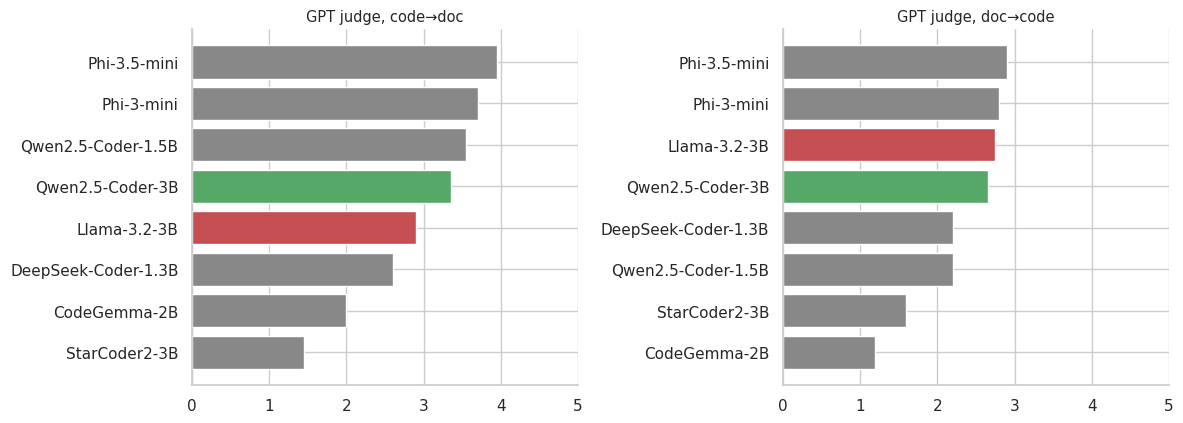

Average across all 8 models: code→doc 2.94 vs. doc→code 2.29 — code→doc is the easier, higher-quality direction for every model, matching a manual read of the outputs.


In [35]:
model_scores = pd.DataFrame({
    "model": ["CodeGemma-2B", "DeepSeek-Coder-1.3B", "Llama-3.2-3B", "Phi-3-mini", "Phi-3.5-mini",
              "Qwen2.5-Coder-1.5B", "Qwen2.5-Coder-3B", "StarCoder2-3B"],
    "rougeL_c2d": [0.019, 0.155, 0.229, 0.139, 0.137, 0.178, 0.200, 0.055],
    "embed_sim_c2d": [0.138, 0.560, 0.526, 0.575, 0.561, 0.554, 0.546, 0.246],
    "syntax_valid_d2c_%": [5.0, 95.0, 100.0, 95.0, 85.0, 100.0, 100.0, 10.0],
    "gpt_judge_c2d": [2.00, 2.60, 2.90, 3.70, 3.95, 3.55, 3.35, 1.45],
    "gpt_judge_d2c": [1.20, 2.20, 2.75, 2.80, 2.90, 2.20, 2.65, 1.60],
})
display(model_scores.set_index("model").round(3))

fig, axes = plt.subplots(1, 2, figsize=(12, 4.4))
for ax, col, title in zip(axes, ["gpt_judge_c2d", "gpt_judge_d2c"],
                            ["GPT judge, code→doc", "GPT judge, doc→code"]):
    s = model_scores.set_index("model")[col].sort_values()
    colors = [PALETTE[2] if m == "Qwen2.5-Coder-3B" else (PALETTE[3] if m == "Llama-3.2-3B" else INK_MUTED)
              for m in s.index]
    ax.barh(s.index, s.values, color=colors)
    ax.set_title(title, fontsize=10.5)
    ax.set_xlim(0, 5)
    style_axis(ax)
plt.tight_layout()
plt.show()
print(f"Average across all 8 models: code→doc {model_scores['gpt_judge_c2d'].mean():.2f} vs. "
      f"doc→code {model_scores['gpt_judge_d2c'].mean():.2f} — code→doc is the easier, "
      "higher-quality direction for every model, matching a manual read of the outputs.")


Each panel ranks all 8 candidate models by GPT-judge score (scale **1–5**, higher is better), one direction per panel. Every model scores higher on code→doc (left) than on doc→code (right) — writing prose about code is easier than writing correct code from a description.

On *this* chart alone, `Phi-3.5-mini` (3.95) and `Phi-3-mini` (3.70) lead code→doc — yet the green and red bars mark Qwen and Llama, not Phi. That is because the finalist cut was not GPT-judge alone: it was a **composite** (equal-weighted, normalized average across all 5 metrics). On that composite, `Llama-3.2-3B` and `Qwen2.5-Coder-3B` tied at 0.90 — Phi’s judge lead is offset by weaker ROUGE-L (and, for Phi-3.5, lower syntax validity on doc→code). Phi stays in the screen; the bootstrap below only compares the two composite finalists. In short, Phi wins the judge chart; Llama and Qwen win the overall scorecard.

A **paired bootstrap** (5,000 resamples, both n=20 and a widened, disjoint n=40 sample) checks whether Llama’s apparent lead over Qwen is real:

- Llama’s *only* statistically real advantage over Qwen, confirmed at both sample sizes, is **ROUGE-L**.
- Every other metric gap — semantic similarity, syntax validity, both GPT-judge directions — was **not distinguishable from noise** at either n=20 or n=40. That's means Llama’s edge over Qwen is mostly noise — only ROUGE-L holds up.

Given a composite lead that is mostly noise, practical factors decide it: Qwen is **ungated** (no HF token/license step, unlike Llama) and **code-specialized** (unlike Llama’s general-purpose training) — a simpler, more reproducible setup for giving up a lead that is real on only 1 of 5 metrics. This is the model every live section below (Sections 11, 12, 14) loads and trains: easier to run, built for code, and not clearly worse than Llama.


In [36]:
TASK_DIRECTION_DECISION = "code_to_doc"
LORA_TARGET_MODEL_LABEL = "Qwen2.5-Coder-3B"
LORA_TARGET_MODEL_ID = "Qwen/Qwen2.5-Coder-3B-Instruct"
print(f"Task direction : {TASK_DIRECTION_DECISION}")
print(f"LoRA target    : {LORA_TARGET_MODEL_LABEL}  ({LORA_TARGET_MODEL_ID})")


Task direction : code_to_doc
LoRA target    : Qwen2.5-Coder-3B  (Qwen/Qwen2.5-Coder-3B-Instruct)


## 10. LoRA training — a 16-run investigation into a paradox

Qwen was fine-tuned with LoRA on a small set (about 400 rows); many settings were tried, and the same odd result kept appearing: word-overlap with the true docstring got *better*, but a human-style judge score got *worse*. The tables and charts below are the full record of that investigation (not a live retrain of all 16 setups — that would burn many GPU-hours for the same conclusion). Section 11 retrains only the strongest candidate. The plots here are drawn from the numbers in this notebook, not pasted screenshots.

### Default training setup

Training uses only 400 rows. That is a small set, so the settings below prefer a smaller, safer adapter (harder to memorize the training set) over a bigger one that might fit the data more aggressively:

| Choice | What it means | Value | Why this value |
|---|---|---|---|
| Rank `r` | How big the LoRA adapter is — higher `r` = more trainable weights | 8 **and** 16, both trained | Both sizes are tried instead of guessing. On 400 rows, a bigger adapter can help quality but also memorize more easily. |
| `lora_alpha` | How strongly the adapter updates are scaled into the model | `2 × r` (16, 32) | Common LoRA default: scale with rank so different `r` values stay comparable. |
| `target_modules` | Which layers get LoRA adapters | attention only (`q/k/v/o_proj`) | Attention is usually enough. Adding MLP layers would roughly double the trainable params on this small dataset. |
| `lora_dropout` | Chance of dropping adapter weights during training (regularization) | 0.05 | A light regularizer — enough to curb overfitting a little, not so high that learning stalls. |
| `learning_rate` | How large each training step is | 1.5e-4 | A typical mid-range rate for LoRA at this model size — not tiny, not aggressive. |
| `num_train_epochs` | How many full passes over the training set | ≤ 2 | With only a few hundred examples, one or two passes is enough; more would invite memorization. |
| Effective batch size | How many examples the model “sees” per update (`per_device × grad_accum`) | 16 (`2 × 8`) | Fits a single GPU’s memory while still giving stable updates. |

Training pairs use **response-only loss**: the full prompt+response sequence is fed to the model, but the loss is masked to the response tokens only. This is done so the model is scored on writing the docstring, not on re-learning the prompt/code it already sees as input.

### Why this grew into 13 runs, not 2

The first comparison (`r=8` vs `r=16`) already showed the paradox: **ROUGE-L rose** vs the base model (confirmed by bootstrap), but the **GPT-judge score fell** (also confirmed). A likely reason: with only 400 rows, the adapter learns the training set’s *wording* quickly — so overlap metrics go up — while the actual content quality does not.

That is why the investigation did not stop at two runs. Eleven more runs each change **one thing** relative to a previous run, to see what fixes the judge drop (if anything):

| # | Run | What was being asked |
|---|---|---|
| 3–4 | `+1 epoch`, `+low LR` | Was training too long, or the step too hard? |
| 5 | Full fine-tune (all params, 3,000 rows, lr=2e-5) | Does unlocking the whole model help, hurt, or just cost more? |
| 6 | Detail-filtered data (docstring ≥15 words) | Are the training docs just shorter/thinner than what the base model already writes? |
| 7–8 | 3× data, unfiltered / detail-filtered | Is 400 rows simply too few — and does filtering help on top? |
| 9 | 3× data, stricter filter (≥30 words) | Does a stricter length filter keep helping? |
| 10–13 | best-checkpoint / weight-decay / higher-dropout / 1-epoch, on top of run 9 | If run 9 overfits, can quality be pulled back? |

### Did training actually learn — or just overfit?

Not every loss curve is pasted here (Section 11 plots one fresh curve for the run it retrains). Across all 13 runs the picture was the same: train loss and held-out validation loss both kept falling (so training was stable), but the **gap** between them grew — classic overfitting on 400–1,200 rows. (HuggingFace’s `Trainer` logs this metric as `eval_loss`; it is called validation loss here because it is measured on a held-out val slice — same number, two names.) Runs 10–13 tried to close that gap and recover judge score.

A different failure mode than the docstring-copy shortcut from earlier was also checked: does a generated val docstring nearly copy something from *that run’s training set*? Almost never — **4 of 910** generations looked suspicious, and a manual read showed only generic short-phrase overlap, not real memorization.

### What you will see next: all 13 runs vs the base model

Same 70 held-out `val` rows for every run; same metrics (ROUGE-L, embedding similarity, GPT judge), plus a second judge from another vendor (**Gemini**) so the evaluation is not relying on two OpenAI judges that might share the same bias. In the charts, overlap can look better while judge quality looks worse — that disagreement is the finding.


In [37]:
run_order = ["Base (no LoRA)", "LoRA r=8", "LoRA r=16", "LoRA r=8, 1 epoch", "LoRA r=8, low LR",
             "Full fine-tune (all params)", "LoRA r=8, detail-filtered data",
             "LoRA r=8, 3x data (unfiltered)", "LoRA r=8, 3x data (detail-filtered)",
             "LoRA r=8, 3x data (stricter detail filter)",
             "LoRA r=8, 3x data (strict filter) + best checkpoint",
             "LoRA r=8, 3x data (strict filter) + weight decay",
             "LoRA r=8, 3x data (strict filter) + higher dropout",
             "LoRA r=8, 3x data (strict filter) + 1 epoch"]
rougeL       = [0.222, 0.278, 0.277, 0.245, 0.240, 0.297, 0.279, 0.284, 0.300, 0.283, 0.296, 0.278, 0.288, 0.291]
embed_sim    = [0.594, 0.607, 0.599, 0.570, 0.563, 0.618, 0.612, 0.617, 0.634, 0.638, 0.630, 0.634, 0.634, 0.625]
gpt_judge    = [3.143, 2.686, 2.700, 2.429, 2.514, 2.743, 2.857, 2.643, 2.757, 2.843, 2.843, 2.814, 2.871, 2.871]
gemini_judge = [3.857, 3.400, 3.271, 2.886, 3.029, 3.314, 3.529, 3.286, 3.643, 3.643, 3.571, 3.657, 3.686, 3.571]

all_metrics = pd.DataFrame({"rougeL": rougeL, "embed_cos_sim": embed_sim,
                             "judge_score": gpt_judge, "gemini_judge_score": gemini_judge},
                            index=run_order)
display(all_metrics.round(3))


,rougeL,embed_cos_sim,judge_score,gemini_judge_score
Base (no LoRA),0.222,0.594,3.143,3.857
LoRA r=8,0.278,0.607,2.686,3.400
LoRA r=16,0.277,0.599,2.700,3.271
"LoRA r=8, 1 epoch",0.245,0.570,2.429,2.886
"LoRA r=8, low LR",0.240,0.563,2.514,3.029
Full fine-tune (all params),0.297,0.618,2.743,3.314
"LoRA r=8, detail-filtered data",0.279,0.612,2.857,3.529
"LoRA r=8, 3x data (unfiltered)",0.284,0.617,2.643,3.286
"LoRA r=8, 3x data (detail-filtered)",0.300,0.634,2.757,3.643
"LoRA r=8, 3x data (stricter detail filter)",0.283,0.638,2.843,3.643


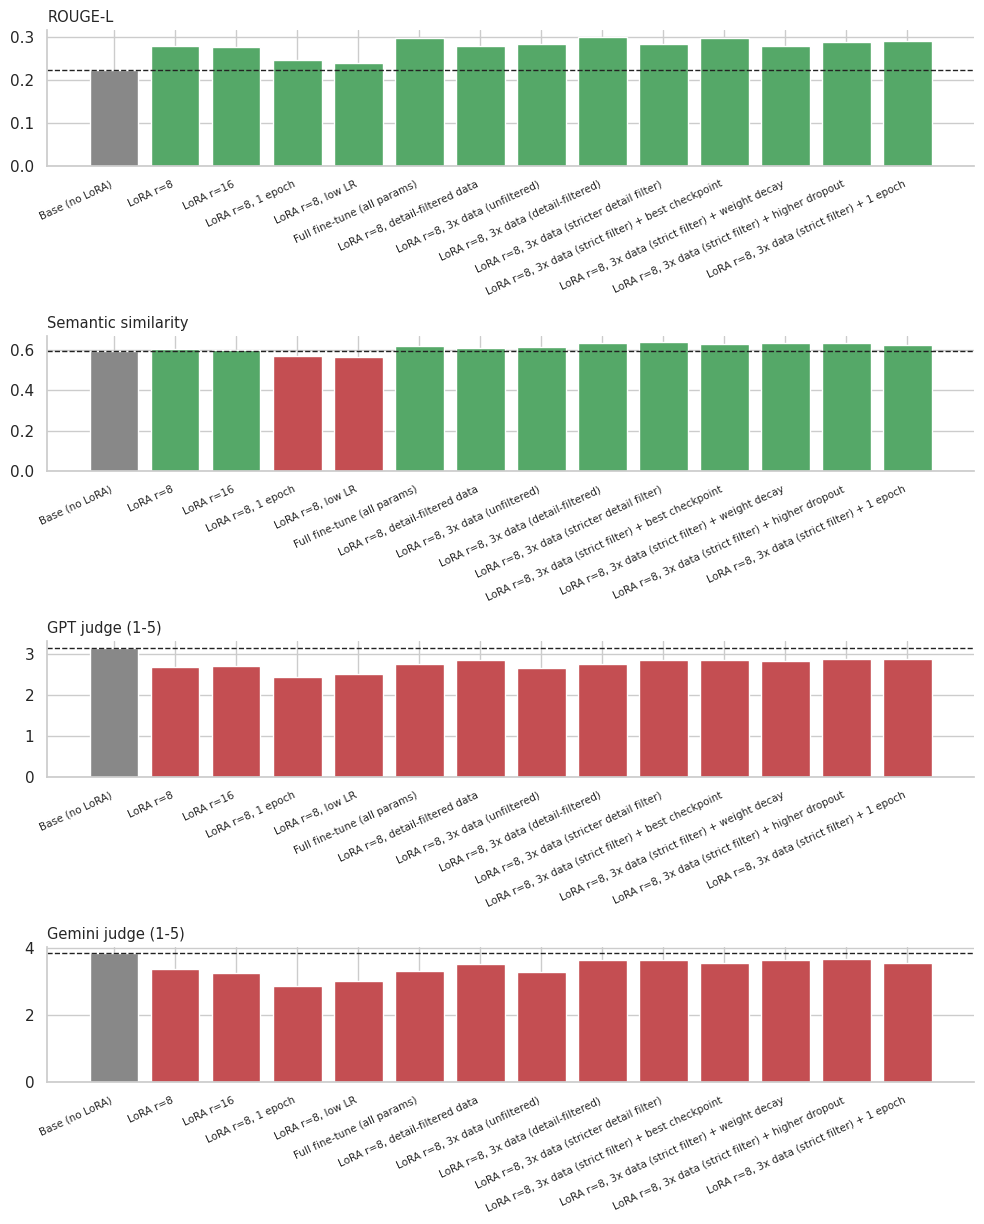

Green = at/above base on that metric; red = below base. The dashed line is the base model's own score. Every trained run beats base on ROUGE-L and (mostly) semantic similarity - but every trained run is BELOW base on both GPT judge and Gemini judge. The disagreement between metrics is the finding, not noise to average away.


In [38]:
_panels = [("rougeL", "ROUGE-L"), ("embed_cos_sim", "Semantic similarity"),
           ("judge_score", "GPT judge (1-5)"), ("gemini_judge_score", "Gemini judge (1-5)")]

fig, axes = plt.subplots(len(_panels), 1, figsize=(10, 3.1 * len(_panels)))
for ax, (col, title) in zip(axes, _panels):
    vals = all_metrics[col]
    colors = [IMPROVE_GREEN if (r != "Base (no LoRA)" and vals[r] >= vals["Base (no LoRA)"])
              else (DECLINE_RED if r != "Base (no LoRA)" else INK_MUTED) for r in vals.index]
    bars = ax.bar(vals.index, vals.values, color=colors)
    ax.set_title(title, fontsize=10.5, loc="left")
    ax.axhline(vals["Base (no LoRA)"], color=INK_PRIMARY, linewidth=1, linestyle="--")
    plt.setp(ax.get_xticklabels(), rotation=25, ha="right", fontsize=7.5)
    style_axis(ax)
plt.tight_layout()
plt.show()
print("Green = at/above base on that metric; red = below base. The dashed line is the base "
      "model's own score. Every trained run beats base on ROUGE-L and (mostly) semantic "
      "similarity - but every trained run is BELOW base on both GPT judge and Gemini judge. "
      "The disagreement between metrics is the finding, not noise to average away.")


Four stacked panels, same 14 runs (base + 13 trained variants) in each. The dashed horizontal line marks the base model's score for that metric: green means "beat base," red means "lost to base." The pattern that matters: ROUGE-L and semantic similarity are mostly green (LoRA improves match to training-set *phrasing*), while both judge columns are **entirely red** — every trained run scored worse than the untouched base model.

**Is any of this real, or could it be noise?** A 5,000-resample paired bootstrap for each run vs. base, on all 4 metrics (95% CI), found every GPT-judge and Gemini-judge decline real — no interval crossed zero. The forest-plot view of this bootstrap analysis is below, covering all 16 variants across the full investigation (this section's 13 plus the two follow-ups next), rather than duplicated twice.

In conclusion, all 13 runs show a real, bootstrap-confirmed GPT-judge decline vs. base (95% CI entirely negative, from −0.257 at best to −0.714 at worst) — none clears "real improvement with no offsetting real decline." `LoRA r=8, 3x data (detail-filtered)` leads the composite leaderboard among these 13 and is the strongest LoRA candidate overall — the one this notebook retrains live in Section 11.


## 10b. Two more follow-ups: does more data — or a different training target — close the gap?:
Two standalone follow-up notebooks in the original project pushed the two most promising remaining levers, each training exactly **one or two** new runs:

- **10× the strict-filtered data** (4,000 rows vs. the 1,200-row version that had the smallest decline of the original 13) — does scaling the winning recipe further help?
- **A rewritten-target pilot** — a code-grounded GPT-4o pass rewrote the original 400-row LoRA training set's docstrings, first validated on a 150-row sample (paired bootstrap on a code-aware quality score, plus a groundedness spot-check for hallucinated claims) before training anything. Two controlled LoRA runs then trained at the exact size and hyperparameters as the original baseline (`LoRA r=8`: 400 rows, `r=8`, 2 epochs) — one on the untouched original targets, one on the rewritten targets — so the only variable that differs between them is the training-target content itself, isolating the rewrite's own effect from everything else.


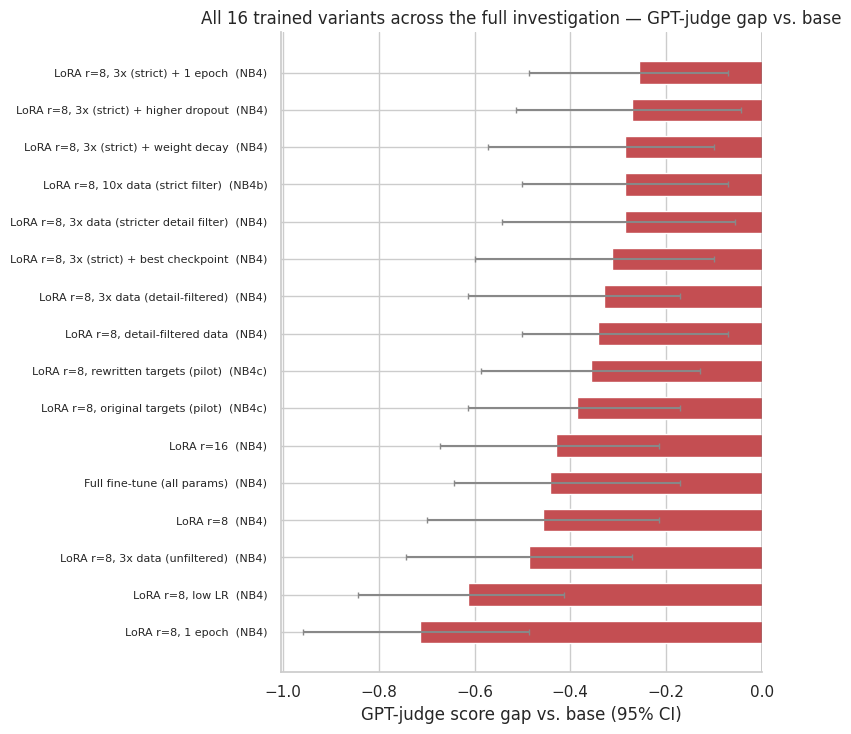

16 distinct trained variants tested across the full investigation (13-run sweep + 2 standalone follow-ups). All 16 show a real, bootstrap-confirmed GPT-judge decline vs. base (95% CI entirely below zero).


In [39]:
investigation_results = pd.DataFrame([
    ("LoRA r=8",                                     "NB4",  -0.457, (-0.700, -0.214), None,   None),
    ("LoRA r=16",                                    "NB4",  -0.429, (-0.671, -0.214), None,   None),
    ("LoRA r=8, 1 epoch",                             "NB4",  -0.714, (-0.957, -0.486), None,   None),
    ("LoRA r=8, low LR",                              "NB4",  -0.614, (-0.843, -0.414), None,   None),
    ("Full fine-tune (all params)",                   "NB4",  -0.443, (-0.643, -0.171), None,   None),
    ("LoRA r=8, detail-filtered data",                "NB4",  -0.343, (-0.500, -0.071), None,   None),
    ("LoRA r=8, 3x data (unfiltered)",                "NB4",  -0.486, (-0.743, -0.271), None,   None),
    ("LoRA r=8, 3x data (detail-filtered)",           "NB4",  -0.329, (-0.614, -0.171), None,   None),
    ("LoRA r=8, 3x data (stricter detail filter)",    "NB4",  -0.286, (-0.543, -0.057), None,   None),
    ("LoRA r=8, 3x (strict) + best checkpoint",       "NB4",  -0.314, (-0.600, -0.100), None,   None),
    ("LoRA r=8, 3x (strict) + weight decay",          "NB4",  -0.286, (-0.571, -0.100), None,   None),
    ("LoRA r=8, 3x (strict) + higher dropout",        "NB4",  -0.271, (-0.514, -0.043), None,   None),
    ("LoRA r=8, 3x (strict) + 1 epoch",               "NB4",  -0.257, (-0.486, -0.071), None,   None),
    ("LoRA r=8, 10x data (strict filter)",            "NB5",  -0.286, (-0.500, -0.071), -0.271, (-0.500, -0.057)),
    ("LoRA r=8, original targets (pilot)",            "NB4c", -0.386, (-0.614, -0.186), -0.486, (-0.743, -0.229)),
    ("LoRA r=8, rewritten targets (pilot)",           "NB4c", -0.357, (-0.543, -0.171), -0.043, (-0.271, +0.186)),
], columns=["run", "source", "gpt_gap", "gpt_ci", "gemini_gap", "gemini_ci"])

_sorted = investigation_results.sort_values("gpt_gap").reset_index(drop=True)
y = np.arange(len(_sorted))
gaps = _sorted["gpt_gap"].to_numpy()
los = np.array([ci[0] for ci in _sorted["gpt_ci"]])
his = np.array([ci[1] for ci in _sorted["gpt_ci"]])

fig, ax = plt.subplots(figsize=(8, 7.5))
ax.barh(y, gaps, xerr=[gaps - los, his - gaps], color=DECLINE_RED, ecolor=INK_MUTED, capsize=2, height=0.6)
ax.axvline(0, color=INK_PRIMARY, linewidth=1)
ax.set_yticks(y)
ax.set_yticklabels([f"{r}  ({s})" for r, s in zip(_sorted["run"], _sorted["source"])], fontsize=8)
ax.set_xlabel("GPT-judge score gap vs. base (95% CI)")
ax.set_title("All 16 trained variants across the full investigation — GPT-judge gap vs. base")
style_axis(ax)
plt.tight_layout()
plt.show()

print(f"{len(investigation_results)} distinct trained variants tested across the full "
      "investigation (13-run sweep + 2 standalone follow-up notebooks). All 16 show a real, "
      "bootstrap-confirmed GPT-judge decline vs. base (95% CI entirely below zero).")


Each bar = one trained run’s GPT-judge score minus the base model’s. Whiskers = 95% confidence interval. If the whole bar (including whiskers) is left of zero, the drop is real — not noise. All 16 bars are left of zero, so every trained variant scored worse than the untouched base on this judge.

The farther left - the bigger the drop. Closest to zero (smallest drop) is `LoRA r=8, 3x (strict) + 1 epoch` (−0.257). Still fully left of zero, so still a real decline.

A few specific cases from the chart:

- Smallest drop, but still a loss (`LoRA r=8, 3x (strict) + 1 epoch`, −0.257). In plain terms: this was the least-bad trained version here, and it still did worse than the original model.
- More data did not beat that (`LoRA r=8, 10x data (strict filter)`, −0.286 vs −0.257). In plain terms, training on much more of the same kind of data did not close the gap.
- Rewrite vs. same-size control (`LoRA r=8, rewritten targets (pilot)`, −0.357 vs `LoRA r=8, original targets (pilot)`, −0.386): both bars are fully left of zero; the rewrite is only a little closer to zero. Thus, changing the training answers (rewriting the sample “correct answers” the model practices on) did not produce a version that beats the original model on this chart.

To sum up, none of the 16 beats base on this chart, so we keep `Qwen2.5-Coder-3B-Instruct` and ship **no LoRA**. Section 11 still retrains one of these candidates (`LoRA r=8, 3x data (detail-filtered)`, −0.329 here) live, only for a later TEST comparison on unseen data. In plain terms, after trying many recipes, the original model still wins on this judge, so we ship that — and retrain one of these candidates only to compare it fairly at the end.


## 11. Retraining the strongest LoRA candidate, live:
Section 10 already found — across 16 configurations, two judges, and bootstrap checks — that no trained variant beats base. Retraining all 16 here would burn GPU time to re-confirm that. This section retrains exactly **one**: `LoRA r=8, 3x data (detail-filtered)`, the composite leader of the original 13-run sweep — with its exact hyperparameters and data-construction recipe, on this run's live `train_df` (not a cached file). The result feeds Section 14's live TEST comparison.

Recipe: `r=8`, `lora_alpha=16`, `lr=1.5e-4`, `epochs=2`, `weight_decay=0.0`, `lora_dropout=0.05`, attention-only target modules (`q_proj, k_proj, v_proj, o_proj`), trained on a **repo-capped, docstring-length-filtered 1,200-row subsample** of `train_df`.


In [40]:
from peft import LoraConfig, get_peft_model, PeftModel
from transformers import AutoModelForCausalLM, TrainingArguments, Trainer, TrainerCallback

ATTENTION_TARGET_MODULES = ["q_proj", "k_proj", "v_proj", "o_proj"]
LORA_DROPOUT = 0.05
LEARNING_RATE = 1.5e-4
NUM_TRAIN_EPOCHS = 2
PER_DEVICE_TRAIN_BATCH_SIZE = 2
GRADIENT_ACCUMULATION_STEPS = 8

NB11_OUTPUT_DIR = Path("codesearchnet_lora_train_output_full")
NB11_OUTPUT_DIR.mkdir(exist_ok=True)

# Step 3.9's finding (original project): every trained run's generated docstrings collapsed
# to a fraction of the base model's average length, and a manual audit confirmed real
# content was lost, not just words. The leading explanation: supervised fine-tuning teaches
# the model to match the TRAINING SUBSAMPLE's own docstring length/detail, and an unfiltered
# repo-capped sample of real GitHub docstrings is itself much terser than what the base
# model writes unprompted. MIN_DETAILED_DOC_WORDS filters the source pool to only rows whose
# docstring is at least this long, to test that explanation directly.
MIN_DETAILED_DOC_WORDS = 15  # ~5x the original doc-length quality filter (Section 3) - a
                             # deliberately conservative "more than a one-liner" bar

LARGE_LORA_SUBSAMPLE_SIZE = 1200
LARGE_LORA_MAX_PER_REPO = 24   # same ~2% per-repo cap ratio as the original 400-row/8-per-repo subsample
LARGE_LORA_SUBSAMPLE_SEED = 88

SUBSAMPLE_SEED = 77  # used by _build_repo_balanced_subsample's internal sampling calls below


def _build_repo_balanced_subsample(train_df_in, target_size, max_per_repo, seed, out_path, out_label):
    '''Repo-capped subsample builder: caps every repo at max_per_repo rows first, then fills
    up to target_size. Capping first (rather than a single random sample of target_size) is
    what actually bounds any one repo's share of the result; a plain random sample would let
    a handful of large repos dominate proportionally to their size in train_df, exactly what
    this is meant to avoid.'''
    capped_parts = [
        g.sample(n=min(len(g), max_per_repo), random_state=seed)
        for _, g in train_df_in.groupby(repo_col)
    ]
    capped = pd.concat(capped_parts) if capped_parts else pd.DataFrame(columns=train_df_in.columns)

    if len(capped) >= target_size:
        out_df = capped.sample(n=target_size, random_state=seed).reset_index(drop=True)
    else:
        remaining = target_size - len(capped)
        fill_pool = train_df_in.drop(index=capped.index)
        fill_rows = fill_pool.sample(n=min(remaining, len(fill_pool)), random_state=seed)
        out_df = pd.concat([capped, fill_rows]).sample(frac=1, random_state=seed).reset_index(drop=True)

    out_df.to_parquet(out_path, index=False)
    print(f"Saved {len(out_df)} rows ({out_label}) -> {out_path}")
    return out_df


detailed_pool = train_df[train_df[doc_col].astype(str).str.split().str.len() >= MIN_DETAILED_DOC_WORDS].copy()
print(f"Detail filter: {len(detailed_pool):,} / {len(train_df):,} train_df rows have a docstring "
      f"of at least {MIN_DETAILED_DOC_WORDS} words.")

lora_train_df = _build_repo_balanced_subsample(
    detailed_pool, LARGE_LORA_SUBSAMPLE_SIZE, LARGE_LORA_MAX_PER_REPO, LARGE_LORA_SUBSAMPLE_SEED,
    NB11_OUTPUT_DIR / "lora_train_subsample_detailed_large.parquet",
    "3x-data LoRA subsample (detail-filtered) — the live retrain's actual training data",
)
if len(lora_train_df) < LARGE_LORA_SUBSAMPLE_SIZE:
    print(f"WARNING: only {len(lora_train_df)}/{LARGE_LORA_SUBSAMPLE_SIZE} rows available after "
          "the detail filter and repo cap on this run's own train_df.")

_concentration = lora_train_df[repo_col].value_counts(normalize=True) * 100
print(f"Repo concentration in the training subsample: largest single repo = "
      f"{_concentration.iloc[0]:.1f}% of rows, top-5 repos = {_concentration.head(5).sum():.1f}%.")


Detail filter: 173,536 / 313,620 train_df rows have a docstring of at least 15 words.
Saved 1200 rows (3x-data LoRA subsample (detail-filtered) — the live retrain's actual training data) -> codesearchnet_lora_train_output_full/lora_train_subsample_detailed_large.parquet
Repo concentration in the training subsample: largest single repo = 0.3% of rows, top-5 repos = 1.2%.


The cell above builds the live LoRA training set in three steps: it sets the LoRA knobs (learning rate, epochs, and which attention layers to train), drops docstrings shorter than 15 words so the model is not taught to write one-liners, and then caps each repository at 24 rows while filling up to 1,200 examples so one huge repo cannot flood the sample. That way training avoids two common traps — learning from an unbalanced pile of one project, and learning to answer too briefly.


### Building supervised training pairs

As in Sections 6 and 9: `func_code_string` already contains its ground-truth docstring verbatim. Every input below uses `func_code_no_doc` (computed in Section 6).


In [41]:
CODE_TO_DOC_PROMPT = (
    "Write a concise, accurate docstring for the following Python function. "
    "Only output the docstring text - no code fences, no repetition of the function signature.\n\n"
    "```python\n{code}\n```"
)


def build_chat_messages(code_no_doc, true_doc=None):
    '''Builds the chat message list for one example. `true_doc=None` gives the user-turn
    only (for generation at eval time); a real string appends the assistant turn (for
    supervised training).'''
    messages = [{"role": "user", "content": CODE_TO_DOC_PROMPT.format(code=code_no_doc)}]
    if true_doc is not None:
        messages.append({"role": "assistant", "content": str(true_doc).strip()})
    return messages


### Tokenize into (input_ids, labels) pairs, response-only loss

During training the model gets a full sequence: the code (prompt) followed by the docstring. Without masking, it would be scored on predicting *every* token — including the code it was already given — so it could "succeed" by simply repeating what it saw. Instead, the prompt is tokenized alone to measure its length, and every label in that prefix is set to `-100` (ignored by the loss). The model still sees the code as context, but the loss is computed only on the docstring tokens — so it learns to write the description, not to reconstruct the prompt.


In [42]:
from transformers import AutoTokenizer as _AutoTokenizer

print(f"Loading tokenizer for {LORA_TARGET_MODEL_LABEL}...")
tokenizer = _AutoTokenizer.from_pretrained(LORA_TARGET_MODEL_ID)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

MAX_SEQ_LEN = 768  # generous vs. the 512-token chunk budget (Section 4)


def normalize_token_ids(x):
    '''`tokenizer.apply_chat_template(tokenize=True, ...)` does not return a consistent
    shape across transformers/tokenizers versions - it can hand back a flat list[int], a
    BatchEncoding (dict-like), a raw tokenizers.Encoding object, or a batched list[list[int]]
    for what is really a single conversation. This normalizes every shape down to a single
    flat list[int] up front.'''
    if hasattr(x, "keys") and "input_ids" in x:
        x = x["input_ids"]
    if hasattr(x, "ids") and not isinstance(x, (list, tuple)):
        return list(x.ids)
    if isinstance(x, list) and len(x) > 0 and isinstance(x[0], (list, tuple)):
        x = x[0]
    return list(x)


def encode_supervised_example(code_no_doc, true_doc, max_len=MAX_SEQ_LEN):
    prompt_ids = normalize_token_ids(tokenizer.apply_chat_template(
        build_chat_messages(code_no_doc), add_generation_prompt=True, tokenize=True,
    ))
    full_ids = normalize_token_ids(tokenizer.apply_chat_template(
        build_chat_messages(code_no_doc, true_doc), add_generation_prompt=False, tokenize=True,
    ))
    if len(full_ids) < len(prompt_ids):
        return None

    full_ids = full_ids[:max_len]
    labels = list(full_ids)
    prompt_len = min(len(prompt_ids), len(full_ids))
    for i in range(prompt_len):
        labels[i] = -100
    return {"input_ids": full_ids, "labels": labels}


Loading tokenizer for Qwen2.5-Coder-3B...


In [43]:
class SupervisedDocGenDataset(torch.utils.data.Dataset):
    '''Wraps a DataFrame of (func_code_no_doc, true_doc) pairs as tokenized, response-masked
    training examples. Rows that fail to encode (rare) are dropped, not silently
    zero-padded into the batch.'''

    def __init__(self, df_in, code_col_no_doc="func_code_no_doc", doc_col_name=doc_col):
        self.examples = []
        n_dropped = 0
        for _, row in df_in.iterrows():
            ex = encode_supervised_example(row[code_col_no_doc], row[doc_col_name])
            if ex is None:
                n_dropped += 1
                continue
            self.examples.append(ex)
        if n_dropped:
            print(f"  Dropped {n_dropped} row(s) that failed to encode.")

    def __len__(self):
        return len(self.examples)

    def __getitem__(self, idx):
        return self.examples[idx]


def collate_supervised(batch):
    '''Right-pads input_ids/labels to the batch's longest sequence. Padded label positions
    get -100 (ignored by the loss), padded input_ids get the pad token with a matching 0 in
    attention_mask.'''
    max_len = max(len(ex["input_ids"]) for ex in batch)
    input_ids, attention_mask, labels = [], [], []
    for ex in batch:
        pad_n = max_len - len(ex["input_ids"])
        input_ids.append(ex["input_ids"] + [tokenizer.pad_token_id] * pad_n)
        attention_mask.append([1] * len(ex["input_ids"]) + [0] * pad_n)
        labels.append(ex["labels"] + [-100] * pad_n)
    return {
        "input_ids": torch.tensor(input_ids, dtype=torch.long),
        "attention_mask": torch.tensor(attention_mask, dtype=torch.long),
        "labels": torch.tensor(labels, dtype=torch.long),
    }


### Sanity check — one training example

| | Tokens | Share |
|---|---:|---:|
| Prompt (masked, loss ignored) | 138 | 69% |
| Response (scored) | 63 | 31% |
| **Full sequence** | **201** | **100%** |

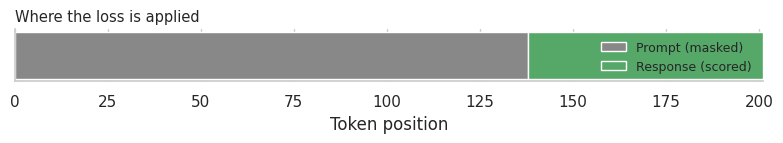

Decoded sequence (prompt + response), first 600 characters:

````text
<|im_start|>system
You are Qwen, created by Alibaba Cloud. You are a helpful assistant.<|im_end|>
<|im_start|>user
Write a concise, accurate docstring for the following Python function. Only output the docstring text - no code fences, no repetition of the function signature.

```python
def hashtag_links(uri, s):
    for tag, after in hashtag_re.findall(s):
        _uri = '/' + (uri or "").lstrip("/") + quote(tag)
        link = '<a href="{}">#{}</a>{}'.format(_uri.lower(), tag, after)
        s = s.replace('#' + tag, link)
    return s
```<|im_end|>
<|im_start|>assistant
Turns hashtag-like str…
````

In [44]:
_sanity_ds = SupervisedDocGenDataset(lora_train_df.head(1))
_sanity_ex = _sanity_ds[0]
_decoded_full = tokenizer.decode(_sanity_ex["input_ids"])
_n_masked = sum(1 for l in _sanity_ex["labels"] if l == -100)
_n_total = len(_sanity_ex["labels"])
_n_scored = _n_total - _n_masked

display(Markdown(
    "### Sanity check — one training example\n\n"
    f"| | Tokens | Share |\n|---|---:|---:|\n"
    f"| Prompt (masked, loss ignored) | {_n_masked} | {_n_masked / _n_total:.0%} |\n"
    f"| Response (scored) | {_n_scored} | {_n_scored / _n_total:.0%} |\n"
    f"| **Full sequence** | **{_n_total}** | **100%** |"
))

fig, ax = plt.subplots(figsize=(8, 1.6))
ax.barh([0], [_n_masked], color=INK_MUTED, height=0.45, label="Prompt (masked)")
ax.barh([0], [_n_scored], left=[_n_masked], color=PALETTE[2], height=0.45, label="Response (scored)")
ax.set_xlim(0, _n_total)
ax.set_yticks([])
ax.set_xlabel("Token position")
ax.set_title("Where the loss is applied", fontsize=10.5, loc="left")
ax.legend(loc="upper right", frameon=False, fontsize=9)
style_axis(ax)
plt.tight_layout()
plt.show()

_preview = _decoded_full[:600] + ("…" if len(_decoded_full) > 600 else "")
display(Markdown(
    "Decoded sequence (prompt + response), first 600 characters:\n\n"
    f"````text\n{_preview}\n````"
))


The bar chart above is a quick sanity check on one training example: the gray segment is the prompt (code + chat template) — about two-thirds of the tokens — and the colored segment is the docstring response. Only the colored part contributes to the loss (`-100` on the rest). That split is expected: the prompt is longer than the docstring, and it confirms the masking works. The decoded preview below the chart should show the instruction and function first, then the assistant’s docstring — if the scored region were still full of code, the encoding would be wrong.

The decoded text shows the same example as a chat: a short system line, then a user message with the “write a docstring” instruction and the Python function (no docstring inside the code), then `<|im_start|>assistant` followed by the start of the true docstring (`Turns hashtag-like str…`). That order is what we want — prompt first, gold response after the assistant tag — so the model learns to continue from that point, not to invent a new format.



### Training setup

One reusable function trains the adapter end-to-end: load the base model, wrap it with LoRA, train, capture the loss history for plotting, save the adapter to disk, then free the GPU.


In [45]:
class LossHistoryCallback(TrainerCallback):
    '''Collects (step, loss, grad_norm) / (step, validation loss as eval_loss, eval_token_accuracy) pairs from
    Trainer's log stream, so the diagnostic chart below is built from the actual training
    run rather than re-parsing Trainer's console output.'''

    def __init__(self):
        self.train_log = []
        self.eval_log = []

    def on_log(self, args, state, control, logs=None, **kwargs):
        if logs is None:
            return
        if "loss" in logs:
            self.train_log.append({"step": state.global_step, "loss": logs["loss"], "grad_norm": logs.get("grad_norm")})
        if "eval_loss" in logs:
            self.eval_log.append({"step": state.global_step, "eval_loss": logs["eval_loss"],
                                   "eval_token_accuracy": logs.get("eval_token_accuracy")})


def preprocess_logits_for_metrics(logits, labels):
    '''Reduces each eval batch's (batch, seq_len, vocab) float logits down to (batch,
    seq_len) argmax token ids immediately after the forward pass, before Trainer
    accumulates predictions across the whole eval split - otherwise keeping full-vocabulary
    logits in memory for a large-vocabulary causal LM risks exhausting GPU memory.'''
    if isinstance(logits, tuple):
        logits = logits[0]
    return logits.argmax(dim=-1)


def compute_metrics(eval_pred):
    '''Next-token accuracy on response tokens only (prompt tokens are labeled -100 and
    excluded here too), using the same causal shift the loss itself uses internally.'''
    predictions, labels = eval_pred
    if isinstance(predictions, tuple):
        predictions = predictions[0]
    predictions = np.asarray(predictions)
    labels = np.asarray(labels)
    pred_shifted = predictions[:, :-1]
    label_shifted = labels[:, 1:]
    mask = label_shifted != -100
    if mask.sum() == 0:
        return {"token_accuracy": float("nan")}
    correct = (pred_shifted == label_shifted) & mask
    return {"token_accuracy": float(correct.sum()) / float(mask.sum())}


def train_lora_variant(variant, train_dataset, eval_dataset, output_dir):
    '''variant may additionally set "weight_decay" (default 0.0), "lora_dropout" (default
    LORA_DROPOUT), and "use_best_checkpoint" (default False).'''
    label, r, alpha = variant["label"], variant["r"], variant["lora_alpha"]
    lr = variant.get("learning_rate", LEARNING_RATE)
    epochs = variant.get("num_train_epochs", NUM_TRAIN_EPOCHS)
    weight_decay = variant.get("weight_decay", 0.0)
    lora_dropout = variant.get("lora_dropout", LORA_DROPOUT)
    use_best_checkpoint = variant.get("use_best_checkpoint", False)
    print(f"\n{'='*70}\nTraining {label} (lora_alpha={alpha}, lr={lr}, epochs={epochs}, "
          f"weight_decay={weight_decay}, lora_dropout={lora_dropout}, "
          f"use_best_checkpoint={use_best_checkpoint})\n{'='*70}")

    base_model = AutoModelForCausalLM.from_pretrained(
        LORA_TARGET_MODEL_ID, dtype=torch.bfloat16 if device == "cuda" else torch.float32, device_map=device,
    )
    lora_config = LoraConfig(
        r=r, lora_alpha=alpha, target_modules=ATTENTION_TARGET_MODULES,
        lora_dropout=lora_dropout, bias="none", task_type="CAUSAL_LM",
    )
    peft_model = get_peft_model(base_model, lora_config)
    _trainable = sum(p.numel() for p in peft_model.parameters() if p.requires_grad)
    _total = sum(p.numel() for p in peft_model.parameters())
    print(f"Trainable params: {_trainable:,} / {_total:,} ({100*_trainable/_total:.2f}%)")

    _ckpt_kwargs = (
        dict(save_strategy="steps", save_steps=10, save_total_limit=1,
             load_best_model_at_end=True, metric_for_best_model="eval_loss", greater_is_better=False)
        if use_best_checkpoint else
        dict(save_strategy="no")
    )
    training_args = TrainingArguments(
        output_dir=str(output_dir / "trainer_ckpts"),
        per_device_train_batch_size=PER_DEVICE_TRAIN_BATCH_SIZE,
        gradient_accumulation_steps=GRADIENT_ACCUMULATION_STEPS,
        num_train_epochs=epochs,
        learning_rate=lr,
        weight_decay=weight_decay,
        logging_steps=2,
        eval_strategy="steps",
        eval_steps=10,
        eval_accumulation_steps=4,
        bf16=(device == "cuda"),
        report_to=[],
        disable_tqdm=True,
        remove_unused_columns=False,
        **_ckpt_kwargs,
    )

    loss_cb = LossHistoryCallback()
    trainer = Trainer(
        model=peft_model, args=training_args, train_dataset=train_dataset, eval_dataset=eval_dataset,
        data_collator=collate_supervised, callbacks=[loss_cb],
        compute_metrics=compute_metrics, preprocess_logits_for_metrics=preprocess_logits_for_metrics,
    )
    trainer.train()
    if use_best_checkpoint and trainer.state.best_model_checkpoint:
        print(f"Best checkpoint by validation loss: {trainer.state.best_model_checkpoint} "
              f"(validation loss={trainer.state.best_metric:.4f}) - reloaded into the model saved below.")

    adapter_path = output_dir / label.replace(" ", "_").replace("=", "")
    peft_model.save_pretrained(str(adapter_path))
    print(f"Saved adapter -> {adapter_path}")

    train_history = pd.DataFrame(loss_cb.train_log)
    eval_history = pd.DataFrame(loss_cb.eval_log)

    del trainer, peft_model, base_model
    gc.collect()
    if device == "cuda":
        torch.cuda.empty_cache()

    return {"label": label, "kind": "lora", "adapter_path": str(adapter_path),
            "train_history": train_history, "eval_history": eval_history}


In [46]:
LOSS_CURVE_EVAL_SIZE = 40
LOSS_CURVE_EVAL_SEED = 501
loss_curve_eval_df = val_df.sample(n=min(LOSS_CURVE_EVAL_SIZE, len(val_df)), random_state=LOSS_CURVE_EVAL_SEED)
print(f"Loss-curve eval slice: {len(loss_curve_eval_df)} rows from val_df (seed={LOSS_CURVE_EVAL_SEED})")

BEST_LORA_VARIANT = {"label": "LoRA r=8, 3x data (detail-filtered)", "r": 8, "lora_alpha": 16}

train_dataset = SupervisedDocGenDataset(lora_train_df)
loss_curve_eval_dataset = SupervisedDocGenDataset(loss_curve_eval_df)
print(f"LoRA training examples: {len(train_dataset)}  |  Loss-curve eval examples: {len(loss_curve_eval_dataset)}")

lora_result = train_lora_variant(BEST_LORA_VARIANT, train_dataset, loss_curve_eval_dataset, NB11_OUTPUT_DIR)
ADAPTER_PATH = lora_result["adapter_path"]
print(f"\nDone. Adapter saved at: {ADAPTER_PATH}")


Loss-curve eval slice: 40 rows from val_df (seed=501)
LoRA training examples: 1200  |  Loss-curve eval examples: 40

Training LoRA r=8, 3x data (detail-filtered) (lora_alpha=16, lr=0.00015, epochs=2, weight_decay=0.0, lora_dropout=0.05, use_best_checkpoint=False)
Trainable params: 3,686,400 / 3,089,625,088 (0.12%)
{'loss': '2.126', 'grad_norm': '0.6505', 'learning_rate': '0.000149', 'epoch': '0.02667'}
{'loss': '1.938', 'grad_norm': '0.5649', 'learning_rate': '0.000147', 'epoch': '0.05333'}
{'loss': '2.024', 'grad_norm': '0.6513', 'learning_rate': '0.000145', 'epoch': '0.08'}
{'loss': '1.975', 'grad_norm': '0.5503', 'learning_rate': '0.000143', 'epoch': '0.1067'}
{'loss': '1.924', 'grad_norm': '0.4155', 'learning_rate': '0.000141', 'epoch': '0.1333'}
{'eval_loss': '1.87', 'eval_token_accuracy': '0.5831', 'eval_runtime': '0.6693', 'eval_samples_per_second': '59.76', 'eval_steps_per_second': '7.47', 'epoch': '0.1333'}
{'loss': '1.836', 'grad_norm': '0.407', 'learning_rate': '0.000139', '

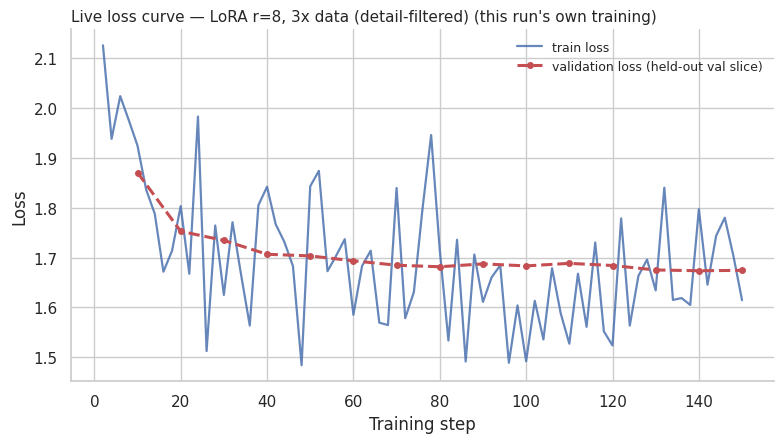

Generalization gap (validation loss − train loss): -0.255 -> 0.060 (widening (overfitting signal))


In [47]:
th, eh = lora_result["train_history"], lora_result["eval_history"]

fig, ax = plt.subplots(figsize=(8, 4.6))
if len(th):
    ax.plot(th["step"], th["loss"], color=PALETTE[0], linewidth=1.6, label="train loss", alpha=0.85)
if len(eh):
    ax.plot(eh["step"], eh["eval_loss"], color=PALETTE[3], linewidth=2.2, linestyle="--",
            marker="o", markersize=4, label="validation loss (held-out val slice)")
ax.set_title(f"Live loss curve — {BEST_LORA_VARIANT['label']} (this run's own training)", loc="left", fontsize=11)
ax.set_xlabel("Training step")
ax.set_ylabel("Loss")
ax.legend(frameon=False, fontsize=9)
style_axis(ax)
plt.tight_layout()
plt.show()

if len(th) and len(eh):
    gap_start = eh["eval_loss"].iloc[0] - th["loss"].iloc[0]
    gap_end = eh["eval_loss"].iloc[-1] - th["loss"].iloc[-1]
    trend = "widening (overfitting signal)" if gap_end > gap_start else "flat/shrinking (healthy)"
    print(f"Generalization gap (validation loss − train loss): {gap_start:.3f} -> {gap_end:.3f} ({trend})")


This chart is from **this** run’s adapter — not a screenshot from an older experiment. Blue is train loss (noisy, but trending down from ~2.1 toward ~1.6); the dashed line is held-out validation loss, which falls early and then flattens around ~1.67–1.68 after mid-training instead of keeping pace with train. The printed generalization gap matches that picture: it moves from **-0.255 → 0.060** and is flagged as widening — train keeps edging lower under a mostly flat validation curve, the same small-data overfitting signal Section 10 saw across the historical runs on 1,200 rows.

Due to the results, the adapter at `ADAPTER_PATH` is still used later for generation in Section 14’s live TEST comparison. The Agent in Section 12 runs the **base** model on purpose: Sections 10–11 showed no LoRA variant beat base.


## 12. Agent: retrieval → tool → generation → citation

This section builds a small agent — not a big multi-step planner. The loop is short on purpose: retrieve relevant code, optionally narrow it with a keyword tool, generate an explanation, and return a citation. Depth stays on the RAG + LoRA work above; here the pieces are only wired together.

Retrieval uses the Chroma store from Section 8. Generation reuses the prompt and model setup from Section 11. And following Sections 10–11, only the **base** model is loaded — no LoRA adapter — because no trained variant beat base.


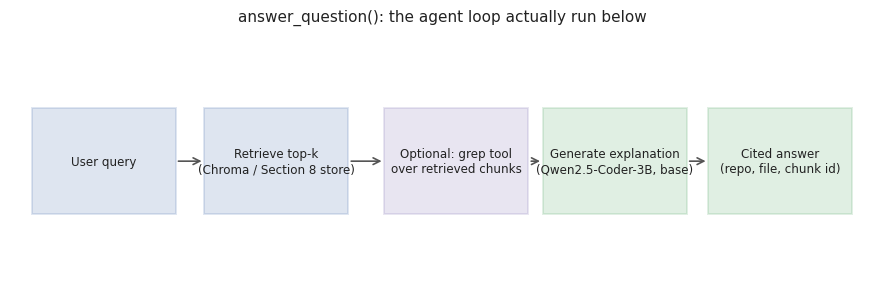

In [48]:
fig, ax = plt.subplots(figsize=(9, 3.2))
ax.axis("off")
boxes = [
    ("User query", 0.03, PALETTE[0]),
    ("Retrieve top-k\n(Chroma / Section 8 store)", 0.27, PALETTE[0]),
    ("Optional: grep tool\nover retrieved chunks", 0.52, PALETTE[4]),
    ("Generate explanation\n(Qwen2.5-Coder-3B, base)", 0.74, PALETTE[2]),
    ("Cited answer\n(repo, file, chunk id)", 0.97, PALETTE[2]),
]
box_w = 0.20
for label, x, color in boxes:
    ax.add_patch(plt.Rectangle((x, 0.3), box_w, 0.4, facecolor=color, alpha=0.18, edgecolor=color, linewidth=1.4))
    ax.text(x + box_w/2, 0.5, label, ha="center", va="center", fontsize=8.6, color=INK_PRIMARY)
for (_, x0, _), (_, x1, _) in zip(boxes[:-1], boxes[1:]):
    ax.annotate("", xy=(x1, 0.5), xytext=(x0 + box_w, 0.5),
                arrowprops=dict(arrowstyle="->", color=INK_SECONDARY, lw=1.2))
ax.set_xlim(0, 1.2)
ax.set_ylim(0, 1)
ax.set_title("answer_question(): the agent loop actually run below", fontsize=11, color=INK_PRIMARY)
plt.tight_layout()
plt.show()


Five steps: a query comes in, retrieval pulls candidates from the store, an optional keyword tool narrows them, the base model generates an explanation of the chosen candidate's code, and the answer returns with a source citation (repository, file, chunk id). Each box below is a real function call, not a mock.

Why this order: real code is found *before* the model is asked to talk. That keeps the answer grounded in the corpus instead of inventing an API from memory. The optional keyword step is only for when the top hits are close but messy — a quick filter, not a second brain. Generation then explains the chosen snippet, and the citation lets you open the same file and check. So the loop is retrieve → (maybe) refine → explain → point at the source.

In [49]:
print("Loading the base model (no adapter) for the Agent's generator...")
gen_model = AutoModelForCausalLM.from_pretrained(
    LORA_TARGET_MODEL_ID, dtype=torch.bfloat16 if device == "cuda" else torch.float32, device_map=device,
)
gen_model.eval()

AGENT_MAX_NEW_TOKENS = 200


def generate_response(tok, model, messages, max_new_tokens=AGENT_MAX_NEW_TOKENS):
    '''Deterministic single-turn generation. Handles a transformers-version quirk where
    apply_chat_template(..., return_tensors="pt") can come back as a BatchEncoding instead
    of a plain tensor.'''
    processed = tok.apply_chat_template(messages, add_generation_prompt=True, return_tensors="pt")
    input_ids = processed["input_ids"] if hasattr(processed, "keys") else processed
    input_ids = input_ids.to(model.device)
    with torch.no_grad():
        output_ids = model.generate(
            input_ids=input_ids, max_new_tokens=max_new_tokens, do_sample=False,
            pad_token_id=tok.eos_token_id if tok.eos_token_id is not None else tok.pad_token_id,
        )
    new_tokens = output_ids[0][input_ids.shape[1]:]
    truncated = len(new_tokens) >= max_new_tokens
    return tok.decode(new_tokens, skip_special_tokens=True).strip(), truncated


print("Generation model: Qwen2.5-Coder-3B-Instruct (base, no adapter)")


Loading the base model (no adapter) for the Agent's generator...
Generation model: Qwen2.5-Coder-3B-Instruct (base, no adapter)


### Retrieval tool — repo-filtered RAG search over the Section 8 store

This is the agent’s search step. `retrieve()` embeds the user query and asks the Chroma store from Section 8 for the nearest code chunks — optionally limited to one repository and to the `val` split (`test` is kept untouched until Section 14). `grep_candidates()` is a small follow-up: keyword search only inside those retrieved chunks, not over the whole corpus. Together they are the “find relevant code” half of the loop before generation runs.


In [50]:
def retrieve(query, repo_name=None, k=5, split="val"):
    '''Embed `query` and search the persisted Chroma collection, optionally restricted to
    one repository via metadata filtering. Defaults to `split="val"`: test is kept unread
    until Section 14's final, deliberate evaluation.'''
    query_embedding = embedding_model.encode([query])[0].tolist()
    kwargs = dict(query_embeddings=[query_embedding], n_results=k)

    conditions = []
    if repo_name is not None:
        conditions.append({"repository_name": repo_name})
    if split is not None:
        conditions.append({"split": split})
    if len(conditions) == 1:
        kwargs["where"] = conditions[0]
    elif len(conditions) > 1:
        kwargs["where"] = {"$and": conditions}

    result = collection.query(**kwargs)

    candidates = []
    for doc_text, meta, dist in zip(result["documents"][0], result["metadatas"][0], result["distances"][0]):
        doc_part, _, code_part = doc_text.partition("\n\n")
        candidates.append({
            "repository_name": meta.get("repository_name"), "file_path": meta.get("file_path"),
            "chunk_id": meta.get("chunk_id"), "split": meta.get("split"), "distance": dist,
            "docstring": doc_part, "code": code_part, "code_no_doc": meta.get("code_no_doc"),
            "chunk_text": doc_text,
        })
    return candidates


def grep_candidates(pattern, candidates, flags=re.IGNORECASE):
    '''Search `code` (and `docstring`) of each candidate for `pattern`; returns, per
    candidate, the matching lines with 1-based line numbers - a minimal stand-in for a real
    grep tool, scoped to only the candidates retrieve() already pulled back.'''
    compiled = re.compile(pattern, flags)
    hits = []
    for idx, cand in enumerate(candidates):
        matches = []
        for field in ("docstring", "code"):
            for lineno, line in enumerate(cand[field].splitlines(), start=1):
                if compiled.search(line):
                    matches.append({"field": field, "line": lineno, "text": line.strip()})
        if matches:
            hits.append({"candidate_index": idx, "repository_name": cand["repository_name"],
                         "file_path": cand["file_path"], "matches": matches})
    return hits


### Quantitative retrieval check — Hit@k / MRR on this exact store (val split)

Measures Hit@k against the persisted Chroma store that `retrieve()` queries — not a separate proxy corpus.
The check asks whether a docstring finds its own code chunk back in the Agent’s real store. If Hit@k and MRR are high, retrieval itself is solid before grep, confidence gating, or generation are layered on.

In [51]:
def evaluate_retrieval_hitk(n_queries=150, ks=(1, 5, 10), seed=42, split="val"):
    '''Doc->code retrieval Hit@k/MRR computed directly against the persisted Chroma store
    retrieve() queries. Same task as Section 5 (embed the docstring, check whether the
    paired code chunk is retrieved back), restricted to `split`.'''
    pool = collection.get(where={"split": split}, limit=5000, include=["metadatas", "documents"])
    ids, docs = pool["ids"], pool["documents"]
    n = len(ids)
    if n == 0:
        raise ValueError(f"No chunks found for split={split!r} in the collection.")

    rng = np.random.default_rng(seed)
    query_positions = rng.choice(n, size=min(n_queries, n), replace=False)
    max_k = max(ks)

    hits_at_k = {k: 0 for k in ks}
    reciprocal_ranks = []
    for pos in query_positions:
        doc_part, _, _ = docs[pos].partition("\n\n")
        query_embedding = embedding_model.encode([doc_part])[0].tolist()
        result = collection.query(query_embeddings=[query_embedding], n_results=max_k, where={"split": split})
        retrieved_ids = result["ids"][0]
        rank = retrieved_ids.index(ids[pos]) + 1 if ids[pos] in retrieved_ids else None
        for k in ks:
            if rank is not None and rank <= k:
                hits_at_k[k] += 1
        reciprocal_ranks.append(1 / rank if rank else 0.0)

    n_eval = len(query_positions)
    eval_results = {f"Hit@{k}": hits_at_k[k] / n_eval for k in ks}
    eval_results["MRR"] = float(np.mean(reciprocal_ranks))
    return eval_results, n_eval


RETRIEVAL_EVAL_N = 150
hitk_results, hitk_n = evaluate_retrieval_hitk(n_queries=RETRIEVAL_EVAL_N, seed=42, split="val")


### Doc→code retrieval on the Agent's store

Val split · **n = 150** queries

| Metric | Score |
|---|---:|
| Hit@1 | 0.820 |
| Hit@5 | 0.947 |
| Hit@10 | 0.947 |
| MRR | 0.878 |

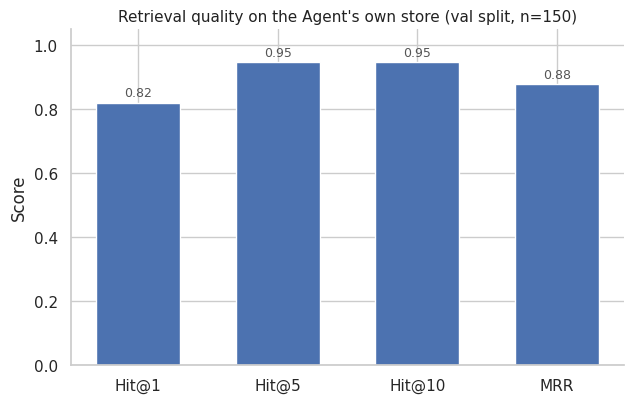

In [52]:
# One visual summary of the same Hit@k / MRR numbers (no separate text dump).
_rows = "\n".join(f"| {m} | {hitk_results[m]:.3f} |" for m in hitk_results)
display(Markdown(
    f"### Doc→code retrieval on the Agent's store\n\n"
    f"Val split · **n = {hitk_n}** queries\n\n"
    f"| Metric | Score |\n|---|---:|\n{_rows}"
))

fig, ax = plt.subplots(figsize=(6.5, 4.2))
metric_names = list(hitk_results.keys())
metric_values = [hitk_results[m] for m in metric_names]
bars = ax.bar(metric_names, metric_values, color=PALETTE[0], width=0.6)
for bar, val in zip(bars, metric_values):
    ax.text(bar.get_x() + bar.get_width() / 2, val + 0.02, f"{val:.2f}",
            ha="center", fontsize=9, color=INK_SECONDARY)
ax.set_ylim(0, 1.05)
ax.set_ylabel("Score")
ax.set_title(f"Retrieval quality on the Agent's own store (val split, n={hitk_n})",
             fontsize=11, color=INK_PRIMARY)
style_axis(ax)
plt.tight_layout()
plt.show()


Same self-retrieval task as Section 5, but scored on the persisted Chroma store the Agent actually queries (val split, n=150): take a docstring, search, and check whether its own code chunk comes back.

What the bars mean, in plain terms:
- **Hit@1 (0.82)** — on ~82% of queries the correct chunk was ranked first. That is the number that matters most for the agent, which usually explains the top hit.
- **Hit@5 / Hit@10 (both 0.95)** — on ~95% of queries the right chunk appears somewhere in the top 5 (and still within the top 10). Almost every miss is already gone by rank 5; stretching to 10 does not buy more.
- **MRR (0.88)** — mean reciprocal rank. It rewards early ranks (1st ≫ 5th), so 0.88 says correct answers are usually near the top, not barely inside the list.

High bars here mean the store itself works before grep or the confidence gate are layered on. Section 14 reruns the same check on `test` for a val-vs-test comparison.


### Calibrate a retrieval confidence threshold — on val, not test

The agent should abstain when nothing relevant exists, rather than answer confidently off a poor match. Calibrated on the same self-retrieval task above, n=200 val rows: for each query, is the top-1 result a hit, and at what distance?


In [53]:
def calibrate_confidence_threshold(n_queries=200, seed=123, split="val"):
    '''Dev-only calibration: for a sample of `split` chunks, embed the docstring and
    retrieve top-1; record whether it was a genuine hit and its distance. Used to pick a
    distance threshold above which the Agent should honestly abstain.'''
    pool = collection.get(where={"split": split}, limit=5000, include=["metadatas", "documents"])
    ids, docs = pool["ids"], pool["documents"]
    n = len(ids)
    if n == 0:
        raise ValueError(f"No chunks found for split={split!r} in the collection.")

    rng = np.random.default_rng(seed)
    query_positions = rng.choice(n, size=min(n_queries, n), replace=False)

    records = []
    for pos in query_positions:
        doc_part, _, _ = docs[pos].partition("\n\n")
        query_embedding = embedding_model.encode([doc_part])[0].tolist()
        result = collection.query(query_embeddings=[query_embedding], n_results=1, where={"split": split})
        top_id = result["ids"][0][0]
        top_distance = result["distances"][0][0]
        records.append({"is_hit": top_id == ids[pos], "distance": top_distance})
    return pd.DataFrame(records)


calib_df = calibrate_confidence_threshold(n_queries=200, seed=123, split="val")
hit_distances = calib_df.loc[calib_df["is_hit"], "distance"]
miss_distances = calib_df.loc[~calib_df["is_hit"], "distance"]

CONFIDENCE_THRESHOLD = float(
    hit_distances.quantile(0.90) if len(hit_distances) else calib_df["distance"].quantile(0.90)
)


### Confidence threshold calibration (val split)

Sample **n = 200** · hits **164** · misses **36**

| | mean | median | key percentile |
|---|---:|---:|---:|
| Hit distances | 0.601 | 0.614 | 90th = 0.916 |
| Miss distances | 0.775 | 0.822 | 10th = 0.489 |

**CONFIDENCE_THRESHOLD = 0.916** (90th percentile of hit distances) — `answer_question()` abstains above this.

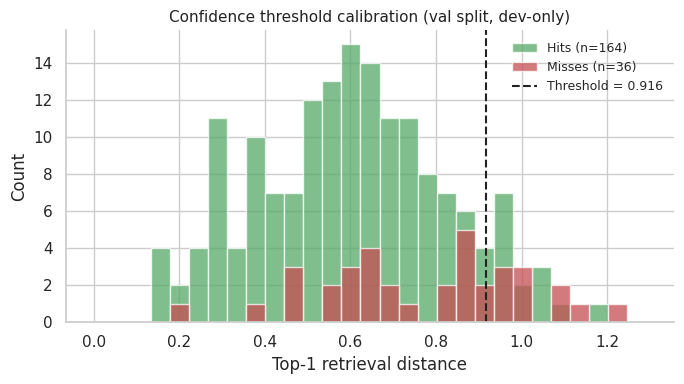

In [54]:
# One visual summary of the calibration numbers (no separate text dump).
_n_hits = int(calib_df["is_hit"].sum())
_n_misses = int((~calib_df["is_hit"]).sum())
_hit_mean = hit_distances.mean() if len(hit_distances) else float("nan")
_hit_med = hit_distances.median() if len(hit_distances) else float("nan")
_hit_p90 = hit_distances.quantile(0.9) if len(hit_distances) else float("nan")
_miss_mean = miss_distances.mean() if len(miss_distances) else float("nan")
_miss_med = miss_distances.median() if len(miss_distances) else float("nan")
_miss_p10 = miss_distances.quantile(0.1) if len(miss_distances) else float("nan")

display(Markdown(
    f"### Confidence threshold calibration (val split)\n\n"
    f"Sample **n = {len(calib_df)}** · hits **{_n_hits}** · misses **{_n_misses}**\n\n"
    f"| | mean | median | key percentile |\n|---|---:|---:|---:|\n"
    f"| Hit distances | {_hit_mean:.3f} | {_hit_med:.3f} | 90th = {_hit_p90:.3f} |\n"
    f"| Miss distances | {_miss_mean:.3f} | {_miss_med:.3f} | 10th = {_miss_p10:.3f} |\n\n"
    f"**CONFIDENCE_THRESHOLD = {CONFIDENCE_THRESHOLD:.3f}** "
    f"(90th percentile of hit distances) — `answer_question()` abstains above this."
))

fig, ax = plt.subplots(figsize=(7, 4))
_max_x = max(calib_df["distance"].max(), CONFIDENCE_THRESHOLD) * 1.05
bins = np.linspace(0, _max_x, 30)
ax.hist(hit_distances, bins=bins, alpha=0.75, label=f"Hits (n={len(hit_distances)})", color=PALETTE[2])
if len(miss_distances):
    ax.hist(miss_distances, bins=bins, alpha=0.75, label=f"Misses (n={len(miss_distances)})", color=DECLINE_RED)
ax.axvline(CONFIDENCE_THRESHOLD, color=INK_PRIMARY, linestyle="--", linewidth=1.5,
           label=f"Threshold = {CONFIDENCE_THRESHOLD:.3f}")
ax.set_xlabel("Top-1 retrieval distance")
ax.set_ylabel("Count")
ax.set_title("Confidence threshold calibration (val split, dev-only)", fontsize=11, color=INK_PRIMARY)
ax.legend(frameon=False, fontsize=9)
style_axis(ax)
plt.tight_layout()
plt.show()


Here, the idea in one line is that the agent searches the store for an answer, but if the best match is too far from the query it prefers “I don’t know” over a confident wrong reply.

For each of 200 queries we keep only the **top-1** chunk — the nearest neighbor in Chroma by **embedding distance** (small distance = strong match). That distance is the X-axis; bars are colored by whether top-1 was actually correct.

- **Green** = correct. Most greens sit on the left (close matches).
- **Red** = wrong. Reds tend to sit further right (weak matches).
- **Dashed line (0.916)** = confidence cutoff. Left → answer; right → abstain.

The line is placed so most greens still pass while many reds are blocked — better to say “I don’t know” than to answer wrong with confidence.


### The agent loop — retrieve → grep (optional) → explain → cite source

The code below is `answer_question()` — the full loop in one function: find relevant code, maybe narrow it, then explain it and cite the source. If the best match is too weak, it abstains.

**Who passes `keyword`?** Not the end user typing a question, and not the model guessing it from the prompt. `keyword` is an **optional argument on `answer_question(...)`**, set by whoever calls the function in code (this notebook’s examples, or a developer wiring the API). If the call omits `keyword=...`, grep never runs. This is a demo/API hook — not a product UI where a user would “know” that such a parameter exists.

**What keyword / grep does when it is passed:**
- The **query** is the question (“how does login work?”). That drives semantic search and brings back a short list of candidates.
- The **keyword** is an extra plain-text string to look for *inside that list* (e.g. `log`, `authenticate`) — grep, not another embedding search.
- **Without** `keyword`: explain search result #1.
- **With** `keyword`: prefer a candidate whose code/docstring contains that word; if none match, fall back to #1.


In [55]:
GREP_SEARCH_K = 20    # widen the candidate pool when a keyword is given, so grep_candidates()
                      # has a real chance to find something
MIN_REPO_CHUNKS_FOR_SCOPE = 5


def _repo_chunk_count(repo_name, split):
    return len(collection.get(where={"$and": [{"repository_name": repo_name}, {"split": split}]}, include=[])["ids"])


def answer_question(query, repo_name=None, keyword=None, k=5, split="val", confidence_threshold=None, quiet=False):
    '''Minimal agent: RAG-retrieve candidates for `query` (optionally scoped to `repo_name`
    and `split`), optionally grep them for `keyword` to pick the best-supported candidate,
    then either abstain honestly (chosen distance above `confidence_threshold`) or ask the
    base model to explain that candidate's code, returning one cited final answer.'''
    if repo_name is not None and not quiet:
        _count = _repo_chunk_count(repo_name, split)
        if _count < MIN_REPO_CHUNKS_FOR_SCOPE:
            print(f"Warning: '{repo_name}' has only {_count} chunk(s) in split={split!r} - below "
                  f"MIN_REPO_CHUNKS_FOR_SCOPE={MIN_REPO_CHUNKS_FOR_SCOPE}.")

    effective_k = max(k, GREP_SEARCH_K) if keyword else k
    candidates = retrieve(query, repo_name=repo_name, k=effective_k, split=split)
    if not candidates:
        return {"query": query, "repo_name": repo_name, "keyword": keyword, "candidates": [],
                "tool_hits": [], "chosen": None, "abstained": False,
                "final_answer": "No candidates retrieved - try a different query, repo_name, or split."}

    tool_hits = grep_candidates(keyword, candidates) if keyword else []
    chosen = candidates[tool_hits[0]["candidate_index"]] if tool_hits else candidates[0]

    threshold = CONFIDENCE_THRESHOLD if confidence_threshold is None else confidence_threshold
    if chosen["distance"] > threshold:
        citation = f"{chosen['repository_name']}" + (f" ({chosen['file_path']})" if chosen.get("file_path") else "")
        final_answer = (
            f"I don't have a good match for this in the codebase (closest candidate: {citation}, "
            f"distance={chosen['distance']:.3f}, above the {threshold:.3f} confidence threshold). "
            "Abstaining rather than guessing."
        )
        return {"query": query, "repo_name": repo_name, "keyword": keyword, "candidates": candidates,
                "tool_hits": tool_hits, "chosen": chosen, "abstained": True, "final_answer": final_answer}

    gen_input_code = chosen.get("code_no_doc") or chosen["code"]
    explanation, truncated = generate_response(tokenizer, gen_model, build_chat_messages(gen_input_code))

    citation = f"{chosen['repository_name']}" + (f" ({chosen['file_path']})" if chosen.get("file_path") else "")
    final_answer = (
        f"{explanation.strip()}\n\n(source: {citation}, split={chosen.get('split')}, "
        f"chunk_id={chosen['chunk_id']}, retrieval distance={chosen['distance']:.3f}"
        f"{', truncated' if truncated else ''})"
    )
    return {"query": query, "repo_name": repo_name, "keyword": keyword, "candidates": candidates,
            "tool_hits": tool_hits, "chosen": chosen, "abstained": False,
            "generated_explanation": explanation, "final_answer": final_answer}


def print_answer(result, answer_chars=900):
    print(f"Q: {result['query']}" + (f"  [repo={result.get('repo_name')}]" if result.get("repo_name") else ""))
    if result.get("keyword"):
        print(f"   tool: grep('{result['keyword']}') -> {len(result['tool_hits'])} candidate(s) matched")
    if result.get("abstained"):
        print("   [ABSTAINED - confidence threshold not met]")
    answer = str(result['final_answer'])
    if len(answer) > answer_chars:
        answer = answer[:answer_chars] + "\n... [truncated]"
    print(f"A: {answer}")
    print("-" * 80)


### Four worked examples, against real repositories in this run's own store

Repository names come from the val split's metadata, so demos point at repositories that exist in this store rather than invented examples.


In [56]:
from collections import Counter

sample_meta = collection.get(where={"split": "val"}, limit=2000, include=["metadatas"])["metadatas"]
sample_repos = sorted({m["repository_name"] for m in sample_meta})
print(f"{len(sample_repos)} distinct repositories in the val split. First 15:")
for r in sample_repos[:15]:
    print(" -", r)

_repo_counts = Counter(m["repository_name"] for m in sample_meta)
LARGEST_VAL_REPO = _repo_counts.most_common(1)[0][0] if _repo_counts else None
print(f"\nLargest-by-chunk-count repository in val (used for the repo-scoped examples below): {LARGEST_VAL_REPO}")


11 distinct repositories in the val split. First 15:
 - aleju/imgaug
 - apache/incubator-heron
 - bethgelab/foolbox
 - encode/starlette
 - google/grumpy
 - numenta/nupic
 - openai/baselines
 - quantopian/pyfolio
 - tensorforce/tensorforce
 - tensorlayer/tensorlayer
 - yinkaisheng/Python-UIAutomation-for-Windows

Largest-by-chunk-count repository in val (used for the repo-scoped examples below): numenta/nupic


The printout above is just inventory for the demos that follow: how many distinct repositories appear in this run’s **val** store (here: 11), and a sample of their names so the examples use real projects from the corpus — not invented ones. “First 15” is a display cap; with only 11 repos in the sample, the list is simply complete.

**`numenta/nupic`** is picked as `LARGEST_VAL_REPO` because it has the most chunks in that val sample. The repo-scoped examples below pass `repo_name=LARGEST_VAL_REPO` so retrieval stays inside a real, well-populated project instead of searching the whole split.


In [57]:
# Example 1: a genuine, non-fabricated success case - picks a real val docstring (verbatim)
# as the query, the same self-retrieval task the calibration above already validates at a
# high success rate. Deterministic search over real data, not a hand-picked query.
_val_pool_docs = collection.get(where={"split": "val"}, limit=2000, include=["documents"])["documents"]
_ex1_rng = np.random.default_rng(7)
_ex1_order = _ex1_rng.permutation(len(_val_pool_docs))
_ex1_query = None
for _pos in _ex1_order[:20]:
    _doc_part, _, _ = _val_pool_docs[_pos].partition("\n\n")
    if len(_doc_part.split()) >= 4:
        _ex1_query = _doc_part
        break
if _ex1_query is None:
    _ex1_query = _val_pool_docs[0].partition("\n\n")[0]

result_1 = answer_question(_ex1_query, k=5)
print_answer(result_1)


Q: Call IUIAutomationDockPattern::SetDockPosition.
        dockPosition: int, a value in class `DockPosition`.
        waitTime: float.
        Refer https://docs.microsoft.com/en-us/windows/desktop/api/uiautomationclient/nf-uiautomationclient-iuiautomationdockpattern-setdockposition
A: ```python
SetDockPosition(self, dockPosition: int, waitTime: float = OPERATION_WAIT_TIME) -> int:
    """
    Sets the position of the dock and waits for the operation to complete.

    Parameters:
    dockPosition (int): The desired position of the dock.
    waitTime (float): The time to wait after setting the dock position in seconds. Defaults to OPERATION_WAIT_TIME.

    Returns:
    int: The result of the operation.
    """
```

(source: yinkaisheng/Python-UIAutomation-for-Windows (uiautomation/uiautomation.py), split=val, chunk_id=315175, retrieval distance=0.184)
--------------------------------------------------------------------------------


Example 1 is the happy path for this bot: the query is a real docstring from the store, retrieval lands close (well under the confidence threshold), and the model returns an explanation with a citation. That is the intended use case from the notebook — grounded answers when the corpus actually contains the match, not free-form guessing.

In [58]:
# Example 2: a natural-language, repo-scoped question (no keyword tool). May or may not
# clear the confidence gate - Section 5 already documented the natural-language paraphrase
# gap, so an abstention here is an honest outcome, not a bug.
result_2 = answer_question("How does this repository validate its input?", repo_name=LARGEST_VAL_REPO, k=5)
print_answer(result_2)


Q: How does this repository validate its input?  [repo=numenta/nupic]
   [ABSTAINED - confidence threshold not met]
A: I don't have a good match for this in the codebase (closest candidate: numenta/nupic (src/nupic/regions/spec.py), distance=1.341, above the 0.916 confidence threshold). Abstaining rather than guessing.
--------------------------------------------------------------------------------


Example 2 asks a natural-language question scoped to one repo (the largest repo in this run's val split, `numenta/nupic`). The agent abstains: the closest chunk is still past the confidence threshold. That matches what Section 5 already showed — paraphrased questions are harder than verbatim docstrings — and it matches the bot’s goal: do not invent an answer when the store has no close hit. Abstention here is the honest outcome, not a failure of the loop.

In [59]:
# Example 3: same repo, plus the grep tool narrowing to a keyword among the retrieved
# candidates.
result_3 = answer_question("Where is logging configured?", repo_name=LARGEST_VAL_REPO, keyword="log", k=5)
print_answer(result_3)


Q: Where is logging configured?  [repo=numenta/nupic]
   tool: grep('log') -> 20 candidate(s) matched
   [ABSTAINED - confidence threshold not met]
A: I don't have a good match for this in the codebase (closest candidate: numenta/nupic (src/nupic/frameworks/opf/model_factory.py), distance=1.085, above the 0.916 confidence threshold). Abstaining rather than guessing.
--------------------------------------------------------------------------------


Example 3 adds the grep tool on the same repo. It did find keyword matches among the retrieved candidates — so the tool worked — but the best hit was still too far from the query (distance above the threshold). So the agent abstains again. Grep can *choose* among candidates; it cannot invent a strong semantic match. For a codebase Q&A bot, that split of jobs is useful: retrieval finds neighbors, grep refines, the gate still decides whether to speak.

In [60]:
# Example 4: deliberately out-of-domain - no CodeSearchNet Python function can answer this.
# retrieve() still returns its closest candidates (no query rewriting, no "I don't know"
# path inside retrieve() itself - that's answer_question()'s job), so this exercises the
# honest-abstention branch on a query that should clearly fail the confidence gate.
result_4 = answer_question("Explain the mathematical proof of the Riemann hypothesis", k=5)
print_answer(result_4)


Q: Explain the mathematical proof of the Riemann hypothesis
   [ABSTAINED - confidence threshold not met]
A: I don't have a good match for this in the codebase (closest candidate: cokelaer/spectrum (src/spectrum/window.py), distance=1.284, above the 0.916 confidence threshold). Abstaining rather than guessing.
--------------------------------------------------------------------------------


Example 4 is the stress test: a question with no answer in CodeSearchNet. Retrieval still returns *something* (the nearest chunk), but the distance stays well above the threshold, so the agent abstains. That is exactly what the confidence gate was built for — better a clear “I don’t know” than a polished wrong explanation of unrelated code.

In [61]:
summary_rows = []
for label, result in [("Example 1", result_1), ("Example 2", result_2), ("Example 3", result_3), ("Example 4", result_4)]:
    chosen = result.get("chosen")
    query_text = result["query"]
    summary_rows.append({
        "example": label,
        "query": query_text[:40] + ("…" if len(query_text) > 40 else ""),
        "repo_filter": result.get("repo_name") or "—",
        "keyword_tool": result.get("keyword") or "—",
        "grep_hits": len(result.get("tool_hits", [])),
        "chosen_repo": chosen["repository_name"] if chosen else "—",
        "retrieval_distance": round(chosen["distance"], 3) if chosen else None,
    })
summary_df = pd.DataFrame(summary_rows)
display(summary_df)


,example,query,repo_filter,keyword_tool,grep_hits,chosen_repo,retrieval_distance
0,Example 1,Call IUIAutomationDockPattern::SetDockPo…,—,—,0,yinkaisheng/Python-UIAutomation-for-Windows,0.184
1,Example 2,How does this repository validate its in…,numenta/nupic,—,0,numenta/nupic,1.341
2,Example 3,Where is logging configured?,numenta/nupic,log,20,numenta/nupic,1.085
3,Example 4,Explain the mathematical proof of the Ri…,—,—,0,cokelaer/spectrum,1.284


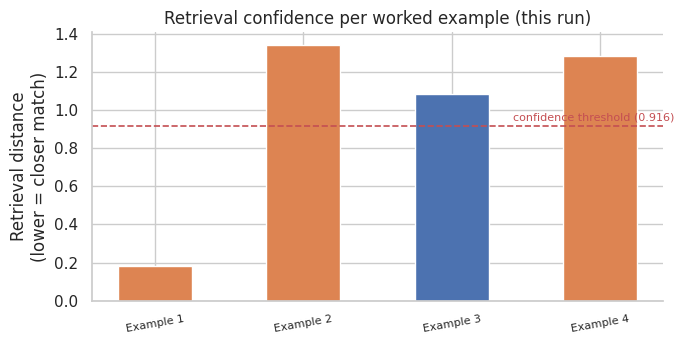

In [62]:
fig, ax = plt.subplots(figsize=(7, 3.6))
colors = [PALETTE[0] if row["grep_hits"] > 0 else PALETTE[1] for _, row in summary_df.iterrows()]
ax.bar(summary_df["example"], summary_df["retrieval_distance"], color=colors, width=0.5)
ax.axhline(CONFIDENCE_THRESHOLD, color=DECLINE_RED, linestyle="--", linewidth=1.2)
ax.text(3.5, CONFIDENCE_THRESHOLD + 0.03, f"confidence threshold ({CONFIDENCE_THRESHOLD:.3f})",
        color=DECLINE_RED, fontsize=8, ha="right")
ax.set_ylabel("Retrieval distance\n(lower = closer match)")
ax.set_title("Retrieval confidence per worked example (this run)")
plt.xticks(fontsize=8, rotation=10)
style_axis(ax)
plt.tight_layout()
plt.show()


Each bar is one worked example; the height is retrieval distance (lower = a closer match). Blue means grep found a keyword hit among the candidates; orange means grep was not used, or found nothing. The dashed red line is the confidence threshold from calibration — if a bar sits above it, the agent should say “I don’t know.”

So: Example 1 is under the line (answer), Examples 2–4 are above it (abstain). That is the point of the gate — a wrong confident answer is worse than an honest skip.


### Dev batch evaluation — a success-rate number, on val only

For a sample of val chunks, treat each chunk's own docstring as a query (same self-retrieval ground truth as elsewhere), run the full agent (abstention included), and cross two signals: did retrieval find the right code (`is_hit`), and did the agent answer or abstain?

`bucket_batch()` turns those two yes/no signals into four plain buckets:

| Bucket | Meaning |
|---|---|
| hit & answered | Found the right code and answered — the success case |
| hit & abstained | Found the right code but still said “I don’t know” — too cautious |
| miss & answered | Found the *wrong* code and answered anyway — the dangerous case |
| miss & abstained | Missed the right code and abstained — safer than guessing |

The headline rate is the share of **hit & answered**. The bucket to watch by hand is **miss & answered**.


In [63]:
def batch_evaluate(n=60, seed=321, split="val"):
    '''Dev-only batch evaluation: sample `n` chunks from `split`, use each one's own
    docstring as the query, run the full answer_question() agent on it, and record whether
    retrieval actually found the source chunk (is_hit) crossed with whether the agent
    answered or abstained.'''
    pool = collection.get(where={"split": split}, limit=5000, include=["metadatas", "documents"])
    metas, docs = pool["metadatas"], pool["documents"]
    n_pool = len(docs)
    if n_pool == 0:
        raise ValueError(f"No chunks found for split={split!r} in the collection.")

    rng = np.random.default_rng(seed)
    positions = rng.choice(n_pool, size=min(n, n_pool), replace=False)

    rows = []
    for pos in positions:
        doc_part, _, _ = docs[pos].partition("\n\n")
        expected_chunk_id = metas[pos]["chunk_id"]
        result = answer_question(doc_part, split=split, quiet=True)
        chosen = result.get("chosen")
        is_hit = bool(chosen) and chosen.get("chunk_id") == expected_chunk_id
        rows.append({
            "expected_chunk_id": expected_chunk_id, "is_hit": is_hit,
            "abstained": bool(result.get("abstained")),
            "distance": chosen["distance"] if chosen else None,
            "true_doc": doc_part, "generated_explanation": result.get("generated_explanation"),
            "code_for_judge": (chosen.get("code_no_doc") or chosen.get("code")) if chosen else None,
        })
    return pd.DataFrame(rows)


def bucket_batch(batch_df_in):
    def _bucket(row):
        if row["is_hit"] and not row["abstained"]:
            return "hit & answered"
        if row["is_hit"] and row["abstained"]:
            return "hit & abstained"
        if not row["is_hit"] and not row["abstained"]:
            return "miss & answered"
        return "miss & abstained"
    out = batch_df_in.copy()
    out["bucket"] = out.apply(_bucket, axis=1)
    counts = out["bucket"].value_counts().reindex(
        ["hit & answered", "hit & abstained", "miss & answered", "miss & abstained"], fill_value=0,
    )
    return out, counts


batch_df = batch_evaluate(n=60, seed=321, split="val")
batch_df, bucket_counts = bucket_batch(batch_df)
AGENT_SUCCESS_RATE = bucket_counts["hit & answered"] / len(batch_df)

print(f"Batch evaluation on val (n={len(batch_df)}):")
for bucket_name, count in bucket_counts.items():
    print(f"  {bucket_name:<16s} {count:3d}  ({count / len(batch_df):.1%})")
print(f"\nAGENT_SUCCESS_RATE (hit & answered) = {AGENT_SUCCESS_RATE:.1%}")
if bucket_counts["miss & answered"] > 0:
    print(f"Worth flagging: {bucket_counts['miss & answered']} case(s) of 'miss & answered' - confidently wrong.")


Batch evaluation on val (n=60):
  hit & answered    47  (78.3%)
  hit & abstained    4  (6.7%)
  miss & answered    6  (10.0%)
  miss & abstained   3  (5.0%)

AGENT_SUCCESS_RATE (hit & answered) = 78.3%
Worth flagging: 6 case(s) of 'miss & answered' - confidently wrong.


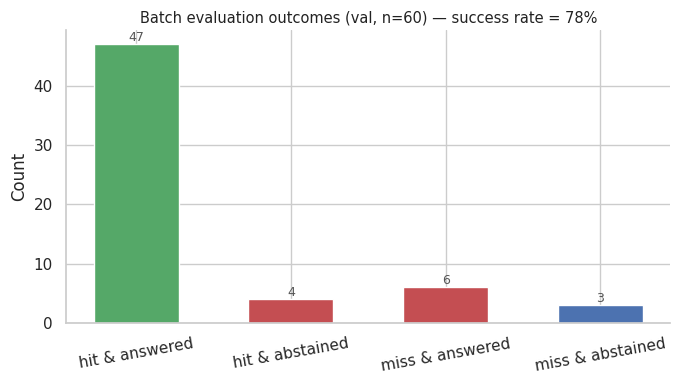

In [64]:
fig, ax = plt.subplots(figsize=(7, 4))
bucket_order = ["hit & answered", "hit & abstained", "miss & answered", "miss & abstained"]
bucket_colors = [IMPROVE_GREEN, PALETTE[3], DECLINE_RED, PALETTE[0]]
ax.bar(bucket_order, [bucket_counts[b] for b in bucket_order], color=bucket_colors, width=0.55)
for i, b in enumerate(bucket_order):
    ax.text(i, bucket_counts[b] + 0.5, f"{bucket_counts[b]}", ha="center", fontsize=9, color=INK_SECONDARY)
ax.set_ylabel("Count")
ax.set_title(f"Batch evaluation outcomes (val, n={len(batch_df)}) — success rate = {AGENT_SUCCESS_RATE:.0%}", fontsize=10.5, color=INK_PRIMARY)
style_axis(ax)
plt.xticks(rotation=10)
plt.tight_layout()
plt.show()


Four buckets from two questions: did retrieval find the right code, and did the agent choose to answer? "Hit & answered" (green) is the success case — most of the bar should land here if the store and confidence gate both work. "Miss & answered" (red) is the failure mode most worth reading by hand: the agent explained the *wrong* code, which is worse than abstaining. Section 14 reruns this check on `test` for direct comparison.


## 13. (Recap) The final model, measured on VAL — from the original project

Everything below is the original project's historical `val` scorecard, kept as context — not recomputed here. Section 14 computes the live equivalent on `test` so the two can be compared side by side.

**Which model is "final."** Sections 10–11 tested 16 trained configurations, two independent LLM judges, and bootstrap confidence checks throughout. The conclusion: **no trained variant beats the base model** on judged-quality metrics. Two ways to answer "what's the final model":

- **What the project ships:** the **base `Qwen2.5-Coder-3B-Instruct`** — no adapter loaded. That is the evidence-based answer.
- **The strongest LoRA candidate anyway**, shown side-by-side: **`LoRA r=8, 3x data (detail-filtered)`** — composite-leaderboard leader, and the one Section 11 retrained live.

Every number below was measured on **`val`**, historically — in the original project, `test` stayed untouched for one final check once the design was locked in.


,ROUGE-L,Semantic similarity,GPT judge (1-5),Gemini judge (1-5)
Base — SHIPPED,0.222,0.594,3.143,3.857
Best LoRA candidate (not shipped),0.300,0.634,2.757,3.643


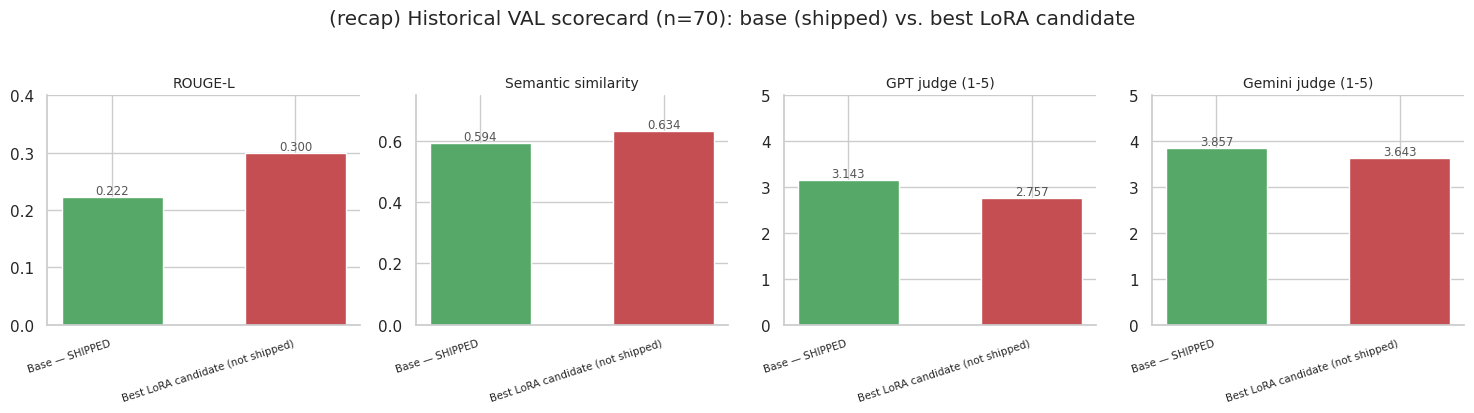

Base wins on both judge metrics (the decisive signal for this project); the LoRA candidate wins on ROUGE-L/semantic similarity but that gain doesn't translate into judged quality - the same paradox documented throughout Section 10.


In [65]:
final_scorecard_val = all_metrics.loc[["Base (no LoRA)", "LoRA r=8, 3x data (detail-filtered)"]].copy()
final_scorecard_val.index = ["Base — SHIPPED", "Best LoRA candidate (not shipped)"]
final_scorecard_val_display = final_scorecard_val.rename(columns={
    "rougeL": "ROUGE-L", "embed_cos_sim": "Semantic similarity",
    "judge_score": "GPT judge (1-5)", "gemini_judge_score": "Gemini judge (1-5)",
})
display(final_scorecard_val_display.round(3))

fig, axes = plt.subplots(1, 4, figsize=(15, 4))
panels = [("rougeL", "ROUGE-L", (0, 0.4)), ("embed_cos_sim", "Semantic similarity", (0, 0.75)),
          ("judge_score", "GPT judge (1-5)", (0, 5)), ("gemini_judge_score", "Gemini judge (1-5)", (0, 5))]
for ax, (col, title, ylim) in zip(axes, panels):
    vals = final_scorecard_val[col].to_numpy()
    colors = [PALETTE[2], DECLINE_RED]
    bars = ax.bar(final_scorecard_val.index, vals, color=colors, width=0.55)
    for b, v in zip(bars, vals):
        ax.text(b.get_x() + b.get_width()/2, v, f"{v:.3f}", ha="center", va="bottom", fontsize=8.5, color=INK_SECONDARY)
    ax.set_title(title, fontsize=10)
    ax.set_ylim(*ylim)
    plt.setp(ax.get_xticklabels(), rotation=18, ha="right", fontsize=7.5)
    style_axis(ax)
plt.suptitle("(recap) Historical VAL scorecard (n=70): base (shipped) vs. best LoRA candidate", y=1.03)
plt.tight_layout()
plt.show()
print("Base wins on both judge metrics (the decisive signal for this project); the LoRA "
      "candidate wins on ROUGE-L/semantic similarity but that gain doesn't translate into "
      "judged quality - the same paradox documented throughout Section 10.")


Four historical panels, base (green) vs. the best LoRA candidate (red), on the original project's `val` sample. Green leading a panel means base won that metric; here base wins both judge panels while LoRA wins the two objective panels (ROUGE-L, semantic similarity) — the metric disagreement from Section 10. Section 14 draws the same four panels, same colors, computed fresh on `test` — compare them side by side to see whether today's run agrees.


## 14. The final model, measured on TEST — live, this notebook's own run

Nothing above has opened `test_df`'s content. This is the project's final held-out check: generate with the **base** model and with the **live-retrained LoRA candidate** (Section 11) on a sample of `test`, score both the same way as the historical `val` comparison (Section 13), and see whether the conclusion holds on data neither model design nor earlier notebook choices were tuned against.

Judges this run: ROUGE-L and embedding cosine similarity are always computed. GPT and Gemini judges run only if their API key is set — checked once, right here.


In [66]:
_openai_key = get_openai_key()
_gemini_key = get_gemini_key()

USE_GPT_JUDGE = bool(_openai_key)
USE_GEMINI_JUDGE = bool(_gemini_key)

print("Active judges for this TEST evaluation:")
print(f"  ROUGE-L               : always on")
print(f"  Semantic similarity   : always on")
print(f"  GPT judge (gpt-4o-mini): {'ON' if USE_GPT_JUDGE else 'OFF (no OPENAI_API_KEY - column will be skipped)'}")
print(f"  Gemini judge          : {'ON' if USE_GEMINI_JUDGE else 'OFF (no GEMINI_API_KEY - column will be skipped)'}")


Active judges for this TEST evaluation:
  ROUGE-L               : always on
  Semantic similarity   : always on
  GPT judge (gpt-4o-mini): ON
  Gemini judge          : ON


### Generating on a real TEST sample, base vs. the live LoRA candidate

Written answers from both models on the same `test` functions are needed before anything can be scored. This cell asks each model for a docstring on the same sample; the cells below then measure which answers are better.


In [67]:
TEST_EVAL_SIZE = 40
TEST_EVAL_SEED = 2024   # disjoint from every seed used above
MAX_NEW_TOKENS = 260

test_eval_sample = test_df.sample(n=min(TEST_EVAL_SIZE, len(test_df)), random_state=TEST_EVAL_SEED).reset_index(drop=True)
print(f"TEST evaluation sample: {len(test_eval_sample)} rows from test_df (seed={TEST_EVAL_SEED})")


def run_generation_pass(run_label, model, tok, sample_df_in):
    rows = []
    for i, row in sample_df_in.iterrows():
        gen_text, truncated = generate_response(tok, model, build_chat_messages(row["func_code_no_doc"]), max_new_tokens=MAX_NEW_TOKENS)
        rows.append({
            "sample_idx": i, "run": run_label, "repository": row[repo_col],
            "true_doc": row[doc_col], "generated_doc": gen_text, "truncated": truncated,
        })
    return pd.DataFrame(rows)


generation_results = []

print("Generating with the BASE model (reusing the Agent's already-loaded generator)...")
generation_results.append(run_generation_pass("Base (no LoRA)", gen_model, tokenizer, test_eval_sample))
print("  Done with base model.")

LORA_LABEL = BEST_LORA_VARIANT["label"]
print(f"Loading base model + {LORA_LABEL} adapter for generation...")
_lora_base_model = AutoModelForCausalLM.from_pretrained(
    LORA_TARGET_MODEL_ID, dtype=torch.bfloat16 if device == "cuda" else torch.float32, device_map=device,
)
lora_gen_model = PeftModel.from_pretrained(_lora_base_model, ADAPTER_PATH)
lora_gen_model.eval()
generation_results.append(run_generation_pass(LORA_LABEL, lora_gen_model, tokenizer, test_eval_sample))
print(f"  Done with {LORA_LABEL}.")

del _lora_base_model, lora_gen_model
gc.collect()
if device == "cuda":
    torch.cuda.empty_cache()

test_generation_df = pd.concat(generation_results, ignore_index=True)
print(f"\nTotal generations: {len(test_generation_df)} ({len(test_eval_sample)} rows x {len(generation_results)} runs)")


TEST evaluation sample: 40 rows from test_df (seed=2024)
Generating with the BASE model (reusing the Agent's already-loaded generator)...
  Done with base model.
Loading base model + LoRA r=8, 3x data (detail-filtered) adapter for generation...
  Done with LoRA r=8, 3x data (detail-filtered).

Total generations: 80 (40 rows x 2 runs)


### Objective metrics — ROUGE-L and embedding similarity

Same definitions as Section 10's historical comparison: ROUGE-L rewards literal word overlap with the true docstring; embedding cosine similarity (same MiniLM model used for RAG) catches "right content, different words" cases ROUGE-L misses.


In [68]:
from rouge_score import rouge_scorer

_rouge_scorer = rouge_scorer.RougeScorer(["rougeL"], use_stemmer=True)


def rouge_l(true_text, gen_text):
    if not str(true_text).strip() or not str(gen_text).strip():
        return 0.0
    return _rouge_scorer.score(str(true_text), str(gen_text))["rougeL"].fmeasure


test_generation_df["rougeL"] = test_generation_df.apply(
    lambda r: rouge_l(r["true_doc"], r["generated_doc"]), axis=1,
)

_true = test_generation_df["true_doc"].astype(str).tolist()
_gen = test_generation_df["generated_doc"].astype(str).tolist()
_true_emb = embedding_model.encode(_true, normalize_embeddings=True, show_progress_bar=False)
_gen_emb = embedding_model.encode(_gen, normalize_embeddings=True, show_progress_bar=False)
_cos = np.empty(len(test_generation_df), dtype=float)
for i, (t, g) in enumerate(zip(_true, _gen)):
    if not t.strip() or not g.strip():
        _cos[i] = 0.0
    else:
        _cos[i] = float(np.dot(_true_emb[i], _gen_emb[i]))
test_generation_df["embed_cos_sim"] = _cos

display(test_generation_df.groupby("run")[["rougeL", "embed_cos_sim"]].mean().round(3))


,rougeL,embed_cos_sim
run,,
Base (no LoRA),0.211,0.633
"LoRA r=8, 3x data (detail-filtered)",0.300,0.640


### LLM-judge scoring (only where a key is available)

Same 1–5 meaning-and-accuracy prompt as the historical comparison: each generated docstring is scored against the true one by GPT and/or Gemini when their API key is present. A missing key skips that column (`NaN`) so the rest of the scorecard still runs. The objective metrics above do not depend on this step.


In [69]:
JUDGE_PROMPT = (
    "You are judging the quality of an AI-generated Python docstring against the "
    "ground-truth human-written docstring for the same function.\n\n"
    "Ground-truth docstring:\n{true_doc}\n\n"
    "AI-generated docstring:\n{gen_doc}\n\n"
    "Score the AI-generated docstring's match to the ground truth's meaning and "
    "accuracy on a 1-5 scale (5 = equivalent in meaning and accuracy, 1 = wrong or "
    "unrelated). Reply with ONLY the integer score, nothing else."
)

if not USE_GPT_JUDGE:
    print("No OPENAI_API_KEY - skipping the GPT judge column.")
    test_generation_df["judge_score"] = np.nan
else:
    from openai import OpenAI
    _openai_client = OpenAI(api_key=_openai_key)

    def judge_score(true_doc, gen_doc):
        try:
            resp = _openai_client.chat.completions.create(
                model="gpt-4o-mini",
                messages=[{"role": "user", "content": JUDGE_PROMPT.format(true_doc=true_doc, gen_doc=gen_doc)}],
                max_tokens=5, temperature=0,
            )
            return float(re.search(r"\d+", resp.choices[0].message.content).group())
        except Exception as e:
            print(f"  GPT judge call failed: {e}")
            return np.nan

    print(f"Judging {len(test_generation_df)} rows with GPT ({len(test_generation_df)} API calls)...")
    scores = []
    for i, row in test_generation_df.iterrows():
        scores.append(judge_score(row["true_doc"], row["generated_doc"]))
        if (i + 1) % 20 == 0:
            print(f"  ...{i + 1}/{len(test_generation_df)} judged")
    test_generation_df["judge_score"] = scores

if not USE_GEMINI_JUDGE:
    print("No GEMINI_API_KEY - skipping the Gemini judge column.")
    test_generation_df["gemini_judge_score"] = np.nan
else:
    from google import genai as _genai
    _gemini_client = _genai.Client(api_key=_gemini_key)

    def gemini_judge_score(true_doc, gen_doc):
        try:
            resp = _gemini_client.models.generate_content(
                model="gemini-3.6-flash",
                contents=JUDGE_PROMPT.format(true_doc=true_doc, gen_doc=gen_doc),
            )
            return float(re.search(r"\d+", resp.text).group())
        except Exception as e:
            print(f"  Gemini judge call failed: {e}")
            return np.nan

    print(f"Judging {len(test_generation_df)} rows with Gemini ({len(test_generation_df)} API calls)...")
    _gemini_scores = []
    for i, row in test_generation_df.iterrows():
        _gemini_scores.append(gemini_judge_score(row["true_doc"], row["generated_doc"]))
        if (i + 1) % 20 == 0:
            print(f"  ...{i + 1}/{len(test_generation_df)} judged")
    test_generation_df["gemini_judge_score"] = _gemini_scores


Judging 80 rows with GPT (80 API calls)...
  ...20/80 judged
  ...40/80 judged
  ...60/80 judged
  ...80/80 judged
Judging 80 rows with Gemini (80 API calls)...
  ...20/80 judged
  ...40/80 judged
  ...60/80 judged
  ...80/80 judged


### Consolidated TEST results table

Average each metric over the TEST sample, one row per model. This is the live counterpart to Section 13's historical `val` table — ROUGE-L and semantic similarity always, judge columns only when their key was set. Place it next to Section 13 to see whether today's held-out numbers agree with the original finding.


In [70]:
_readable_cols = {"rougeL": "ROUGE-L", "embed_cos_sim": "Semantic similarity",
                   "judge_score": "GPT judge (1-5)", "gemini_judge_score": "Gemini judge (1-5)"}

test_metrics_table = test_generation_df.groupby("run")[list(_readable_cols.keys())].mean()
test_metrics_table = test_metrics_table.reindex(["Base (no LoRA)", LORA_LABEL])

test_metrics_display = test_metrics_table.rename(columns=_readable_cols).copy()
if not USE_GPT_JUDGE:
    test_metrics_display = test_metrics_display.drop(columns=["GPT judge (1-5)"])
if not USE_GEMINI_JUDGE:
    test_metrics_display = test_metrics_display.drop(columns=["Gemini judge (1-5)"])
test_metrics_display.index.name = "Model"
test_metrics_display = test_metrics_display.round(3)

try:
    display(
        test_metrics_display.style
        .format("{:.3f}")
        .set_caption(f"LIVE TEST scorecard (n={len(test_eval_sample)}) — base vs. live-retrained LoRA candidate")
    )
except Exception:
    display(test_metrics_display)


,ROUGE-L,Semantic similarity,GPT judge (1-5),Gemini judge (1-5)
Model,,,,
Base (no LoRA),0.211,0.633,3.175,4.100
"LoRA r=8, 3x data (detail-filtered)",0.300,0.640,3.050,3.850


This is the live **TEST** scorecard (n=40): each row is a model, each column is a metric averaged over the same held-out functions. Neither model was trained on these rows.

**What each metric means:**
- **ROUGE-L** — word-overlap with the true docstring (higher = more similar wording).
- **Semantic similarity** — MiniLM embedding cosine (higher = closer meaning even if the words differ).
- **GPT / Gemini judge (1–5)** — an LLM rates how well the generated docstring matches the true one in meaning and accuracy.

**What this run shows:**
| | Base | LoRA |
|---|---:|---:|
| ROUGE-L | 0.211 | **0.300** |
| Semantic similarity | 0.633 | **0.640** |
| GPT judge | **3.175** | 3.050 |
| Gemini judge | **4.100** | 3.850 |

LoRA wins the two automatic overlap/similarity scores, but **both judges prefer the base model**. That is the same paradox Section 10 found on historical val runs: looking more like the reference text is not the same as writing a better docstring. On held-out test data, this live adapter still does **not** beat base on judged quality — which is why the Agent keeps the base model.


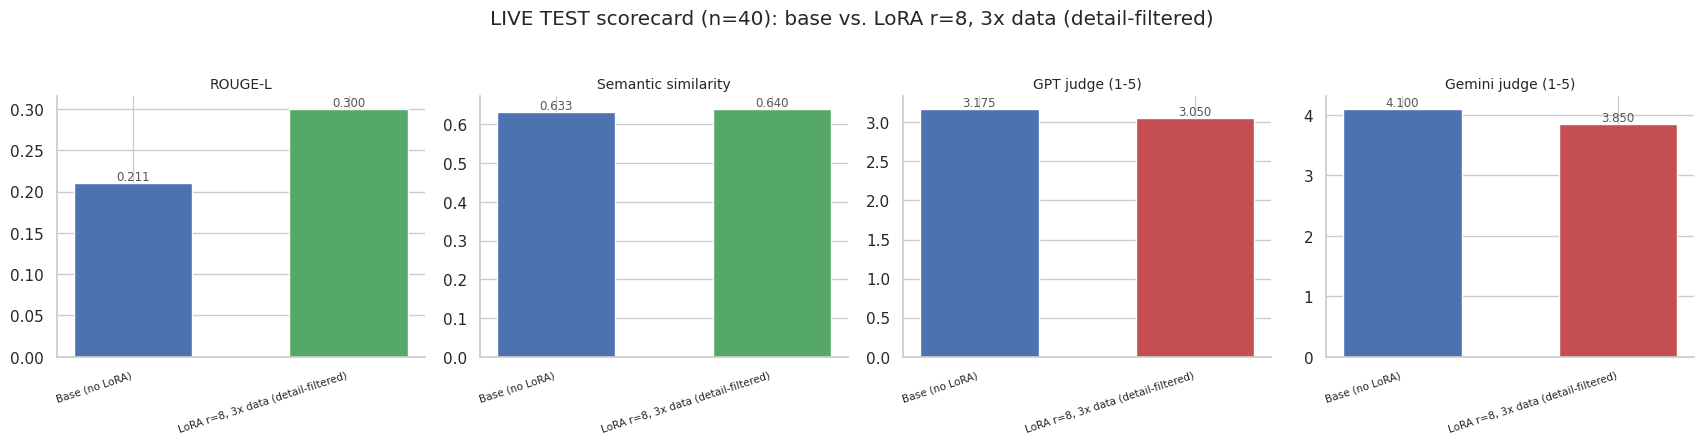

In [71]:
_test_panels = [("rougeL", "ROUGE-L"), ("embed_cos_sim", "Semantic similarity")]
if USE_GPT_JUDGE:
    _test_panels.append(("judge_score", "GPT judge (1-5)"))
if USE_GEMINI_JUDGE:
    _test_panels.append(("gemini_judge_score", "Gemini judge (1-5)"))

run_labels = ["Base (no LoRA)", LORA_LABEL]
fig, axes = plt.subplots(1, len(_test_panels), figsize=(4.3 * len(_test_panels), 4.3))
if len(_test_panels) == 1:
    axes = [axes]
for ax, (col, title) in zip(axes, _test_panels):
    base_val, lora_val = test_metrics_table.loc["Base (no LoRA)", col], test_metrics_table.loc[LORA_LABEL, col]
    colors = [PALETTE[0], IMPROVE_GREEN if lora_val >= base_val else DECLINE_RED]
    bars = ax.bar(run_labels, [base_val, lora_val], color=colors, width=0.55)
    for b, v in zip(bars, [base_val, lora_val]):
        ax.text(b.get_x() + b.get_width()/2, v, f"{v:.3f}", ha="center", va="bottom", fontsize=8.5, color=INK_SECONDARY)
    ax.set_title(title, fontsize=10)
    plt.setp(ax.get_xticklabels(), rotation=18, ha="right", fontsize=7.5)
    style_axis(ax)
plt.suptitle(f"LIVE TEST scorecard (n={len(test_eval_sample)}): base vs. {LORA_LABEL}", y=1.03)
plt.tight_layout()
plt.show()


These four charts show the same TEST comparison as the table above (n=40), just easier to scan. In each panel the blue bar is the base model. The LoRA bar is green when it matches or beats base on that metric, and red when it falls behind.

On this run LoRA clearly wins ROUGE-L (0.300 vs 0.211) and edges out semantic similarity (0.640 vs 0.633). The judge panels go the other way: GPT prefers base (3.175 vs 3.050), and so does Gemini (4.100 vs 3.850).

In short, the automatic metrics say LoRA looks closer to the reference text, while both judges say the base model still writes the better docstring. That is the same split Section 10 saw historically — now confirmed on held-out `test` data — and it is why the Agent keeps the base model.


### Retrieval self-check on TEST

Same `evaluate_retrieval_hitk()` as Section 12, scoped to `split="test"` — the first time this notebook measures retrieval quality on test.


In [72]:
test_hitk_results, test_hitk_n = evaluate_retrieval_hitk(n_queries=150, seed=42, split="test")
print(f"Doc->code retrieval quality on TEST (n={test_hitk_n}):")
for metric, value in test_hitk_results.items():
    print(f"  {metric}: {value:.3f}")


Doc->code retrieval quality on TEST (n=150):
  Hit@1: 0.820
  Hit@5: 0.947
  Hit@10: 0.953
  MRR: 0.873


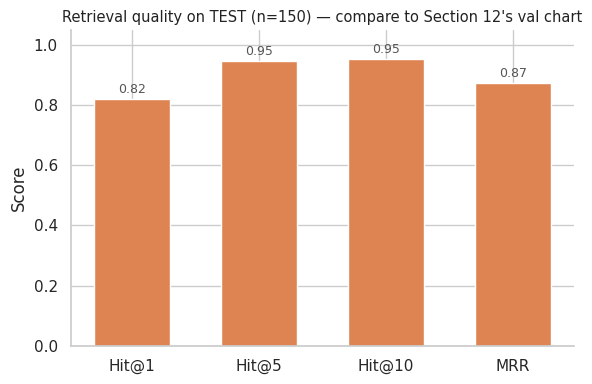

In [73]:
fig, ax = plt.subplots(figsize=(6, 4))
metric_names = list(test_hitk_results.keys())
metric_values = [test_hitk_results[m] for m in metric_names]
bars = ax.bar(metric_names, metric_values, color=PALETTE[1], width=0.6)
for bar, val in zip(bars, metric_values):
    ax.text(bar.get_x() + bar.get_width() / 2, val + 0.02, f"{val:.2f}", ha="center", fontsize=9, color=INK_SECONDARY)
ax.set_ylim(0, 1.05)
ax.set_ylabel("Score")
ax.set_title(f"Retrieval quality on TEST (n={test_hitk_n}) — compare to Section 12's val chart", fontsize=10.5, color=INK_PRIMARY)
style_axis(ax)
plt.tight_layout()
plt.show()


This chart is the same doc→code self-retrieval check as Section 12, but on the **test** split for the first time (n=150). Each bar is one metric: how often the right chunk comes back at rank 1, within the top 5, within the top 10, and MRR (how early the correct chunk tends to appear).

On this run the numbers are high and almost identical to val: Hit@1 is 0.82, Hit@5 is 0.95, Hit@10 is 0.95, and MRR is 0.87. In other words, for most docstring queries the store still finds the matching code near the top — even on data the Agent’s confidence threshold never saw during calibration.

That matters for the pipeline as a whole. Section 12 set the abstain line on val; seeing the same retrieval strength on test suggests that threshold is not overfit to val alone, so the Agent’s “answer vs. I don’t know” behavior should transfer reasonably to this held-out partition too.


### End-to-end agent quality on TEST

Same `batch_evaluate()` as Section 12, scoped to `split="test"`.


In [74]:
test_batch_df = batch_evaluate(n=60, seed=321, split="test")
test_batch_df, test_bucket_counts = bucket_batch(test_batch_df)
TEST_AGENT_SUCCESS_RATE = test_bucket_counts["hit & answered"] / len(test_batch_df)

print(f"Batch evaluation on TEST (n={len(test_batch_df)}):")
for bucket_name, count in test_bucket_counts.items():
    print(f"  {bucket_name:<16s} {count:3d}  ({count / len(test_batch_df):.1%})")
print(f"\nTEST_AGENT_SUCCESS_RATE (hit & answered) = {TEST_AGENT_SUCCESS_RATE:.1%}")


Batch evaluation on TEST (n=60):
  hit & answered    50  (83.3%)
  hit & abstained    2  (3.3%)
  miss & answered    5  (8.3%)
  miss & abstained   3  (5.0%)

TEST_AGENT_SUCCESS_RATE (hit & answered) = 83.3%


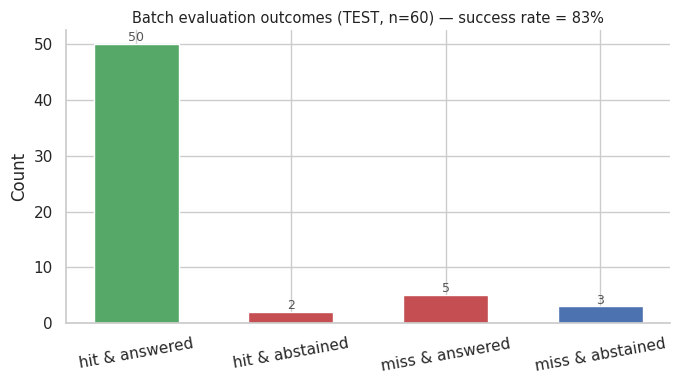

In [75]:
fig, ax = plt.subplots(figsize=(7, 4))
bucket_order = ["hit & answered", "hit & abstained", "miss & answered", "miss & abstained"]
bucket_colors = [IMPROVE_GREEN, PALETTE[3], DECLINE_RED, PALETTE[0]]
ax.bar(bucket_order, [test_bucket_counts[b] for b in bucket_order], color=bucket_colors, width=0.55)
for i, b in enumerate(bucket_order):
    ax.text(i, test_bucket_counts[b] + 0.5, f"{test_bucket_counts[b]}", ha="center", fontsize=9, color=INK_SECONDARY)
ax.set_ylabel("Count")
ax.set_title(f"Batch evaluation outcomes (TEST, n={len(test_batch_df)}) — success rate = {TEST_AGENT_SUCCESS_RATE:.0%}", fontsize=10.5, color=INK_PRIMARY)
style_axis(ax)
plt.xticks(rotation=10)
plt.tight_layout()
plt.show()


This chart is the end-to-end Agent check on **test** (n=60): each bar is one outcome after retrieve → confidence gate → answer (or abstain). Green is the success case — retrieval hit **and** the agent answered. The other three bars catch the failure modes: hit but abstained, miss but still answered, and miss with abstain.

On this run the picture is strong. **Hit & answered** is 50/60 (**83%**), a bit above the same check on val (78%). Only 2 cases hit and then abstained, 5 were misses that still got an answer (the risky bucket), and 3 were misses that correctly abstained. So most of the time the Agent both finds the right chunk and is willing to speak; the dangerous “wrong but confident” slice stays small.

Compared with Section 12’s val chart, the shape is similar and the success rate is not worse — if anything slightly better.

### Final verdict — TEST, this run

| Component | TEST measurement (this run) | Compare to |
|---|---|---|
| Generation (base vs. LoRA) | see the consolidated table and chart above | Section 13's historical `val` scorecard |
| Retrieval | see the Hit@k/MRR chart above | Section 12's val-split retrieval chart |
| Agent, end-to-end | see the batch-evaluation chart above | Section 12's val batch evaluation |

The numbers above are whatever this run's generation, scoring, and retrieval produced on a split nothing above touched. If the LoRA candidate's bars are red on the judge metrics here too (as on every one of the 16 historical configurations in Section 10), that independently confirms the original finding: **the base model is the better copilot, on this task and this data budget.** If a judge column shows green instead, treat it as new evidence worth checking — but note first whether it is a same-direction result on a small sample (n=40, `TEST_EVAL_SIZE` above) or a real reversal.


## 15. Summary

This project built a small Python coding assistant: it searches a large code database, explains the function it finds, and cites the source. If the match looks too weak, it says it does not know instead of guessing.

Search worked well when questions sounded like the documentation in the database — about 82% of the time the right function was first, and about 95% within the top five, on both validation and test. End-to-end on test, the assistant found the right code and answered in 50 of 60 cases (83%), similar to validation.

Fine-tuning a small LoRA add-on did not clearly help. It often scored higher on wording overlap with the reference docstring, but two independent AI judges still preferred the original model. The live test run showed the same pattern, so the assistant uses the base model without the adapter.

Thus, the practical choice is to keep the search-and-explain loop, and keep the original model. One limit still matters for real use — when people ask in ordinary language instead of documentation wording, finding the right code gets much harder, and the assistant will say “I don’t know” more often than the high search scores above might suggest.


## 16. Known limitations and future work

- **Everyday questions vs. documentation wording (Section 5).** Most retrieval scores use the function’s own docstring as the query. Ordinary-language questions are much harder (small check, n=8 — clear direction, not a precise rate). That is the biggest gap between the benchmark numbers and real use.
- **A promising lead that was not fully resolved (Section 10).** The rewritten-target pilot looked mixed: Gemini’s drop was tiny, GPT’s was not, and the two judges disagreed on whether the rewrite itself helped. This notebook does not rebuild those targets.
- **Two AI judges help, but they are not perfect.** They usually agreed that fine-tuning hurt overall quality, but much less on *which* answers got worse — a manual audit of the 8 largest judge-score declines found the two vendors agreed on the direction of the gap only 38% of the time. They can also penalize a short, correct answer for different wording.
- **The agent is intentionally small.** One search, an optional keyword filter, one answer — not a multi-step planner — so more time could go to the RAG and LoRA work.
- **Live samples are modest on purpose.** Section 11 trains on 1,200 rows; Section 14 scores 40 test rows so the notebook fits one Colab GPU run. Read those results as a clear signal, not a full-scale study.
- **Docstring style differences between splits** were checked as a possible cause of the judge-score drop and did **not** explain it broadly.


## 17. Reference: the original notebooks

This notebook consolidates the earlier experiment notebooks kept under `/experiments`, including dead ends, bug fixes, and follow-ups:

- `1a_codesearchnet_exploration`
- `1b_codesearchnet_rag_readiness_gates`
- `2_codesearchnet_preprocessing_pipeline`
- `3_codesearchnet_lora_prep_and_model_selection`
- `4a_codesearchnet_lora_training_and_evaluation`
- `4b_codesearchnet_target_rewrite_validation`
- `5_codesearchnet_lora_more_data_followup`
- `6_codesearchnet_agent_demo`
